<a href="https://colab.research.google.com/github/OJB-Quantum/Spintronics-Generative-Layouts/blob/main/Monte_Caro_Simulation_of_Nano_MTJ_Dose_Heat_Map_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install the required layout and export libraries.
!python -m pip install -q uv
!uv pip install --system -q phidl gdstk ezdxf gdspy || python -m pip install -q phidl gdstk ezdxf gdspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 106.5 MB/s eta 0:00:00


In [5]:
!uv pip install cupy-cuda12x

Using Python 3.12.13 environment at: /usr
Checked 1 package in 89ms


Exported layout: /content/Fibonacci_MTJ_Crossbar_FibonacciSites_1x1_n12.oas
Fibonacci order n: 12
Fibonacci word length: 377
Detected Fibonacci bends: 232
Selected unique Fibonacci sites: 232
Bottom-crossbar rows per unit: 28
Top-crossbar columns per unit: 40
Geometric row-column crossings per unit: 1120
MTJ pillars per unit: 232
Unpopulated geometric crossings per unit: 888
Bottom-electrode pads per unit: 56
Top-electrode pads per unit: 80
Total Ti/Au leads per unit: 136
Total pads per unit: 136
Total pads in XY array: 136
Total MTJ pillars in XY array: 232
Main crossbar width: 3.500 um
Pillar diameter: 100.000 nm
Contact-pad size: 60.000 um x 60.000 um
Crossbar intersection-to-elbow offset: 25.000 to 25.000 um
Ti/Au-to-crossbar overlap length / nominal area: 5.000 um / 17.500 um^2
Pad taper length / Ti/Au terminal width: 50.000 um / 40.000 um
Bottom Ti/Au width profile: 3.5, 6.0, 9.0, 15.0, 24.0, 35.5, 40.0 um
Top Ti/Au width profile: 3.5, 5.0, 8.0, 13.0, 21.0, 30.5, 40.0 um
Automati

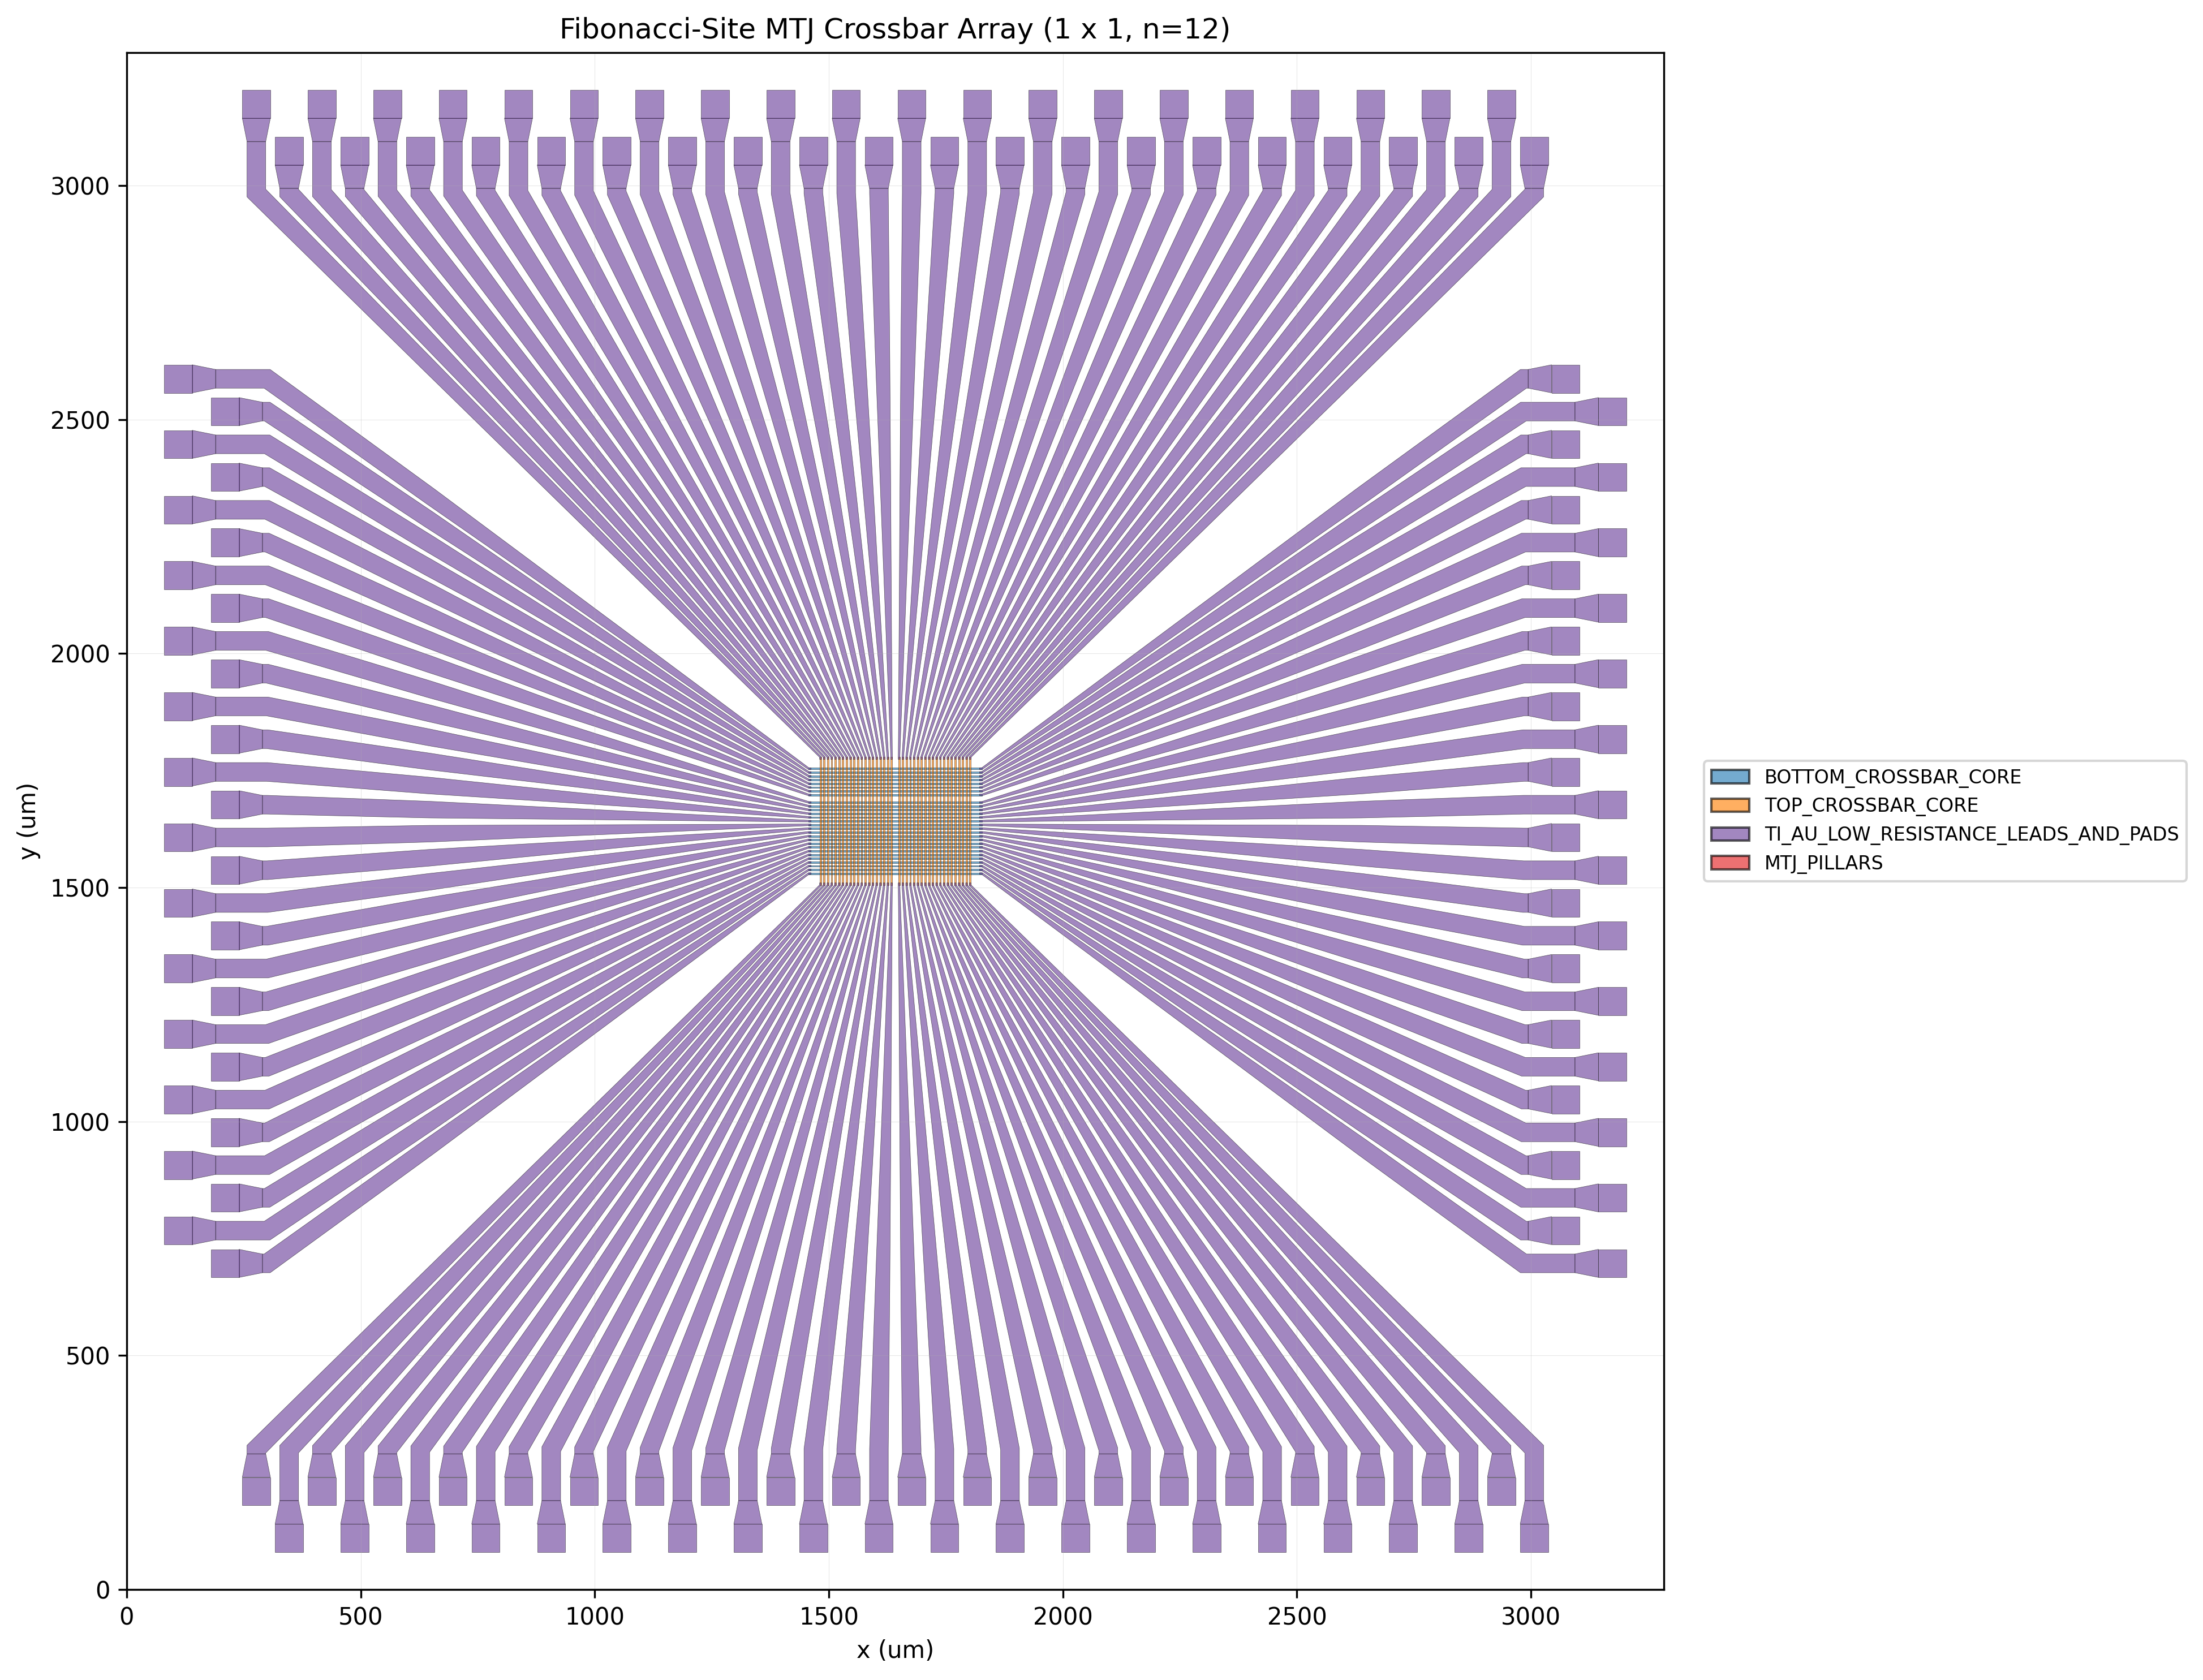

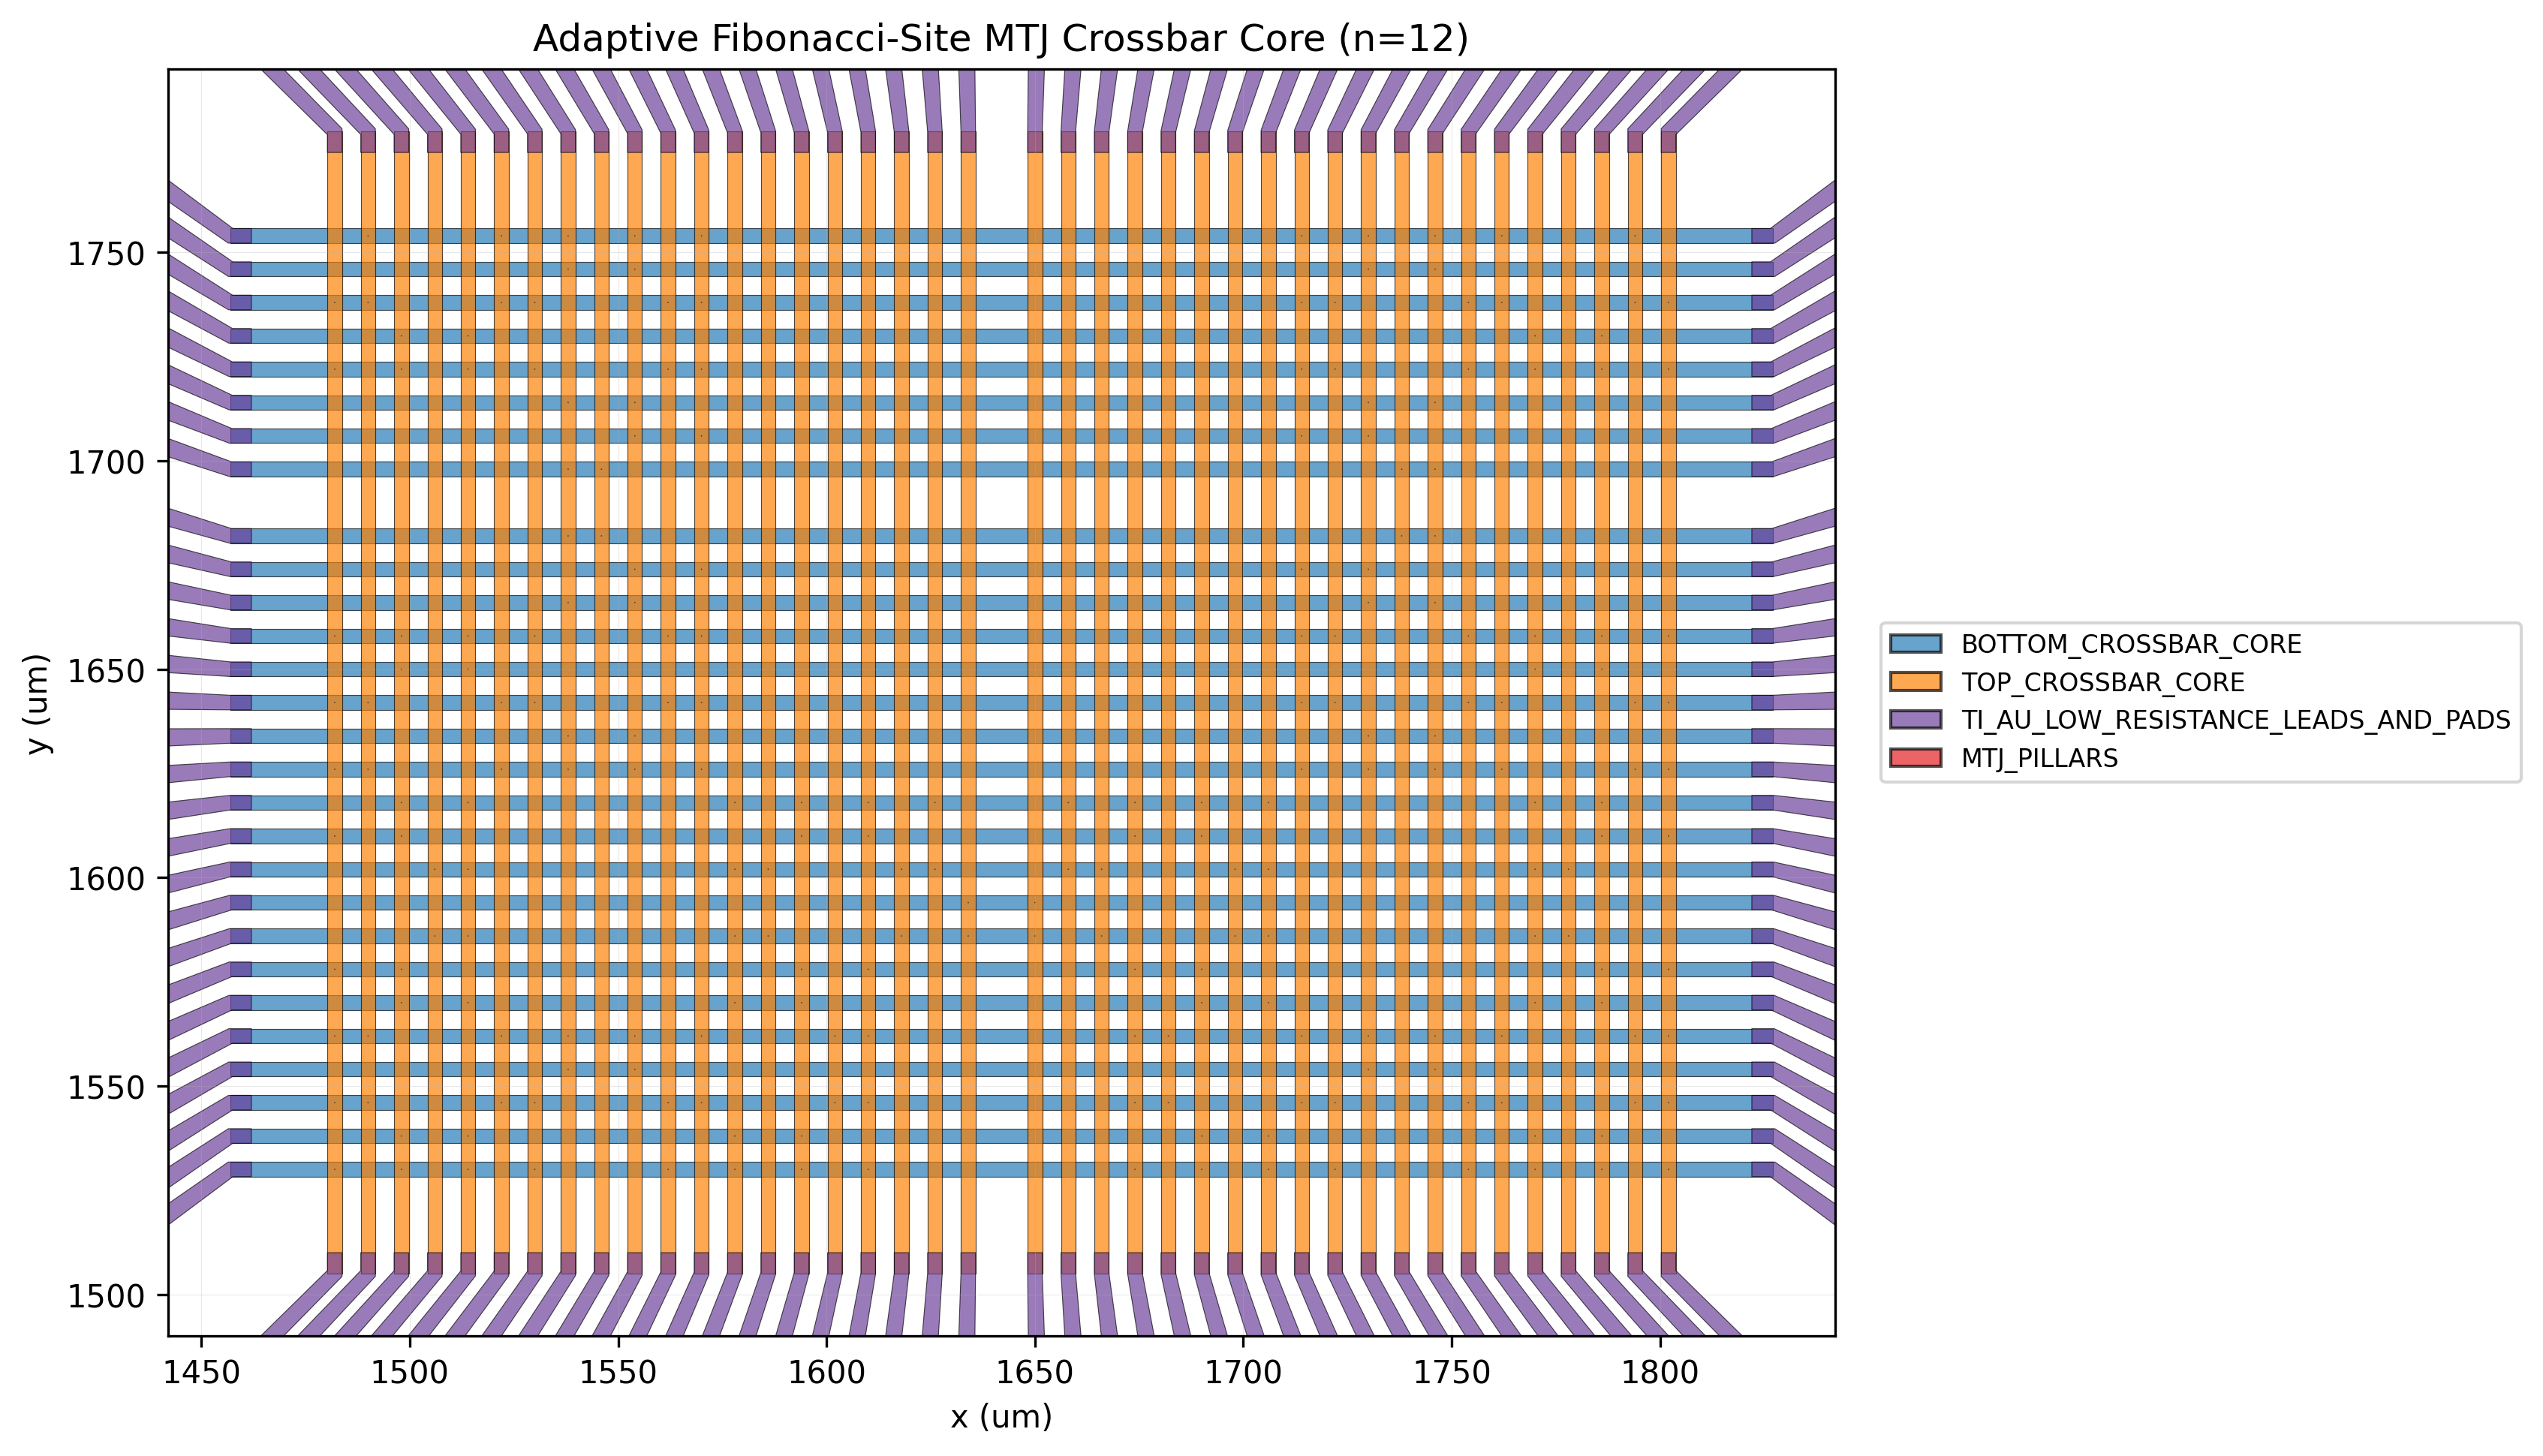

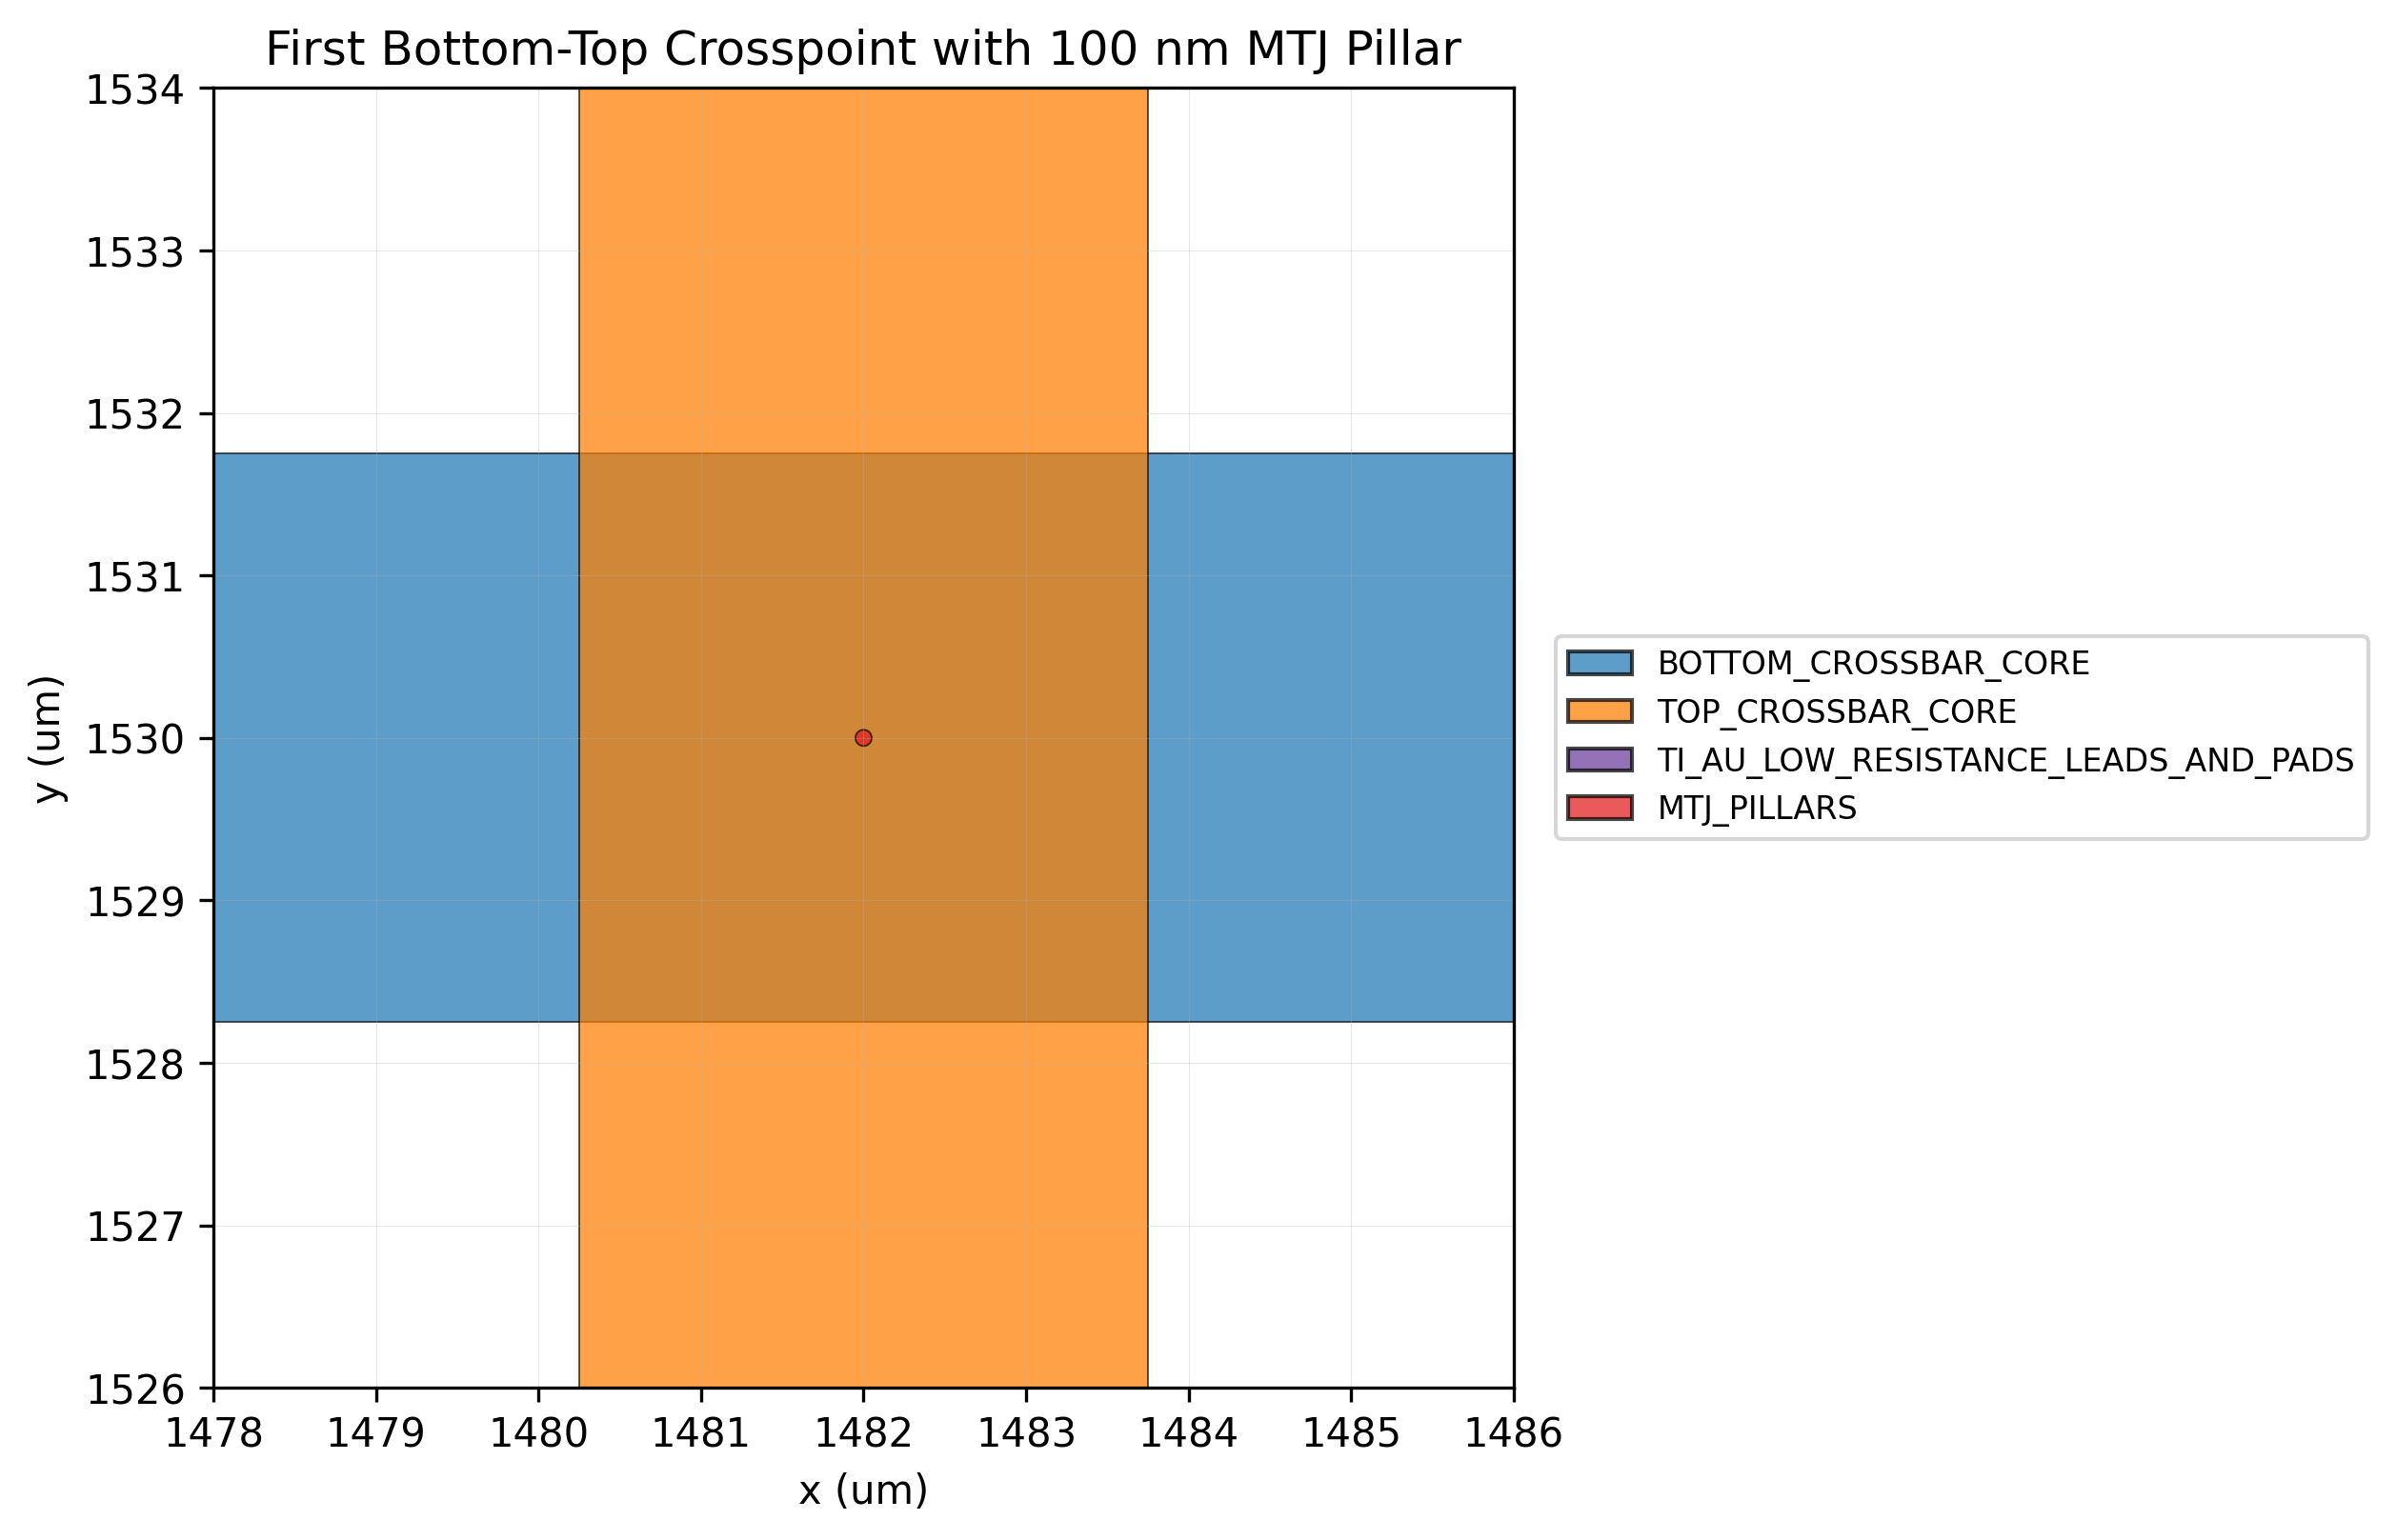

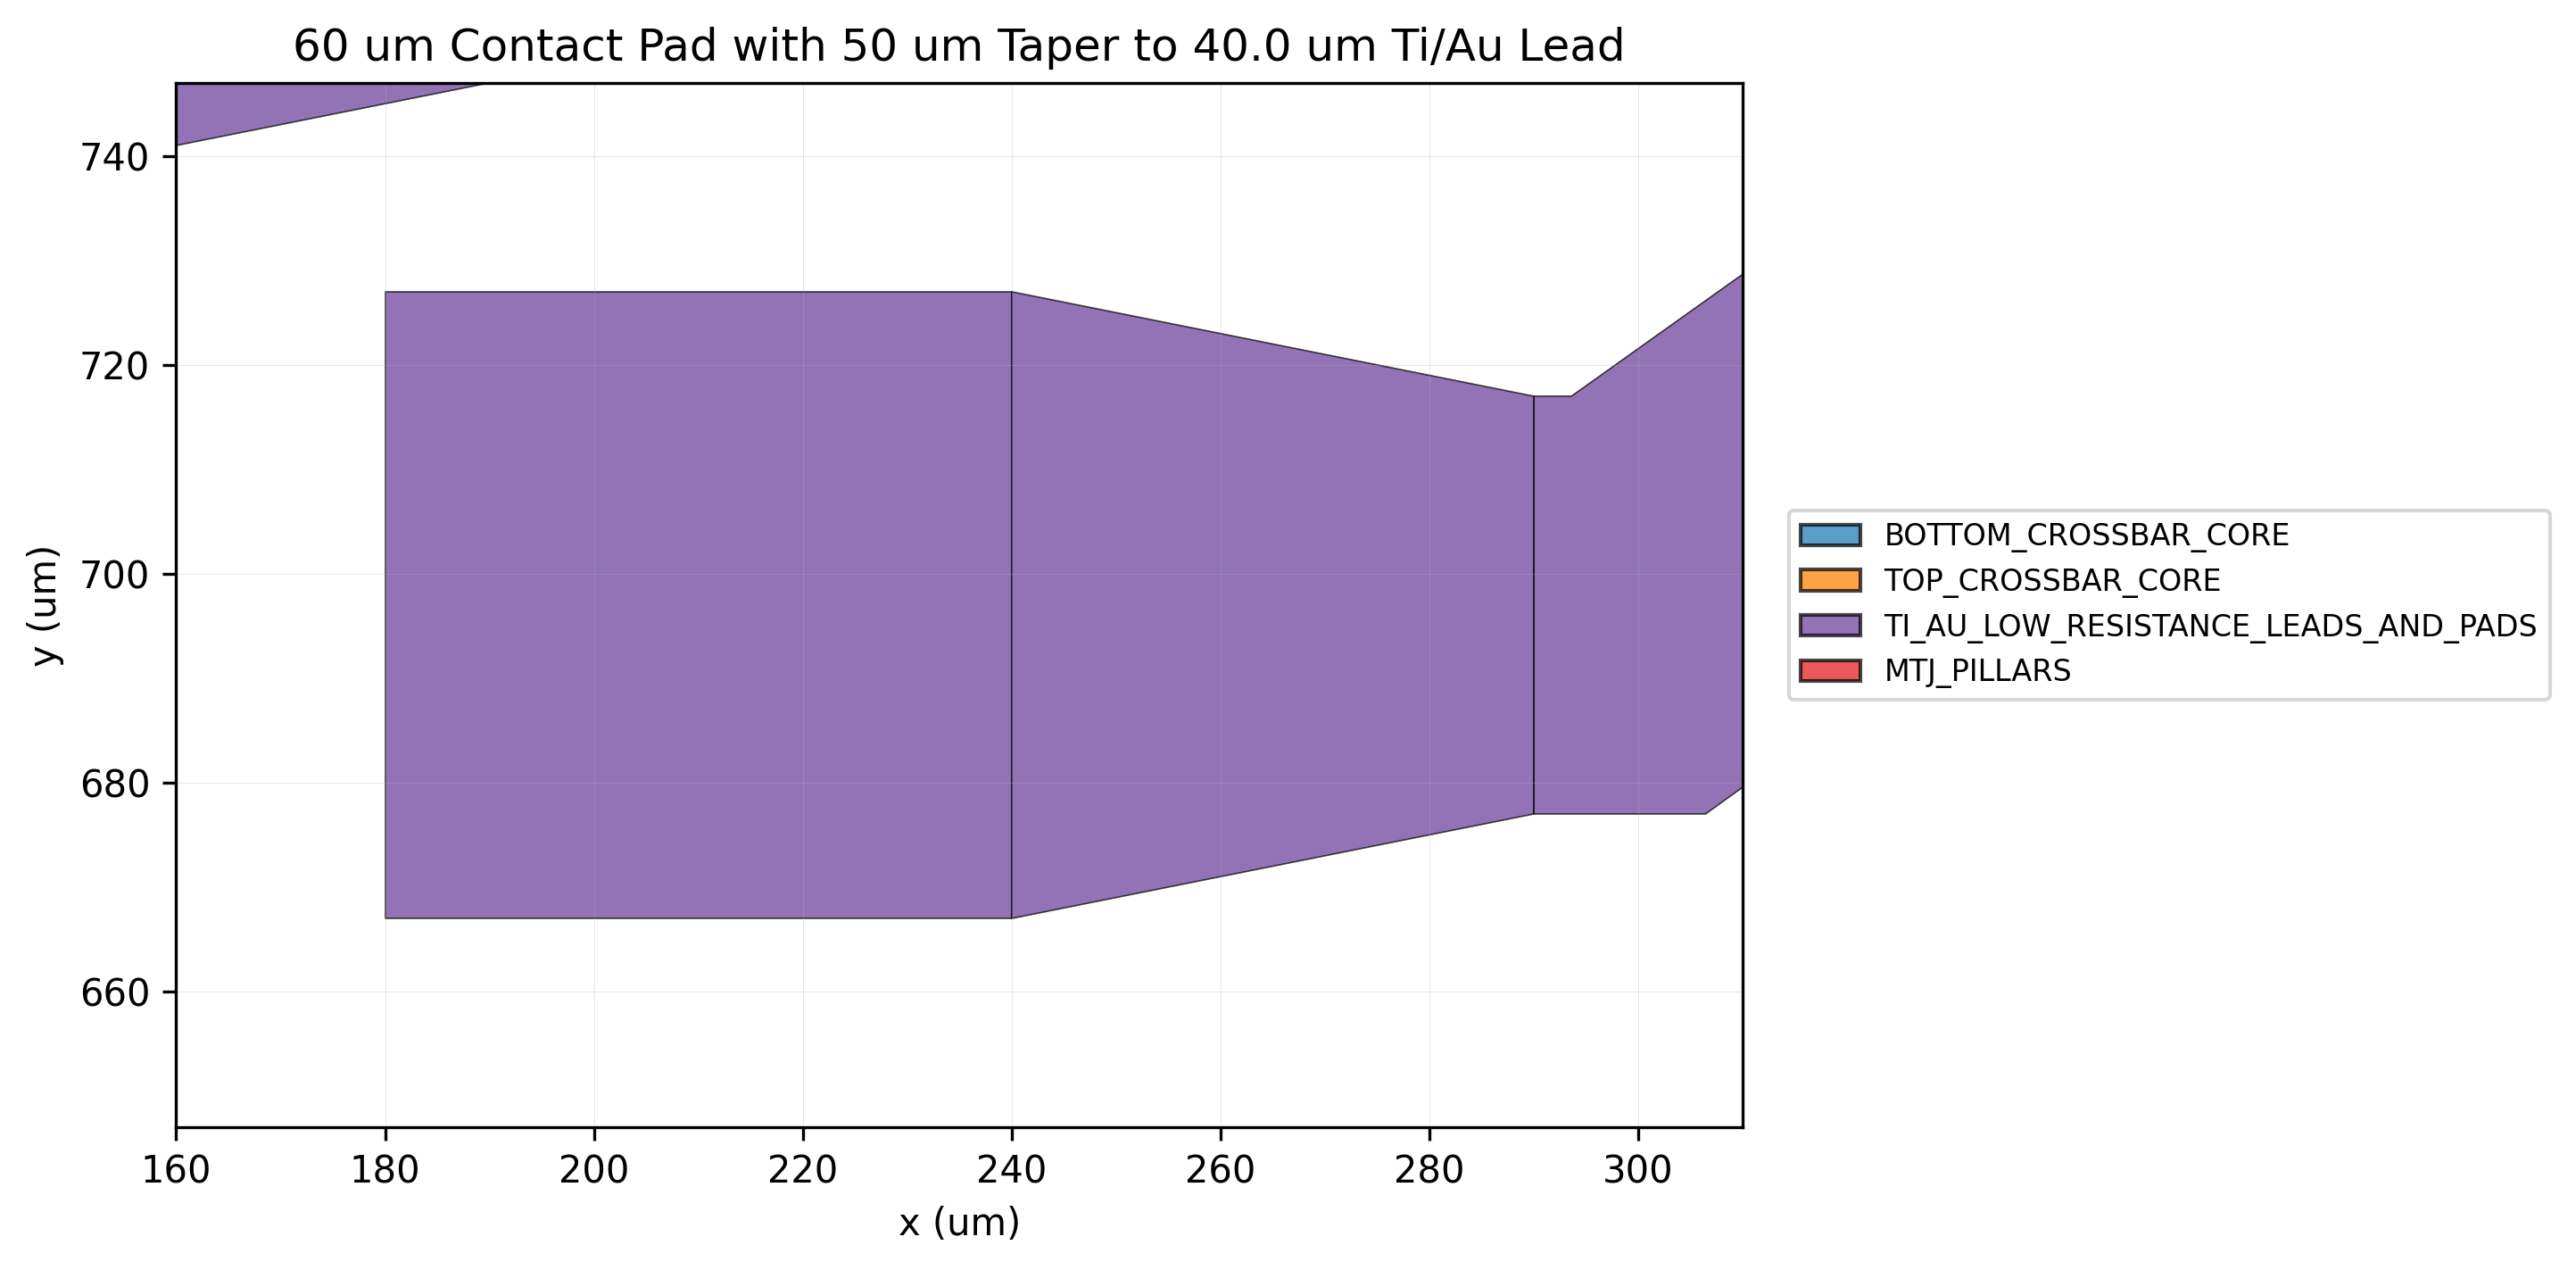

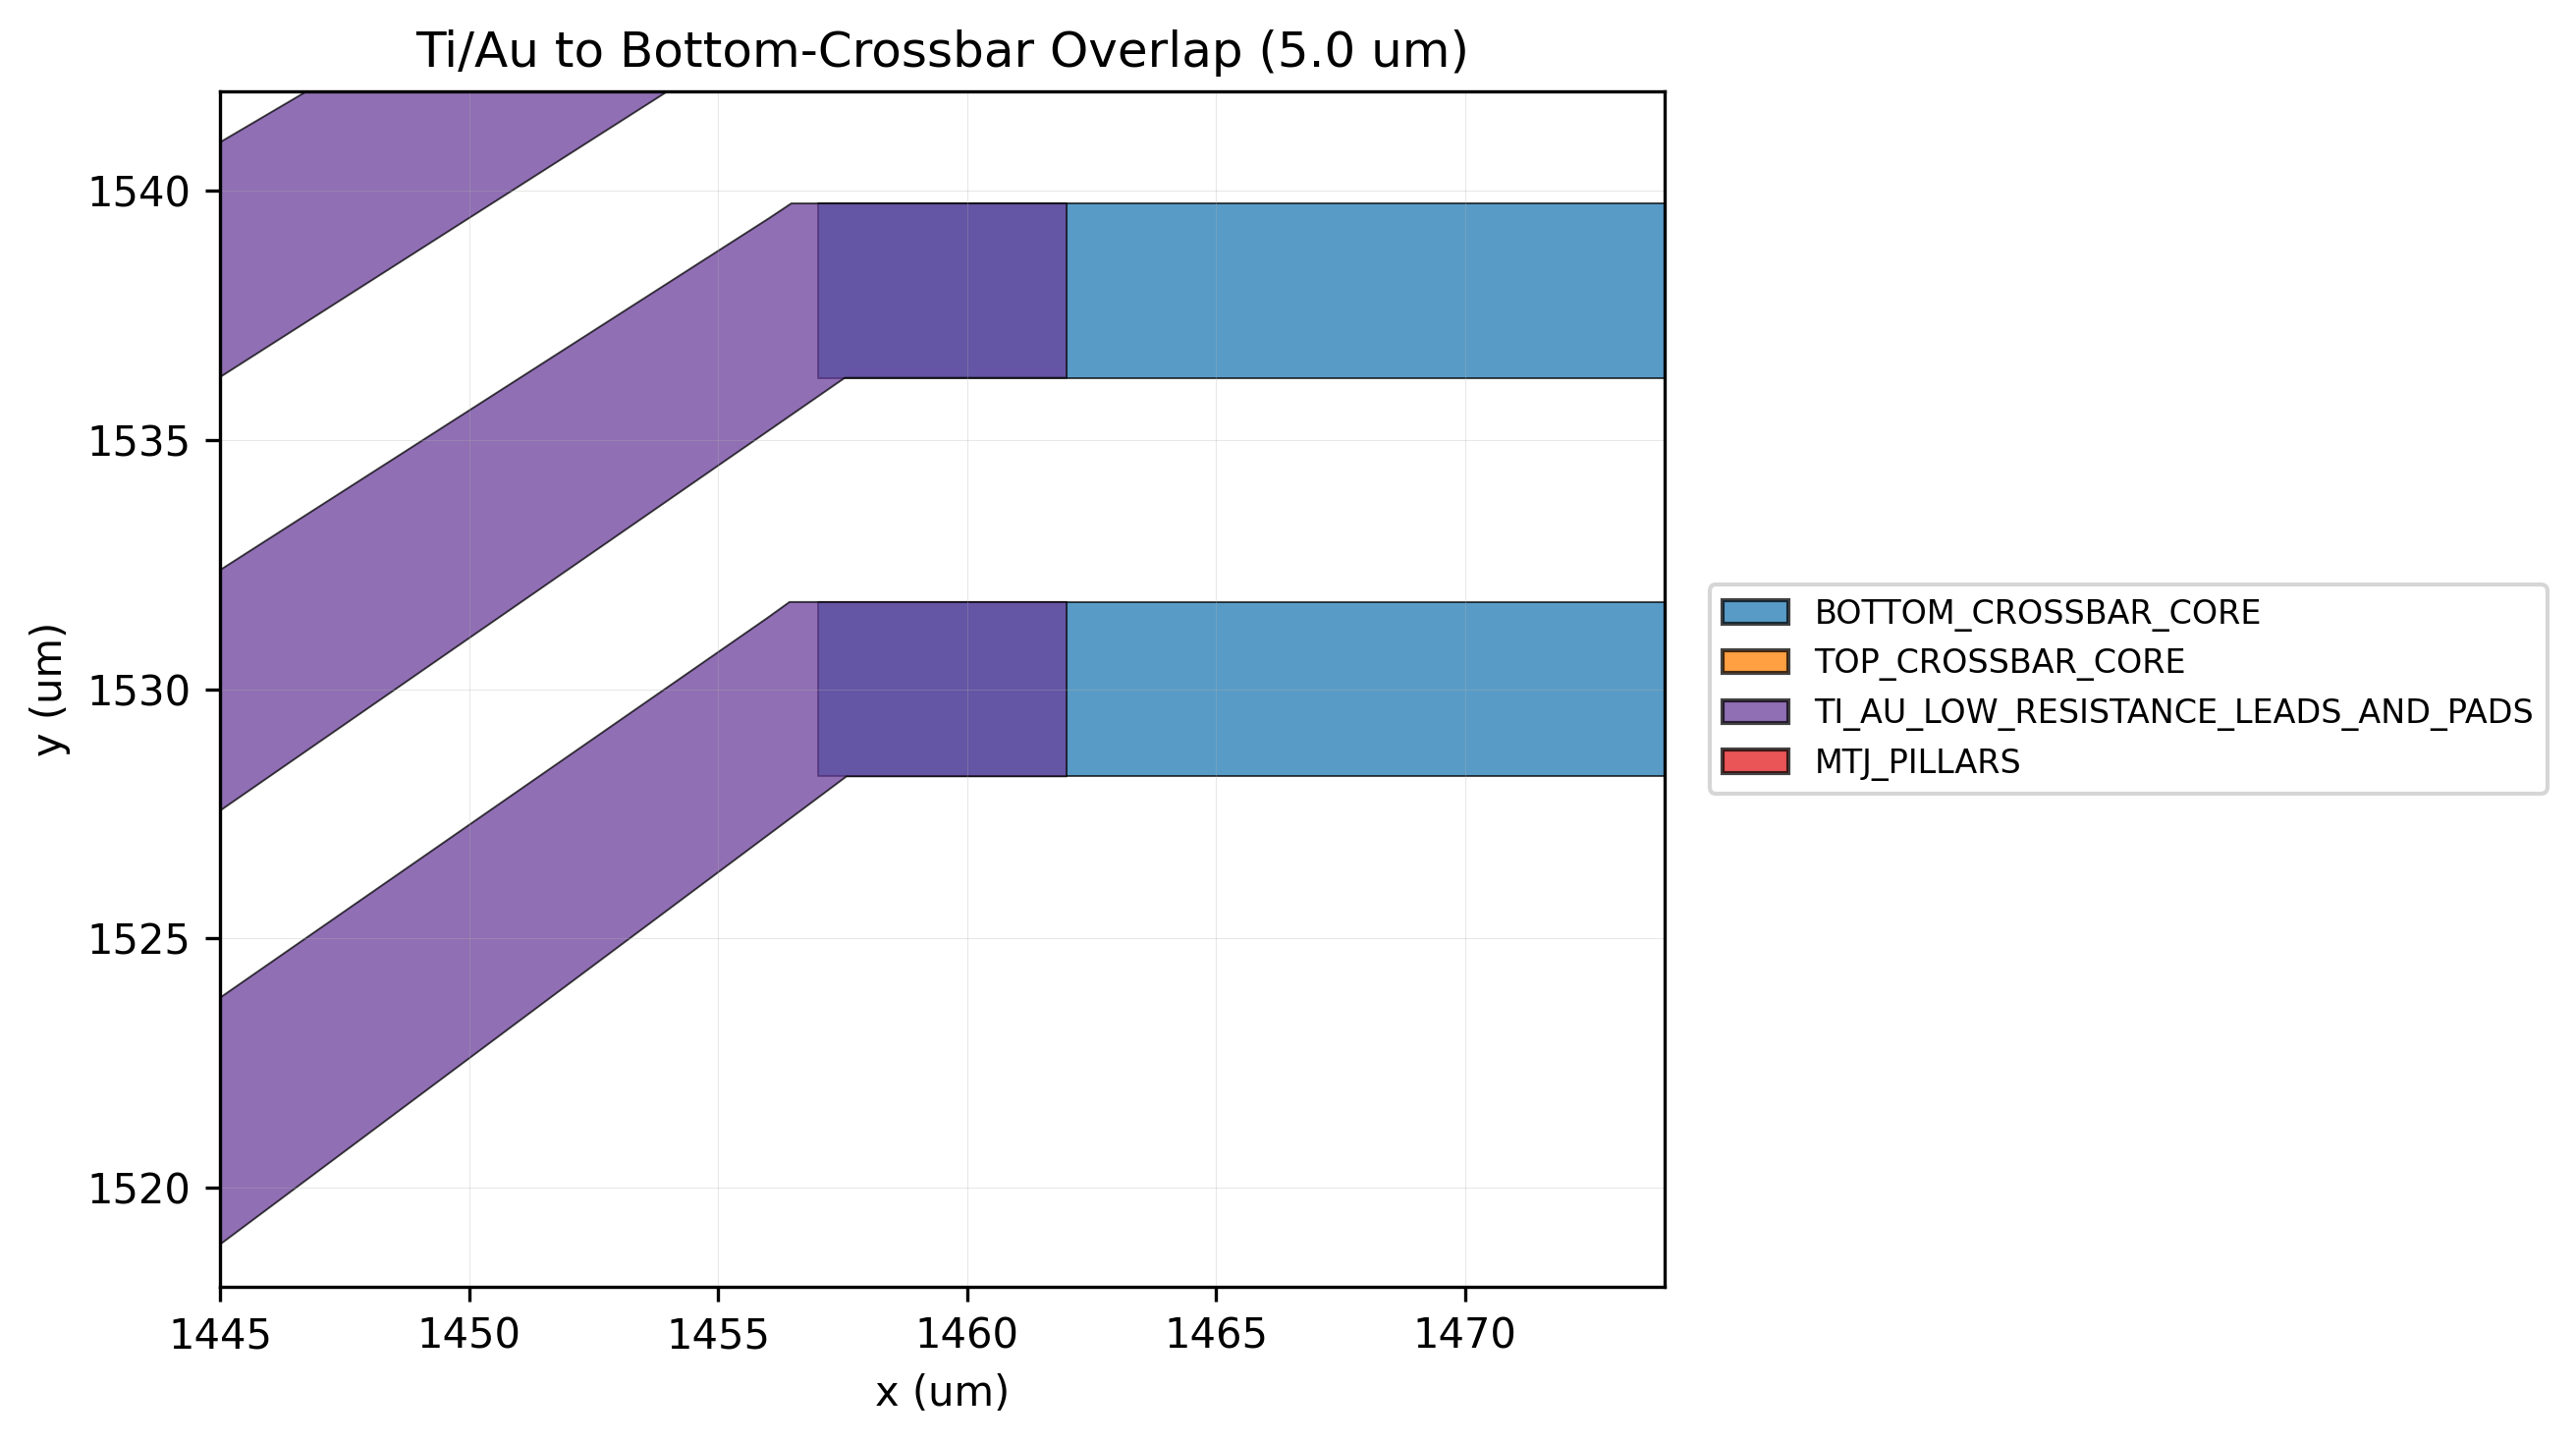

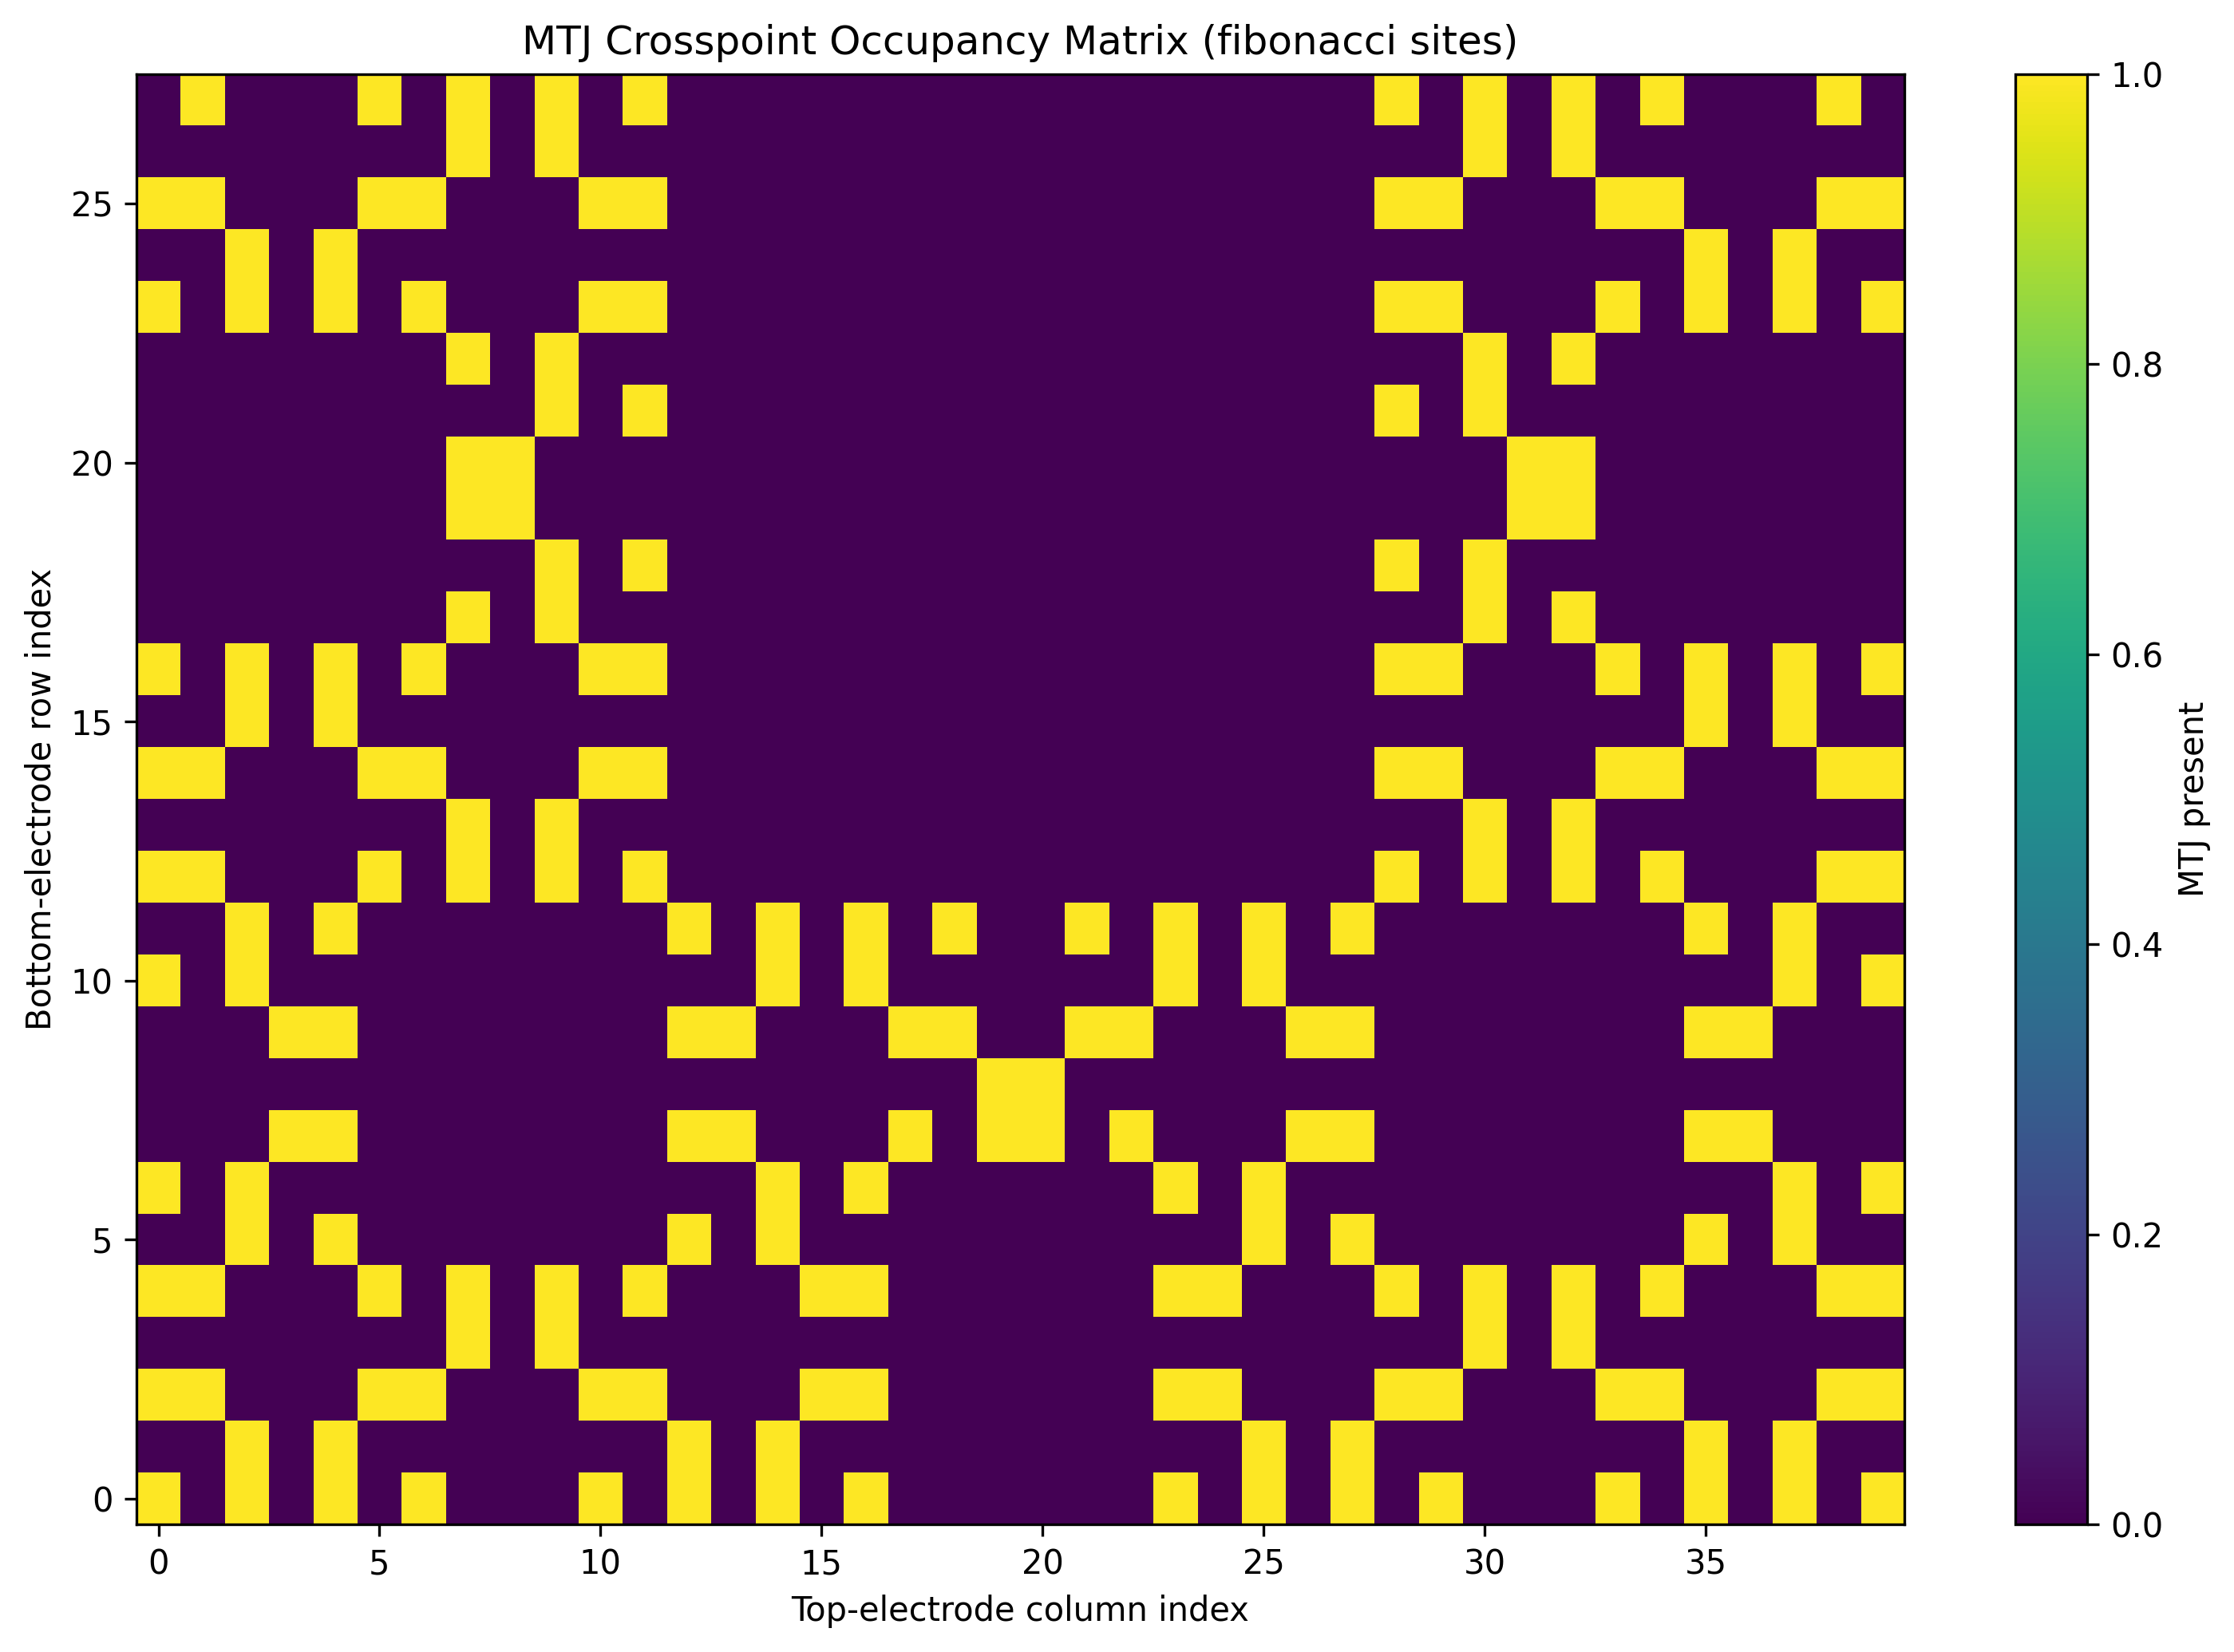

In [6]:
"""Generate a split-metal adaptive Fibonacci-site MTJ crossbar.

The Fibonacci turtle construction supplies the candidate MTJ locations. The
active device region contains horizontal bottom-crossbar conductors, vertical
top-crossbar conductors, and a 100 nm MTJ at each populated Fibonacci
crosspoint. The two crossbar families remain on independent process layers and
retain the inherited 3.5 micrometer width.

The long pad fanouts are moved to one independent low-resistance Ti/Au mask
layer. Every Ti/Au lead overlaps its corresponding thin-film crossbar by a
configurable 5 micrometers at the fanout elbow. The lead width then increases
in quantized, piecewise-linear taper stages as conductor spacing expands toward
the perimeter pads. The width solver respects a same-layer edge-clearance
target and automatically reduces the widening profile if polygon-level checks
detect an impending short.

The farthest outer edges of the bottom-electrode and top-electrode pad banks
remain aligned to a common radial distance from the crossbar center. Changing
the Fibonacci order therefore regenerates the conductor count, fanout length,
pad count, pad placement, Ti/Au width profile, array envelope, and exported
hierarchy.

Default ``PILLAR_POPULATION_MODE`` preserves the Fibonacci bend-site mask. A
rectangular crossbar contains additional geometric row-column crossings where
that mask is sparse. Those inactive crossings receive no MTJ polygon. Set
``PILLAR_POPULATION_MODE = "all_crosspoints"`` to populate the complete
Cartesian crossbar.

GDSTK constructs fixed-width and variable-width metal polygons. PHIDL stores
the unit-cell hierarchy, builds the XY array, renders previews, and writes GDSII
or OASIS.
"""

from dataclasses import dataclass
from itertools import pairwise
from pathlib import Path
from typing import Final, Literal

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch, Rectangle
from phidl import Device

###############################################################
# Control knobs
###############################################################

# Output controls. Leave OUTPUT_BASENAME as None for an automatic name.
OUTPUT_BASENAME: Final[str | None] = None
OUTPUT_FORMAT: Final[Literal["gds", "oas"]] = "oas"
OUTPUT_DIRECTORY: Final[Path] = Path.cwd()

# Fibonacci site-generation controls.
FIBONACCI_ITERATIONS: Final[int] = 12  # Great options: 9, 12, 15, 18, 27 (27 requires ~25 minutes)
SEGMENT_LENGTH_UM: Final[float] = 8.000
TURN_ANGLE_DEG: Final[float] = 90.0
MIRROR_FRACTAL: Final[bool] = False
PILLAR_EVERY_NTH_BEND: Final[int] = 1

# Crossbar population behavior.
PILLAR_POPULATION_MODE: Final[Literal["fibonacci_sites", "all_crosspoints"]] = (
    "fibonacci_sites"
)
AXIS_CLUSTER_TOLERANCE_UM: Final[float] = 1.0e-5
# Distance from an outermost MTJ row-column intersection to the first fanout
# elbow. This directly controls the compact straight-arm length requested for
# the central crossbar.
CROSSBAR_TO_FANOUT_ELBOW_UM: Final[float] = 25.000  # Between 25 to 300 um is good.
MINIMUM_TRACE_EDGE_GAP_UM: Final[float] = 0.500

# The main crossbar width is borrowed from the uploaded reference script.
ELECTRODE_WIDTH_UM: Final[float] = 3.500
PATH_TOLERANCE_UM: Final[float] = 1.0e-3

# MTJ geometry.
PILLAR_DIAMETER_NM: Final[float] = 100.0  # 100 by default
PILLAR_CIRCLE_POINTS: Final[int] = 256
ENABLE_PILLAR_DATABASE_GRID_SNAP: Final[bool] = True

# Contact-pad geometry. Each pad is exactly 60 um by 60 um by default.
PAD_WIDTH_UM: Final[float] = 60.0
PAD_HEIGHT_UM: Final[float] = 60.0
PAD_EDGE_GAP_UM: Final[float] = 10.0  # Between 10 to 50 um is good.
PAD_STAGGER_DEPTH_UM: Final[float] = 100.0

# Align the farthest outer edges of the left/right bottom-electrode pads and
# bottom/top top-electrode pads to a common radius measured from the crossbar
# center. Extra radius expands every side equally after the natural minimum
# fanout lengths have been calculated.
ALIGN_OUTERMOST_PAD_EDGES: Final[bool] = True
PAD_PERIMETER_EXTRA_RADIUS_UM: Final[float] = 0.0
PAD_EDGE_ALIGNMENT_TOLERANCE_UM: Final[float] = 1.0e-6

# The taper base uses the full transverse pad dimension and narrows linearly to
# the adaptive Ti/Au terminal width. PAD_TAPER_NECK_LENGTH_UM leaves a short constant-width
# section between the taper tip and the fanout anchor.
PAD_TAPER_LENGTH_UM: Final[float] = 50.0
PAD_TAPER_NECK_LENGTH_UM: Final[float] = 10.0
MINIMUM_PAD_CLEARANCE_UM: Final[float] = 10.0

# Split-metal lead architecture. The main bottom and top crossbars stop at
# their elbows on independent layers. A shared Ti/Au lead-and-pad layer begins
# inside each elbow and overlaps the corresponding crossbar by 5 um.
CROSSBAR_LEAD_OVERLAP_UM: Final[float] = 5.0
LOW_RESISTANCE_LEAD_MAX_WIDTH_UM: Final[float] = 40.0
LOW_RESISTANCE_LEAD_EDGE_GAP_UM: Final[float] = 2.0
LOW_RESISTANCE_LEAD_WIDTH_UTILIZATION: Final[float] = 0.90
LOW_RESISTANCE_LEAD_WIDTH_QUANTUM_UM: Final[float] = 0.50
LOW_RESISTANCE_LEAD_STAGE_FRACTIONS: Final[tuple[float, ...]] = (
    0.00,
    0.05,
    0.12,
    0.25,
    0.45,
    0.70,
    1.00,
)
AUTO_REDUCE_LEAD_WIDTHS_FOR_CLEARANCE: Final[bool] = True
LEAD_WIDTH_REDUCTION_FACTOR: Final[float] = 0.90
MAX_LEAD_WIDTH_REDUCTION_ITERATIONS: Final[int] = 12
LEAD_BOOLEAN_PRECISION_UM: Final[float] = 1.0e-3
LEAD_CLEARANCE_AREA_TOLERANCE_UM2: Final[float] = 1.0e-5

# Optional resistance estimate. Leave as None to report geometry in squares
# without assigning a process-dependent Ti/Au sheet resistance.
ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE: Final[float | None] = None

# Fanout controls. Automatic mode limits the angle between a fanout segment
# and its outward routing direction. Larger angles shorten the device.
AUTO_FANOUT_LENGTH: Final[bool] = True
MAX_FANOUT_ANGLE_DEG: Final[float] = 45.0
MIN_FANOUT_LENGTH_UM: Final[float] = 250.0
FIXED_FANOUT_LENGTH_UM: Final[float] = 500.0

# Unit-cell and XY-array controls.
ARRAY_SIZE_X: Final[int] = 1
ARRAY_SIZE_Y: Final[int] = 1
CELL_MARGIN_UM: Final[float] = 40.0
ARRAY_CELL_EDGE_GAP_X_UM: Final[float] = 100.0
ARRAY_CELL_EDGE_GAP_Y_UM: Final[float] = 100.0

# GDSII and OASIS database controls. A 0.1 nm grid accurately resolves a
# 100 nm pillar and avoids integer-coordinate overflow for millimeter fanouts.
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-10
GDS_INTEGER_COORDINATE_LIMIT: Final[int] = 2_000_000_000
OAS_CIRCLE_TOLERANCE_UM: Final[float] = 2.0e-4

# Notebook display controls.
DISPLAY_FULL_ARRAY: Final[bool] = True
DISPLAY_ACTIVE_CROSSBAR_ZOOM: Final[bool] = True
DISPLAY_FIRST_CROSSPOINT_DETAIL: Final[bool] = True
DISPLAY_FIRST_PAD_TAPER_DETAIL: Final[bool] = True
DISPLAY_FIRST_CROSSBAR_OVERLAP_DETAIL: Final[bool] = True
DISPLAY_OCCUPANCY_MATRIX: Final[bool] = True
DOWNLOAD_AFTER_EXPORT_IN_COLAB: Final[bool] = False

PREVIEW_DPI: Final[int] = 300
PREVIEW_FIGSIZE_IN: Final[tuple[float, float]] = (13.0, 10.0)
PREVIEW_PADDING_UM: Final[float] = 80.0
PREVIEW_EDGE_LINEWIDTH: Final[float] = 0.16
PREVIEW_ALPHA: Final[float] = 0.62
CROSSBAR_ZOOM_PADDING_UM: Final[float] = 40.0
CROSSPOINT_DETAIL_HALF_WINDOW_UM: Final[float] = 4.0
PAD_TAPER_DETAIL_PADDING_UM: Final[float] = 20.0
OVERLAP_DETAIL_PADDING_UM: Final[float] = 12.0
SHOW_CELL_BOUNDARIES_IN_PREVIEW: Final[bool] = True
SHOW_PAD_LABELS_IN_PREVIEW: Final[bool] = False
PAD_LABEL_FONT_SIZE_PT: Final[float] = 4.5

DATABASE_GRID_UM: Final[float] = GDS_PRECISION_M / GDS_UNIT_M
DATABASE_GRID_NM: Final[float] = DATABASE_GRID_UM * 1.0e3

mpl.rcParams["figure.dpi"] = PREVIEW_DPI
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"

Coordinate = tuple[float, float]
Polygon = list[Coordinate]
ElectrodeKind = Literal["bottom", "top"]
PadSide = Literal["left", "right", "bottom", "top"]


@dataclass(frozen=True)
class LayerSpec:
    """Describe one exported and previewed layout layer.

    Attributes:
        name: Human-readable layer name.
        layer: GDSII layer number.
        datatype: GDSII datatype number.
        color: Matplotlib preview color.
    """

    name: str
    layer: int
    datatype: int
    color: str


@dataclass(frozen=True)
class BoundingBox:
    """Store an axis-aligned bounding box in micrometers."""

    xmin: float
    ymin: float
    xmax: float
    ymax: float

    @property
    def width(self) -> float:
        """Return the bounding-box width."""
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        """Return the bounding-box height."""
        return self.ymax - self.ymin

    def translated(self, shift: Coordinate) -> "BoundingBox":
        """Return a translated copy of the bounding box."""
        return BoundingBox(
            xmin=self.xmin + shift[0],
            ymin=self.ymin + shift[1],
            xmax=self.xmax + shift[0],
            ymax=self.ymax + shift[1],
        )


@dataclass(frozen=True)
class PadTerminal:
    """Describe one rectangular Ti/Au perimeter contact pad.

    Attributes:
        name: Unique terminal name.
        electrode: Crossbar family contacted by this terminal.
        side: Physical side of the crossbar.
        conductor_index: Row or column conductor index.
        center: Pad center coordinate in micrometers.
        width_um: Pad x dimension.
        height_um: Pad y dimension.
        lead_width_um: Ti/Au lead width at the narrow taper tip.
    """

    name: str
    electrode: ElectrodeKind
    side: PadSide
    conductor_index: int
    center: Coordinate
    width_um: float
    height_um: float
    lead_width_um: float

    @property
    def bounds(self) -> BoundingBox:
        """Return the pad rectangle bounds."""
        half_width = 0.5 * self.width_um
        half_height = 0.5 * self.height_um
        return BoundingBox(
            xmin=self.center[0] - half_width,
            ymin=self.center[1] - half_height,
            xmax=self.center[0] + half_width,
            ymax=self.center[1] + half_height,
        )


@dataclass(frozen=True)
class RoutedTrace:
    """Describe one fixed-width main crossbar conductor."""

    name: str
    electrode: ElectrodeKind
    conductor_index: int
    axis_coordinate_um: float
    centerline_points: tuple[Coordinate, ...]


@dataclass(frozen=True)
class VariableWidthLead:
    """Describe one variable-width Ti/Au pad-to-crossbar lead."""

    name: str
    electrode: ElectrodeKind
    side: PadSide
    conductor_index: int
    centerline_points: tuple[Coordinate, ...]
    widths_um: tuple[float, ...]

    def __post_init__(self) -> None:
        """Validate point and width cardinality."""
        if len(self.centerline_points) < 2:
            raise ValueError("A Ti/Au lead requires at least two points.")
        if len(self.centerline_points) != len(self.widths_um):
            raise ValueError(
                "A Ti/Au lead requires one width value per centerline point."
            )
        if any(width <= 0.0 for width in self.widths_um):
            raise ValueError("Every Ti/Au lead width must be positive.")

    @property
    def terminal_width_um(self) -> float:
        """Return the width meeting the pad taper tip."""
        return self.widths_um[-1]


@dataclass(frozen=True)
class LeadClearanceResult:
    """Store the result of a Ti/Au same-layer clearance check."""

    is_valid: bool
    message: str


@dataclass(frozen=True)
class CrossbarGeometry:
    """Store generated unit-cell geometry and topology metadata."""

    fibonacci_word: str
    detected_bend_count: int
    selected_fibonacci_site_count: int
    fibonacci_crosspoint_indices: tuple[tuple[int, int], ...]
    populated_crosspoint_indices: tuple[tuple[int, int], ...]
    row_coordinates_um: tuple[float, ...]
    column_coordinates_um: tuple[float, ...]
    pillar_centers: tuple[Coordinate, ...]
    bottom_routes: tuple[RoutedTrace, ...]
    top_routes: tuple[RoutedTrace, ...]
    lead_routes: tuple[VariableWidthLead, ...]
    pads: tuple[PadTerminal, ...]
    crossbar_bounds: BoundingBox
    routing_transition_bounds: BoundingBox
    bounds: BoundingBox
    row_fanout_length_um: float
    column_fanout_length_um: float
    maximum_row_fanout_angle_deg: float
    maximum_column_fanout_angle_deg: float
    bottom_pad_outer_edge_radius_um: float
    top_pad_outer_edge_radius_um: float
    bottom_pad_alignment_extension_um: float
    top_pad_alignment_extension_um: float
    bottom_lead_width_profile_um: tuple[float, ...]
    top_lead_width_profile_um: tuple[float, ...]
    lead_width_scale: float


LAYERS: Final[dict[str, LayerSpec]] = {
    "BOTTOM_ELECTRODE": LayerSpec(
        name="BOTTOM_CROSSBAR_CORE",
        layer=2,
        datatype=0,
        color="#1f78b4",
    ),
    "MTJ_PILLARS": LayerSpec(
        name="MTJ_PILLARS",
        layer=3,
        datatype=0,
        color="#e31a1c",
    ),
    "TOP_ELECTRODE": LayerSpec(
        name="TOP_CROSSBAR_CORE",
        layer=4,
        datatype=0,
        color="#ff7f00",
    ),
    "TI_AU_LEADS": LayerSpec(
        name="TI_AU_LOW_RESISTANCE_LEADS_AND_PADS",
        layer=5,
        datatype=0,
        color="#6a3d9a",
    ),
}


def validate_control_knobs() -> None:
    """Validate all user-adjustable geometry and database controls."""
    if FIBONACCI_ITERATIONS < 1:
        raise ValueError("FIBONACCI_ITERATIONS must be at least 1.")
    if SEGMENT_LENGTH_UM <= 0.0:
        raise ValueError("SEGMENT_LENGTH_UM must be positive.")
    if not 0.0 < TURN_ANGLE_DEG < 180.0:
        raise ValueError("TURN_ANGLE_DEG must lie between 0 and 180 degrees.")
    if PILLAR_EVERY_NTH_BEND < 1:
        raise ValueError("PILLAR_EVERY_NTH_BEND must be at least 1.")
    if PILLAR_POPULATION_MODE not in {
        "fibonacci_sites",
        "all_crosspoints",
    }:
        raise ValueError(
            "PILLAR_POPULATION_MODE must be 'fibonacci_sites' or 'all_crosspoints'."
        )
    if AXIS_CLUSTER_TOLERANCE_UM <= 0.0:
        raise ValueError("AXIS_CLUSTER_TOLERANCE_UM must be positive.")
    if CROSSBAR_TO_FANOUT_ELBOW_UM <= 0.0:
        raise ValueError("CROSSBAR_TO_FANOUT_ELBOW_UM must be positive.")
    if ELECTRODE_WIDTH_UM <= 0.0:
        raise ValueError("ELECTRODE_WIDTH_UM must be positive.")
    if SEGMENT_LENGTH_UM <= ELECTRODE_WIDTH_UM + MINIMUM_TRACE_EDGE_GAP_UM:
        raise ValueError(
            "SEGMENT_LENGTH_UM must exceed ELECTRODE_WIDTH_UM plus "
            "MINIMUM_TRACE_EDGE_GAP_UM."
        )
    if PATH_TOLERANCE_UM <= 0.0:
        raise ValueError("PATH_TOLERANCE_UM must be positive.")
    if PILLAR_DIAMETER_NM <= 0.0:
        raise ValueError("PILLAR_DIAMETER_NM must be positive.")
    if PILLAR_CIRCLE_POINTS < 32:
        raise ValueError("PILLAR_CIRCLE_POINTS must be at least 32.")

    pillar_diameter_um = PILLAR_DIAMETER_NM * 1.0e-3
    if pillar_diameter_um > ELECTRODE_WIDTH_UM:
        raise ValueError("PILLAR_DIAMETER_NM must fit inside the crossbar width.")

    if PAD_WIDTH_UM <= 0.0 or PAD_HEIGHT_UM <= 0.0:
        raise ValueError("PAD_WIDTH_UM and PAD_HEIGHT_UM must be positive.")
    if PAD_EDGE_GAP_UM < 0.0:
        raise ValueError("PAD_EDGE_GAP_UM must be nonnegative.")
    if PAD_STAGGER_DEPTH_UM < 0.0:
        raise ValueError("PAD_STAGGER_DEPTH_UM must be nonnegative.")
    if PAD_PERIMETER_EXTRA_RADIUS_UM < 0.0:
        raise ValueError("PAD_PERIMETER_EXTRA_RADIUS_UM must be nonnegative.")
    if PAD_EDGE_ALIGNMENT_TOLERANCE_UM <= 0.0:
        raise ValueError("PAD_EDGE_ALIGNMENT_TOLERANCE_UM must be positive.")
    if PAD_TAPER_LENGTH_UM <= 0.0:
        raise ValueError("PAD_TAPER_LENGTH_UM must be positive.")
    if PAD_TAPER_NECK_LENGTH_UM < 0.0:
        raise ValueError("PAD_TAPER_NECK_LENGTH_UM must be nonnegative.")
    if MINIMUM_PAD_CLEARANCE_UM < 0.0:
        raise ValueError("MINIMUM_PAD_CLEARANCE_UM must be nonnegative.")

    minimum_corner_offset_um = (
        ELECTRODE_WIDTH_UM + MINIMUM_TRACE_EDGE_GAP_UM
    ) / np.sqrt(2.0)
    if CROSSBAR_TO_FANOUT_ELBOW_UM < minimum_corner_offset_um:
        raise ValueError(
            "CROSSBAR_TO_FANOUT_ELBOW_UM is too short to preserve the "
            "requested finite-width corner clearance. Use at least "
            f"{minimum_corner_offset_um:.3f} um."
        )
    if CROSSBAR_LEAD_OVERLAP_UM <= 0.0:
        raise ValueError("CROSSBAR_LEAD_OVERLAP_UM must be positive.")
    if CROSSBAR_LEAD_OVERLAP_UM >= CROSSBAR_TO_FANOUT_ELBOW_UM:
        raise ValueError(
            "CROSSBAR_LEAD_OVERLAP_UM must remain smaller than "
            "CROSSBAR_TO_FANOUT_ELBOW_UM so the shared Ti/Au layer cannot "
            "reach an orthogonal crossbar column or row."
        )
    if LOW_RESISTANCE_LEAD_MAX_WIDTH_UM < ELECTRODE_WIDTH_UM:
        raise ValueError(
            "LOW_RESISTANCE_LEAD_MAX_WIDTH_UM must be at least the crossbar width."
        )
    if LOW_RESISTANCE_LEAD_MAX_WIDTH_UM > min(PAD_WIDTH_UM, PAD_HEIGHT_UM):
        raise ValueError(
            "LOW_RESISTANCE_LEAD_MAX_WIDTH_UM must fit inside both pad dimensions."
        )
    if LOW_RESISTANCE_LEAD_EDGE_GAP_UM < 0.0:
        raise ValueError("LOW_RESISTANCE_LEAD_EDGE_GAP_UM must be nonnegative.")
    if not 0.0 < LOW_RESISTANCE_LEAD_WIDTH_UTILIZATION <= 1.0:
        raise ValueError("LOW_RESISTANCE_LEAD_WIDTH_UTILIZATION must lie in (0, 1].")
    if LOW_RESISTANCE_LEAD_WIDTH_QUANTUM_UM <= 0.0:
        raise ValueError("LOW_RESISTANCE_LEAD_WIDTH_QUANTUM_UM must be positive.")
    fractions = LOW_RESISTANCE_LEAD_STAGE_FRACTIONS
    if len(fractions) < 2:
        raise ValueError(
            "LOW_RESISTANCE_LEAD_STAGE_FRACTIONS requires at least two entries."
        )
    if not np.isclose(fractions[0], 0.0) or not np.isclose(
        fractions[-1],
        1.0,
    ):
        raise ValueError(
            "LOW_RESISTANCE_LEAD_STAGE_FRACTIONS must start at 0 and end at 1."
        )
    if any(later <= earlier for earlier, later in pairwise(fractions)):
        raise ValueError(
            "LOW_RESISTANCE_LEAD_STAGE_FRACTIONS must be strictly increasing."
        )
    if not 0.0 < LEAD_WIDTH_REDUCTION_FACTOR < 1.0:
        raise ValueError("LEAD_WIDTH_REDUCTION_FACTOR must lie between 0 and 1.")
    if MAX_LEAD_WIDTH_REDUCTION_ITERATIONS < 1:
        raise ValueError("MAX_LEAD_WIDTH_REDUCTION_ITERATIONS must be at least 1.")
    if LEAD_BOOLEAN_PRECISION_UM <= 0.0:
        raise ValueError("LEAD_BOOLEAN_PRECISION_UM must be positive.")
    if LEAD_CLEARANCE_AREA_TOLERANCE_UM2 < 0.0:
        raise ValueError("LEAD_CLEARANCE_AREA_TOLERANCE_UM2 must be nonnegative.")
    if (
        ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE is not None
        and ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE <= 0.0
    ):
        raise ValueError(
            "ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE must be positive or None."
        )

    if not 0.0 < MAX_FANOUT_ANGLE_DEG < 89.0:
        raise ValueError("MAX_FANOUT_ANGLE_DEG must lie between 0 and 89.")
    if MIN_FANOUT_LENGTH_UM <= 0.0:
        raise ValueError("MIN_FANOUT_LENGTH_UM must be positive.")
    if FIXED_FANOUT_LENGTH_UM <= 0.0:
        raise ValueError("FIXED_FANOUT_LENGTH_UM must be positive.")
    if ARRAY_SIZE_X < 1 or ARRAY_SIZE_Y < 1:
        raise ValueError("ARRAY_SIZE_X and ARRAY_SIZE_Y must be at least 1.")
    if CELL_MARGIN_UM < 0.0:
        raise ValueError("CELL_MARGIN_UM must be nonnegative.")
    if ARRAY_CELL_EDGE_GAP_X_UM <= 0.0:
        raise ValueError("ARRAY_CELL_EDGE_GAP_X_UM must be positive.")
    if ARRAY_CELL_EDGE_GAP_Y_UM <= 0.0:
        raise ValueError("ARRAY_CELL_EDGE_GAP_Y_UM must be positive.")
    if GDS_PRECISION_M <= 0.0 or GDS_UNIT_M <= 0.0:
        raise ValueError("GDS unit and precision values must be positive.")


def fibonacci_word(iterations: int) -> str:
    """Return the canonical Fibonacci word F_n.

    Args:
        iterations: Fibonacci word index with F_0 = "0" and F_1 = "01".

    Returns:
        Fibonacci word at the requested index.
    """
    if iterations == 0:
        return "0"
    if iterations == 1:
        return "01"

    previous_previous = "0"
    previous = "01"
    for _ in range(2, iterations + 1):
        current = previous + previous_previous
        previous_previous = previous
        previous = current

    return previous


def normalize_vector(vector: np.ndarray) -> np.ndarray:
    """Return a unit vector.

    Args:
        vector: Input vector.

    Returns:
        Unit vector with floating-point components.
    """
    norm = float(np.linalg.norm(vector))
    if norm <= 0.0:
        raise ValueError("A zero-length direction vector was generated.")
    return vector / norm


def rotate_direction(direction: np.ndarray, turn_sign: int) -> np.ndarray:
    """Rotate a direction by the configured signed turn angle.

    Args:
        direction: Two-component unit vector.
        turn_sign: +1 for a left turn and -1 for a right turn.

    Returns:
        Rotated unit vector.
    """
    if turn_sign not in {-1, 1}:
        raise ValueError("turn_sign must be +1 or -1.")

    angle_rad = np.deg2rad(turn_sign * TURN_ANGLE_DEG)
    rotation_matrix = np.array(
        [
            [np.cos(angle_rad), -np.sin(angle_rad)],
            [np.sin(angle_rad), np.cos(angle_rad)],
        ],
        dtype=float,
    )
    return normalize_vector(rotation_matrix @ direction)


def build_raw_centerline(word: str, step_um: float) -> np.ndarray:
    """Apply the odd-even drawing rule and return every segment endpoint.

    Args:
        word: Fibonacci word containing zero and one symbols.
        step_um: Centerline segment length in micrometers.

    Returns:
        Array with shape (len(word) + 1, 2).
    """
    position = np.array([0.0, 0.0], dtype=float)
    direction = np.array([1.0, 0.0], dtype=float)
    points = [position.copy()]
    mirror_sign = -1 if MIRROR_FRACTAL else 1

    for one_based_position, symbol in enumerate(word, start=1):
        position = position + step_um * direction
        points.append(position.copy())

        is_final_symbol = one_based_position == len(word)
        if symbol == "1" or is_final_symbol:
            continue
        if symbol != "0":
            raise ValueError(f"Unexpected Fibonacci word symbol: {symbol!r}")

        turn_sign = 1 if one_based_position % 2 == 0 else -1
        direction = rotate_direction(
            direction=direction,
            turn_sign=mirror_sign * turn_sign,
        )

    return np.asarray(points, dtype=float)


def find_bend_centers(raw_points: np.ndarray) -> list[Coordinate]:
    """Return the centerline coordinate of every true direction change.

    Args:
        raw_points: Every segment endpoint from the turtle construction.

    Returns:
        Ordered bend-center coordinates.
    """
    bend_centers: list[Coordinate] = []

    for point_index in range(1, len(raw_points) - 1):
        incoming = normalize_vector(
            raw_points[point_index] - raw_points[point_index - 1]
        )
        outgoing = normalize_vector(
            raw_points[point_index + 1] - raw_points[point_index]
        )
        cross_z = incoming[0] * outgoing[1] - incoming[1] * outgoing[0]
        if np.isclose(cross_z, 0.0, atol=1.0e-12):
            continue

        bend_centers.append(
            (
                float(raw_points[point_index, 0]),
                float(raw_points[point_index, 1]),
            )
        )

    return bend_centers


def deduplicate_coordinates(
    coordinates: list[Coordinate],
    grid_um: float,
) -> list[Coordinate]:
    """Remove duplicate coordinates after grid quantization.

    Args:
        coordinates: Coordinates to deduplicate.
        grid_um: Quantization grid in micrometers.

    Returns:
        Ordered unique coordinates.
    """
    if grid_um <= 0.0:
        raise ValueError("grid_um must be positive.")

    unique_coordinates: list[Coordinate] = []
    seen: set[tuple[int, int]] = set()

    for x_coord, y_coord in coordinates:
        key = (
            int(round(x_coord / grid_um)),
            int(round(y_coord / grid_um)),
        )
        if key in seen:
            continue
        seen.add(key)
        unique_coordinates.append((x_coord, y_coord))

    return unique_coordinates


def cluster_axis_values(
    values: list[float],
    tolerance_um: float,
) -> tuple[tuple[float, ...], tuple[int, ...]]:
    """Cluster nearly equal axis coordinates and return site assignments.

    Args:
        values: Axis coordinates in original site order.
        tolerance_um: Maximum separation retained in one coordinate cluster.

    Returns:
        Sorted cluster centers and one cluster index per original value.
    """
    if len(values) == 0:
        raise ValueError("At least one axis value is required.")
    if tolerance_um <= 0.0:
        raise ValueError("tolerance_um must be positive.")

    sorted_pairs = sorted(enumerate(values), key=lambda pair: pair[1])
    clusters: list[list[tuple[int, float]]] = []

    for original_index, value in sorted_pairs:
        if len(clusters) == 0:
            clusters.append([(original_index, value)])
            continue

        previous_values = [member_value for _, member_value in clusters[-1]]
        cluster_center = float(np.mean(previous_values))
        if abs(value - cluster_center) <= tolerance_um:
            clusters[-1].append((original_index, value))
        else:
            clusters.append([(original_index, value)])

    centers = tuple(
        float(np.mean([value for _, value in cluster])) for cluster in clusters
    )
    assignments = [-1] * len(values)
    for cluster_index, cluster in enumerate(clusters):
        for original_index, _ in cluster:
            assignments[original_index] = cluster_index

    if any(index < 0 for index in assignments):
        raise RuntimeError("Axis clustering left an unassigned coordinate.")

    return centers, tuple(assignments)


def centered_slot_positions(count: int, pitch_um: float) -> tuple[float, ...]:
    """Return evenly spaced pad-bank positions centered about zero."""
    if count < 1:
        raise ValueError("count must be at least 1.")
    if pitch_um <= 0.0:
        raise ValueError("pitch_um must be positive.")

    center_index = 0.5 * (count - 1)
    return tuple((index - center_index) * pitch_um for index in range(count))


def compute_fanout_length(
    conductor_coordinates_um: tuple[float, ...],
    pad_slot_coordinates_um: tuple[float, ...],
) -> tuple[float, float]:
    """Compute a fanout run and its resulting maximum route angle.

    Args:
        conductor_coordinates_um: Sorted row or column coordinates.
        pad_slot_coordinates_um: Corresponding sorted pad-bank coordinates.

    Returns:
        Fanout length and maximum absolute fanout angle in degrees.
    """
    if len(conductor_coordinates_um) != len(pad_slot_coordinates_um):
        raise ValueError("Conductor and pad-slot counts must match.")

    displacements = np.abs(
        np.asarray(pad_slot_coordinates_um, dtype=float)
        - np.asarray(conductor_coordinates_um, dtype=float)
    )
    maximum_displacement_um = float(np.max(displacements))

    if AUTO_FANOUT_LENGTH:
        maximum_angle_rad = np.deg2rad(MAX_FANOUT_ANGLE_DEG)
        angular_length_um = maximum_displacement_um / np.tan(maximum_angle_rad)
        fanout_length_um = max(MIN_FANOUT_LENGTH_UM, angular_length_um)
    else:
        fanout_length_um = FIXED_FANOUT_LENGTH_UM

    resulting_angle_deg = float(
        np.rad2deg(np.arctan2(maximum_displacement_um, fanout_length_um))
    )
    return fanout_length_um, resulting_angle_deg


def maximum_fanout_angle(
    conductor_coordinates_um: tuple[float, ...],
    pad_slot_coordinates_um: tuple[float, ...],
    fanout_length_um: float,
) -> float:
    """Return the maximum route angle for a prescribed fanout length.

    Args:
        conductor_coordinates_um: Sorted row or column coordinates.
        pad_slot_coordinates_um: Corresponding sorted pad-bank coordinates.
        fanout_length_um: Outward fanout run in micrometers.

    Returns:
        Maximum absolute route angle in degrees.
    """
    if len(conductor_coordinates_um) != len(pad_slot_coordinates_um):
        raise ValueError("Conductor and pad-slot counts must match.")
    if fanout_length_um <= 0.0:
        raise ValueError("fanout_length_um must be positive.")

    displacements = np.abs(
        np.asarray(pad_slot_coordinates_um, dtype=float)
        - np.asarray(conductor_coordinates_um, dtype=float)
    )
    maximum_displacement_um = float(np.max(displacements))
    return float(np.rad2deg(np.arctan2(maximum_displacement_um, fanout_length_um)))


def predicted_pad_outer_edge_radius(
    elbow_radius_um: float,
    fanout_length_um: float,
    outward_pad_dimension_um: float,
) -> float:
    """Return the farthest staggered pad-edge radius from the origin.

    Args:
        elbow_radius_um: Radial distance from the origin to the fanout elbow.
        fanout_length_um: Outward run from the elbow to the fanout anchor.
        outward_pad_dimension_um: Pad dimension along the outward direction.

    Returns:
        Farthest pad-edge radius in micrometers.
    """
    if elbow_radius_um < 0.0:
        raise ValueError("elbow_radius_um must be nonnegative.")
    if fanout_length_um <= 0.0:
        raise ValueError("fanout_length_um must be positive.")
    if outward_pad_dimension_um <= 0.0:
        raise ValueError("outward_pad_dimension_um must be positive.")

    return (
        elbow_radius_um
        + fanout_length_um
        + PAD_TAPER_NECK_LENGTH_UM
        + PAD_TAPER_LENGTH_UM
        + outward_pad_dimension_um
        + PAD_STAGGER_DEPTH_UM
    )


def quantize_width_down(width_um: float) -> float:
    """Quantize a width downward to the configured fabrication increment."""
    quantum_um = LOW_RESISTANCE_LEAD_WIDTH_QUANTUM_UM
    quantized = np.floor(width_um / quantum_um + 1.0e-12) * quantum_um
    return float(max(ELECTRODE_WIDTH_UM, quantized))


def compute_adaptive_lead_width_profile(
    conductor_coordinates_um: tuple[float, ...],
    pad_slot_coordinates_um: tuple[float, ...],
    maximum_fanout_angle_deg: float,
) -> tuple[float, ...]:
    """Compute a monotonic Ti/Au width profile from local route spacing.

    Each profile station follows the normalized fanout coordinate from the
    crossbar elbow to the outer routing anchor. The local centerline spacing is
    projected conservatively onto a route-normal direction using the maximum
    family fanout angle. A utilization factor and width quantization leave
    process margin beyond the requested same-layer edge clearance.
    """
    if len(conductor_coordinates_um) != len(pad_slot_coordinates_um):
        raise ValueError("Conductor and pad-slot counts must match.")

    conductor_array = np.asarray(conductor_coordinates_um, dtype=float)
    pad_slot_array = np.asarray(pad_slot_coordinates_um, dtype=float)
    projection_factor = float(np.cos(np.deg2rad(maximum_fanout_angle_deg)))

    widths_um: list[float] = []
    previous_width_um = ELECTRODE_WIDTH_UM
    for fraction in LOW_RESISTANCE_LEAD_STAGE_FRACTIONS:
        interpolated_coordinates = (
            1.0 - fraction
        ) * conductor_array + fraction * pad_slot_array
        if len(interpolated_coordinates) < 2:
            minimum_spacing_um = float("inf")
        else:
            minimum_spacing_um = float(np.min(np.diff(interpolated_coordinates)))

        projected_spacing_um = minimum_spacing_um * projection_factor
        available_width_um = projected_spacing_um - LOW_RESISTANCE_LEAD_EDGE_GAP_UM
        target_width_um = min(
            LOW_RESISTANCE_LEAD_MAX_WIDTH_UM,
            LOW_RESISTANCE_LEAD_WIDTH_UTILIZATION * available_width_um,
        )
        width_um = quantize_width_down(target_width_um)
        width_um = max(previous_width_um, width_um)
        widths_um.append(width_um)
        previous_width_um = width_um

    widths_um[0] = ELECTRODE_WIDTH_UM
    return tuple(float(width) for width in widths_um)


def scale_lead_width_profile(
    nominal_profile_um: tuple[float, ...],
    scale: float,
) -> tuple[float, ...]:
    """Scale profile widening above the crossbar width and requantize it."""
    if not 0.0 <= scale <= 1.0:
        raise ValueError("Lead width scale must lie between 0 and 1.")

    scaled_widths: list[float] = []
    previous_width_um = ELECTRODE_WIDTH_UM
    for nominal_width_um in nominal_profile_um:
        expanded_width_um = ELECTRODE_WIDTH_UM + scale * (
            nominal_width_um - ELECTRODE_WIDTH_UM
        )
        width_um = quantize_width_down(expanded_width_um)
        width_um = max(previous_width_um, width_um)
        scaled_widths.append(width_um)
        previous_width_um = width_um

    scaled_widths[0] = ELECTRODE_WIDTH_UM
    return tuple(float(width) for width in scaled_widths)


def interpolate_coordinate(
    start: Coordinate,
    end: Coordinate,
    fraction: float,
) -> Coordinate:
    """Linearly interpolate between two coordinates."""
    return (
        start[0] + fraction * (end[0] - start[0]),
        start[1] + fraction * (end[1] - start[1]),
    )


def make_variable_width_path(lead: VariableWidthLead) -> gdstk.RobustPath:
    """Construct a GDSTK RobustPath for one Ti/Au lead."""
    path = gdstk.RobustPath(
        lead.centerline_points[0],
        lead.widths_um[0],
        ends="flush",
        tolerance=PATH_TOLERANCE_UM,
    )
    for endpoint, width_um in zip(
        lead.centerline_points[1:],
        lead.widths_um[1:],
        strict=True,
    ):
        path.segment(endpoint, width=(width_um, "linear"))
    return path


def variable_width_lead_polygons(
    lead: VariableWidthLead,
) -> list[gdstk.Polygon]:
    """Return polygonal contours for one variable-width lead."""
    return make_variable_width_path(lead).to_polygons()


def remove_adjacent_duplicate_points(
    points: tuple[Coordinate, ...],
    tolerance_um: float = 1.0e-12,
) -> tuple[Coordinate, ...]:
    """Remove adjacent duplicate vertices from a routed centerline."""
    if len(points) == 0:
        return tuple()

    pruned = [points[0]]
    for point in points[1:]:
        previous = pruned[-1]
        if np.hypot(point[0] - previous[0], point[1] - previous[1]) <= tolerance_um:
            continue
        pruned.append(point)

    return tuple(pruned)


def remove_adjacent_duplicate_profile_points(
    points: tuple[Coordinate, ...],
    widths_um: tuple[float, ...],
    tolerance_um: float = 1.0e-12,
) -> tuple[tuple[Coordinate, ...], tuple[float, ...]]:
    """Prune duplicate profile vertices while preserving endpoint widths."""
    if len(points) != len(widths_um):
        raise ValueError("Profile points and widths must have equal lengths.")
    if len(points) == 0:
        return tuple(), tuple()

    pruned_points = [points[0]]
    pruned_widths = [widths_um[0]]
    for point, width_um in zip(points[1:], widths_um[1:], strict=True):
        previous = pruned_points[-1]
        separation_um = float(np.hypot(point[0] - previous[0], point[1] - previous[1]))
        if separation_um <= tolerance_um:
            pruned_widths[-1] = max(pruned_widths[-1], width_um)
            continue
        pruned_points.append(point)
        pruned_widths.append(width_um)

    return tuple(pruned_points), tuple(pruned_widths)


def translate_coordinate(
    coordinate: Coordinate,
    shift: Coordinate,
) -> Coordinate:
    """Translate one coordinate."""
    return coordinate[0] + shift[0], coordinate[1] + shift[1]


def translate_trace(trace: RoutedTrace, shift: Coordinate) -> RoutedTrace:
    """Translate one fixed-width main crossbar conductor."""
    axis_coordinate = trace.axis_coordinate_um
    if trace.electrode == "bottom":
        axis_coordinate += shift[1]
    else:
        axis_coordinate += shift[0]

    return RoutedTrace(
        name=trace.name,
        electrode=trace.electrode,
        conductor_index=trace.conductor_index,
        axis_coordinate_um=axis_coordinate,
        centerline_points=tuple(
            translate_coordinate(point, shift) for point in trace.centerline_points
        ),
    )


def translate_variable_width_lead(
    lead: VariableWidthLead,
    shift: Coordinate,
) -> VariableWidthLead:
    """Translate one variable-width Ti/Au lead."""
    return VariableWidthLead(
        name=lead.name,
        electrode=lead.electrode,
        side=lead.side,
        conductor_index=lead.conductor_index,
        centerline_points=tuple(
            translate_coordinate(point, shift) for point in lead.centerline_points
        ),
        widths_um=lead.widths_um,
    )


def translate_pad(pad: PadTerminal, shift: Coordinate) -> PadTerminal:
    """Translate one Ti/Au contact pad."""
    return PadTerminal(
        name=pad.name,
        electrode=pad.electrode,
        side=pad.side,
        conductor_index=pad.conductor_index,
        center=translate_coordinate(pad.center, shift),
        width_um=pad.width_um,
        height_um=pad.height_um,
        lead_width_um=pad.lead_width_um,
    )


def pad_taper_tip(pad: PadTerminal) -> Coordinate:
    """Return the center of the narrow electrode-width taper end.

    Args:
        pad: Contact pad whose taper points inward toward the crossbar.

    Returns:
        Center coordinate of the taper tip.
    """
    if pad.side == "left":
        return pad.bounds.xmax + PAD_TAPER_LENGTH_UM, pad.center[1]
    if pad.side == "right":
        return pad.bounds.xmin - PAD_TAPER_LENGTH_UM, pad.center[1]
    if pad.side == "bottom":
        return pad.center[0], pad.bounds.ymax + PAD_TAPER_LENGTH_UM
    if pad.side == "top":
        return pad.center[0], pad.bounds.ymin - PAD_TAPER_LENGTH_UM
    raise ValueError(f"Unsupported pad side: {pad.side!r}")


def pad_taper_polygon(pad: PadTerminal) -> Polygon:
    """Return a full-pad-edge taper to the adaptive Ti/Au lead width."""
    half_lead_width = 0.5 * pad.lead_width_um
    tip_x, tip_y = pad_taper_tip(pad)

    if pad.side == "left":
        base_x = pad.bounds.xmax
        return [
            (base_x, pad.bounds.ymin),
            (base_x, pad.bounds.ymax),
            (tip_x, tip_y + half_lead_width),
            (tip_x, tip_y - half_lead_width),
        ]
    if pad.side == "right":
        base_x = pad.bounds.xmin
        return [
            (base_x, pad.bounds.ymin),
            (tip_x, tip_y - half_lead_width),
            (tip_x, tip_y + half_lead_width),
            (base_x, pad.bounds.ymax),
        ]
    if pad.side == "bottom":
        base_y = pad.bounds.ymax
        return [
            (pad.bounds.xmin, base_y),
            (pad.bounds.xmax, base_y),
            (tip_x + half_lead_width, tip_y),
            (tip_x - half_lead_width, tip_y),
        ]
    if pad.side == "top":
        base_y = pad.bounds.ymin
        return [
            (pad.bounds.xmin, base_y),
            (tip_x - half_lead_width, tip_y),
            (tip_x + half_lead_width, tip_y),
            (pad.bounds.xmax, base_y),
        ]
    raise ValueError(f"Unsupported pad side: {pad.side!r}")


def polygon_bounds(polygon: Polygon) -> BoundingBox:
    """Return an axis-aligned bounding box for a polygon."""
    if len(polygon) < 3:
        raise ValueError("A polygon must contain at least three vertices.")
    vertices = np.asarray(polygon, dtype=float)
    return BoundingBox(
        xmin=float(np.min(vertices[:, 0])),
        ymin=float(np.min(vertices[:, 1])),
        xmax=float(np.max(vertices[:, 0])),
        ymax=float(np.max(vertices[:, 1])),
    )


def minimum_axis_spacing(coordinates: tuple[float, ...]) -> float:
    """Return the minimum spacing between sorted axis coordinates."""
    if len(coordinates) < 2:
        return float("inf")
    differences = np.diff(np.asarray(coordinates, dtype=float))
    return float(np.min(differences))


def validate_axis_trace_clearance(
    coordinates: tuple[float, ...],
    axis_name: str,
) -> None:
    """Verify that adjacent parallel traces retain the requested edge gap."""
    minimum_center_spacing = minimum_axis_spacing(coordinates)
    required_center_spacing = ELECTRODE_WIDTH_UM + MINIMUM_TRACE_EDGE_GAP_UM
    if minimum_center_spacing + 1.0e-12 < required_center_spacing:
        raise ValueError(
            f"Adjacent {axis_name} conductors are only "
            f"{minimum_center_spacing:.6f} um apart. At least "
            f"{required_center_spacing:.6f} um is required."
        )


def rectangles_have_clearance(
    first: BoundingBox,
    second: BoundingBox,
    clearance_um: float,
) -> bool:
    """Return whether two rectangles are separated by the given clearance."""
    separated_in_x = (
        first.xmax + clearance_um <= second.xmin
        or second.xmax + clearance_um <= first.xmin
    )
    separated_in_y = (
        first.ymax + clearance_um <= second.ymin
        or second.ymax + clearance_um <= first.ymin
    )
    return separated_in_x or separated_in_y


def validate_pad_clearance(pads: tuple[PadTerminal, ...]) -> None:
    """Verify that no two contact pads touch or violate pad clearance."""
    for first_index, first_pad in enumerate(pads):
        for second_pad in pads[first_index + 1 :]:
            if rectangles_have_clearance(
                first_pad.bounds,
                second_pad.bounds,
                MINIMUM_PAD_CLEARANCE_UM,
            ):
                continue
            raise ValueError(
                "Contact-pad clearance violation between "
                f"{first_pad.name} and {second_pad.name}. Increase "
                "PAD_EDGE_GAP_UM, PAD_STAGGER_DEPTH_UM, or "
                "MIN_FANOUT_LENGTH_UM."
            )


def rectangle_gdstk_polygon(bounds: BoundingBox) -> gdstk.Polygon:
    """Return a GDSTK rectangle polygon from a bounding box."""
    return gdstk.rectangle(
        (bounds.xmin, bounds.ymin),
        (bounds.xmax, bounds.ymax),
    )


def polygon_collection_bounds(
    polygons: list[gdstk.Polygon],
) -> BoundingBox:
    """Return the bounding box of a nonempty GDSTK polygon collection."""
    if len(polygons) == 0:
        raise ValueError("A nonempty polygon collection is required.")
    vertices = np.vstack(
        [np.asarray(polygon.points, dtype=float) for polygon in polygons]
    )
    return BoundingBox(
        xmin=float(np.min(vertices[:, 0])),
        ymin=float(np.min(vertices[:, 1])),
        xmax=float(np.max(vertices[:, 0])),
        ymax=float(np.max(vertices[:, 1])),
    )


def bounding_boxes_overlap(first: BoundingBox, second: BoundingBox) -> bool:
    """Return whether two bounding boxes overlap with positive area."""
    return not (
        first.xmax <= second.xmin
        or second.xmax <= first.xmin
        or first.ymax <= second.ymin
        or second.ymax <= first.ymin
    )


def polygon_intersection_area(
    first: list[gdstk.Polygon],
    second: list[gdstk.Polygon],
) -> float:
    """Return the Boolean intersection area of two polygon collections."""
    intersection = gdstk.boolean(
        first,
        second,
        "and",
        precision=LEAD_BOOLEAN_PRECISION_UM,
    )
    return float(sum(polygon.area() for polygon in intersection))


def lead_pad_lookup_key(
    electrode: ElectrodeKind,
    side: PadSide,
    conductor_index: int,
) -> tuple[ElectrodeKind, PadSide, int]:
    """Return a stable key shared by one lead and one terminal pad."""
    return electrode, side, conductor_index


def lead_net_polygons(
    lead: VariableWidthLead,
    pad: PadTerminal,
) -> list[gdstk.Polygon]:
    """Return path, taper, and pad polygons for one Ti/Au electrical net."""
    polygons = variable_width_lead_polygons(lead)
    polygons.append(gdstk.Polygon(pad_taper_polygon(pad)))
    polygons.append(rectangle_gdstk_polygon(pad.bounds))
    return polygons


def validate_tiau_lead_clearance(
    leads: tuple[VariableWidthLead, ...],
    pads: tuple[PadTerminal, ...],
) -> LeadClearanceResult:
    """Check same-layer Ti/Au spacing using polygon offsets and booleans.

    Adjacent nets are sufficient within each ordered side bank. A single
    grouped Boolean check then verifies separation between the horizontal
    bottom-electrode fanouts and vertical top-electrode fanouts.
    """
    pad_lookup = {
        lead_pad_lookup_key(
            pad.electrode,
            pad.side,
            pad.conductor_index,
        ): pad
        for pad in pads
    }

    expanded_by_name: dict[str, list[gdstk.Polygon]] = {}
    bounds_by_name: dict[str, BoundingBox] = {}
    for lead in leads:
        key = lead_pad_lookup_key(
            lead.electrode,
            lead.side,
            lead.conductor_index,
        )
        pad = pad_lookup[key]
        polygons = lead_net_polygons(lead, pad)
        expanded = gdstk.offset(
            polygons,
            0.5 * LOW_RESISTANCE_LEAD_EDGE_GAP_UM,
            join="round",
            tolerance=16,
            precision=LEAD_BOOLEAN_PRECISION_UM,
            use_union=True,
        )
        expanded_by_name[lead.name] = expanded
        bounds_by_name[lead.name] = polygon_collection_bounds(expanded)

    grouped_leads: dict[
        tuple[ElectrodeKind, PadSide],
        list[VariableWidthLead],
    ] = {}
    for lead in leads:
        grouped_leads.setdefault((lead.electrode, lead.side), []).append(lead)

    for group_key, group in grouped_leads.items():
        ordered_group = sorted(
            group,
            key=lambda lead: lead.conductor_index,
        )
        for first, second in pairwise(ordered_group):
            first_bounds = bounds_by_name[first.name]
            second_bounds = bounds_by_name[second.name]
            if not bounding_boxes_overlap(first_bounds, second_bounds):
                continue
            overlap_area_um2 = polygon_intersection_area(
                expanded_by_name[first.name],
                expanded_by_name[second.name],
            )
            if overlap_area_um2 > LEAD_CLEARANCE_AREA_TOLERANCE_UM2:
                return LeadClearanceResult(
                    is_valid=False,
                    message=(
                        "Ti/Au clearance violation between adjacent nets "
                        f"{first.name} and {second.name} in bank {group_key}."
                    ),
                )

    bottom_polygons = [
        polygon
        for lead in leads
        if lead.electrode == "bottom"
        for polygon in expanded_by_name[lead.name]
    ]
    top_polygons = [
        polygon
        for lead in leads
        if lead.electrode == "top"
        for polygon in expanded_by_name[lead.name]
    ]
    cross_family_overlap_um2 = polygon_intersection_area(
        bottom_polygons,
        top_polygons,
    )
    if cross_family_overlap_um2 > LEAD_CLEARANCE_AREA_TOLERANCE_UM2:
        return LeadClearanceResult(
            is_valid=False,
            message=(
                "A horizontal and vertical Ti/Au fanout violate the "
                "same-layer edge-clearance target."
            ),
        )

    return LeadClearanceResult(
        is_valid=True,
        message=(
            "All Ti/Au fanouts satisfy the configured polygon-level "
            "same-layer clearance."
        ),
    )


def validate_crossbar_lead_overlap(
    leads: tuple[VariableWidthLead, ...],
    routing_transition_bounds: BoundingBox,
) -> None:
    """Verify the configured 5 um Ti/Au-to-crossbar overlap geometry."""
    tolerance_um = 1.0e-9
    for lead in leads:
        first = lead.centerline_points[0]
        elbow = lead.centerline_points[1]
        overlap_length_um = float(np.hypot(first[0] - elbow[0], first[1] - elbow[1]))
        if not np.isclose(
            overlap_length_um,
            CROSSBAR_LEAD_OVERLAP_UM,
            atol=tolerance_um,
        ):
            raise ValueError(
                f"Lead {lead.name} has a {overlap_length_um:.6f} um "
                "crossbar overlap instead of the configured value."
            )
        if not np.isclose(
            lead.widths_um[0],
            ELECTRODE_WIDTH_UM,
            atol=tolerance_um,
        ) or not np.isclose(
            lead.widths_um[1],
            ELECTRODE_WIDTH_UM,
            atol=tolerance_um,
        ):
            raise ValueError(
                f"Lead {lead.name} must retain the crossbar width across "
                "the overlap landing."
            )

        if lead.side == "left":
            expected_elbow = routing_transition_bounds.xmin
            coordinate = elbow[0]
        elif lead.side == "right":
            expected_elbow = routing_transition_bounds.xmax
            coordinate = elbow[0]
        elif lead.side == "bottom":
            expected_elbow = routing_transition_bounds.ymin
            coordinate = elbow[1]
        else:
            expected_elbow = routing_transition_bounds.ymax
            coordinate = elbow[1]
        if not np.isclose(coordinate, expected_elbow, atol=tolerance_um):
            raise ValueError(
                f"Lead {lead.name} does not terminate at its crossbar elbow."
            )


def pad_bank_outer_edge_radii(
    pads: tuple[PadTerminal, ...],
    center: Coordinate,
) -> tuple[float, float]:
    """Return outer-edge radii for bottom- and top-electrode pad banks.

    Bottom-electrode pads are measured along x. Top-electrode pads are measured
    along y. The maximum includes the staggered subset on every side.

    Args:
        pads: Complete pad collection for one unit cell.
        center: Crossbar center in the same coordinate system as the pads.

    Returns:
        Bottom-electrode and top-electrode outer-edge radii in micrometers.
    """
    center_x, center_y = center
    bottom_radii = [
        max(
            abs(pad.bounds.xmin - center_x),
            abs(pad.bounds.xmax - center_x),
        )
        for pad in pads
        if pad.electrode == "bottom"
    ]
    top_radii = [
        max(
            abs(pad.bounds.ymin - center_y),
            abs(pad.bounds.ymax - center_y),
        )
        for pad in pads
        if pad.electrode == "top"
    ]
    if len(bottom_radii) == 0 or len(top_radii) == 0:
        raise ValueError("Both electrode pad families are required.")

    return max(bottom_radii), max(top_radii)


def validate_pad_outer_edge_alignment(
    pads: tuple[PadTerminal, ...],
    center: Coordinate,
) -> tuple[float, float]:
    """Validate and return the two pad-bank outer-edge radii."""
    bottom_radius_um, top_radius_um = pad_bank_outer_edge_radii(
        pads,
        center,
    )
    if ALIGN_OUTERMOST_PAD_EDGES:
        alignment_error_um = abs(bottom_radius_um - top_radius_um)
        if alignment_error_um > PAD_EDGE_ALIGNMENT_TOLERANCE_UM:
            raise ValueError(
                "Pad-bank radial alignment failed. Bottom and top outer-edge "
                f"radii differ by {alignment_error_um:.9f} um."
            )

    return bottom_radius_um, top_radius_um


def segment_intersection(
    first_start: Coordinate,
    first_end: Coordinate,
    second_start: Coordinate,
    second_end: Coordinate,
    tolerance: float = 1.0e-9,
) -> Coordinate | None:
    """Return the unique intersection of two closed line segments.

    Parallel and collinear segment pairs return None. The generated routing
    topology does not rely on collinear top-bottom overlaps.
    """
    p_vector = np.asarray(first_start, dtype=float)
    r_vector = np.asarray(first_end, dtype=float) - p_vector
    q_vector = np.asarray(second_start, dtype=float)
    s_vector = np.asarray(second_end, dtype=float) - q_vector

    cross_rs = r_vector[0] * s_vector[1] - r_vector[1] * s_vector[0]
    if abs(cross_rs) <= tolerance:
        return None

    q_minus_p = q_vector - p_vector
    t_value = (q_minus_p[0] * s_vector[1] - q_minus_p[1] * s_vector[0]) / cross_rs
    u_value = (q_minus_p[0] * r_vector[1] - q_minus_p[1] * r_vector[0]) / cross_rs

    if not -tolerance <= t_value <= 1.0 + tolerance:
        return None
    if not -tolerance <= u_value <= 1.0 + tolerance:
        return None

    intersection = p_vector + t_value * r_vector
    return float(intersection[0]), float(intersection[1])


def polyline_intersections(
    first_points: tuple[Coordinate, ...],
    second_points: tuple[Coordinate, ...],
    deduplication_tolerance_um: float = 1.0e-6,
) -> tuple[Coordinate, ...]:
    """Return unique intersections between two routed centerline polylines."""
    intersections: list[Coordinate] = []

    for first_index in range(len(first_points) - 1):
        for second_index in range(len(second_points) - 1):
            intersection = segment_intersection(
                first_start=first_points[first_index],
                first_end=first_points[first_index + 1],
                second_start=second_points[second_index],
                second_end=second_points[second_index + 1],
            )
            if intersection is None:
                continue
            is_duplicate = any(
                np.hypot(
                    intersection[0] - existing[0],
                    intersection[1] - existing[1],
                )
                <= deduplication_tolerance_um
                for existing in intersections
            )
            if not is_duplicate:
                intersections.append(intersection)

    return tuple(intersections)


def validate_crossbar_centerline_topology(
    bottom_routes: tuple[RoutedTrace, ...],
    top_routes: tuple[RoutedTrace, ...],
) -> None:
    """Verify one and only one centerline crossing per row-column pair."""
    tolerance_um = 1.0e-5

    for bottom_route in bottom_routes:
        for top_route in top_routes:
            intersections = polyline_intersections(
                bottom_route.centerline_points,
                top_route.centerline_points,
            )
            expected = (
                top_route.axis_coordinate_um,
                bottom_route.axis_coordinate_um,
            )
            if len(intersections) != 1:
                raise ValueError(
                    "The fanout created an invalid number of top-bottom "
                    f"centerline intersections for {bottom_route.name} and "
                    f"{top_route.name}: {len(intersections)}."
                )
            actual = intersections[0]
            distance_um = np.hypot(
                actual[0] - expected[0],
                actual[1] - expected[1],
            )
            if distance_um > tolerance_um:
                raise ValueError(
                    "A top-bottom centerline intersection occurred outside "
                    "its intended crossbar coordinate."
                )


def geometry_extents(
    routes: tuple[RoutedTrace, ...],
    leads: tuple[VariableWidthLead, ...],
    pads: tuple[PadTerminal, ...],
    pillar_centers: tuple[Coordinate, ...],
) -> BoundingBox:
    """Return conservative extents for all unit-cell geometry."""
    pillar_radius_um = 0.5 * PILLAR_DIAMETER_NM * 1.0e-3

    x_minimums: list[float] = []
    y_minimums: list[float] = []
    x_maximums: list[float] = []
    y_maximums: list[float] = []

    for route in routes:
        point_array = np.asarray(route.centerline_points, dtype=float)
        half_width_um = 0.5 * ELECTRODE_WIDTH_UM
        x_minimums.append(float(np.min(point_array[:, 0])) - half_width_um)
        y_minimums.append(float(np.min(point_array[:, 1])) - half_width_um)
        x_maximums.append(float(np.max(point_array[:, 0])) + half_width_um)
        y_maximums.append(float(np.max(point_array[:, 1])) + half_width_um)

    for lead in leads:
        point_array = np.asarray(lead.centerline_points, dtype=float)
        half_width_um = 0.5 * max(lead.widths_um)
        x_minimums.append(float(np.min(point_array[:, 0])) - half_width_um)
        y_minimums.append(float(np.min(point_array[:, 1])) - half_width_um)
        x_maximums.append(float(np.max(point_array[:, 0])) + half_width_um)
        y_maximums.append(float(np.max(point_array[:, 1])) + half_width_um)

    for pad in pads:
        x_minimums.append(pad.bounds.xmin)
        y_minimums.append(pad.bounds.ymin)
        x_maximums.append(pad.bounds.xmax)
        y_maximums.append(pad.bounds.ymax)

        taper_bounds = polygon_bounds(pad_taper_polygon(pad))
        x_minimums.append(taper_bounds.xmin)
        y_minimums.append(taper_bounds.ymin)
        x_maximums.append(taper_bounds.xmax)
        y_maximums.append(taper_bounds.ymax)

    for center_x, center_y in pillar_centers:
        x_minimums.append(center_x - pillar_radius_um)
        y_minimums.append(center_y - pillar_radius_um)
        x_maximums.append(center_x + pillar_radius_um)
        y_maximums.append(center_y + pillar_radius_um)

    if len(x_minimums) == 0:
        raise ValueError("No geometry was generated.")

    maximum_metal_width_um = max(
        ELECTRODE_WIDTH_UM,
        max((max(lead.widths_um) for lead in leads), default=0.0),
    )
    return BoundingBox(
        xmin=min(x_minimums) - maximum_metal_width_um,
        ymin=min(y_minimums) - maximum_metal_width_um,
        xmax=max(x_maximums) + maximum_metal_width_um,
        ymax=max(y_maximums) + maximum_metal_width_um,
    )


def generate_crossbar_geometry() -> CrossbarGeometry:
    """Generate split crossbars, adaptive Ti/Au fanouts, pads, and MTJs."""
    word = fibonacci_word(FIBONACCI_ITERATIONS)
    raw_points = build_raw_centerline(word, SEGMENT_LENGTH_UM)
    all_bend_centers = find_bend_centers(raw_points)
    selected_sites = all_bend_centers[::PILLAR_EVERY_NTH_BEND]
    selected_sites = deduplicate_coordinates(
        selected_sites,
        max(DATABASE_GRID_UM, AXIS_CLUSTER_TOLERANCE_UM),
    )
    if len(selected_sites) == 0:
        raise ValueError("The selected Fibonacci iteration produced no bend sites.")

    raw_x_values = [site[0] for site in selected_sites]
    raw_y_values = [site[1] for site in selected_sites]
    raw_columns, column_assignments = cluster_axis_values(
        raw_x_values,
        AXIS_CLUSTER_TOLERANCE_UM,
    )
    raw_rows, row_assignments = cluster_axis_values(
        raw_y_values,
        AXIS_CLUSTER_TOLERANCE_UM,
    )

    x_center = 0.5 * (raw_columns[0] + raw_columns[-1])
    y_center = 0.5 * (raw_rows[0] + raw_rows[-1])
    columns = tuple(value - x_center for value in raw_columns)
    rows = tuple(value - y_center for value in raw_rows)

    validate_axis_trace_clearance(columns, "top-electrode column")
    validate_axis_trace_clearance(rows, "bottom-electrode row")

    fibonacci_indices = tuple(
        sorted(
            {
                (row_assignments[index], column_assignments[index])
                for index in range(len(selected_sites))
            }
        )
    )
    if PILLAR_POPULATION_MODE == "all_crosspoints":
        populated_indices = tuple(
            (row_index, column_index)
            for row_index in range(len(rows))
            for column_index in range(len(columns))
        )
    else:
        populated_indices = fibonacci_indices

    row_pad_pitch_um = PAD_HEIGHT_UM + PAD_EDGE_GAP_UM
    column_pad_pitch_um = PAD_WIDTH_UM + PAD_EDGE_GAP_UM
    row_pad_slots = centered_slot_positions(len(rows), row_pad_pitch_um)
    column_pad_slots = centered_slot_positions(
        len(columns),
        column_pad_pitch_um,
    )

    left_elbow_x = columns[0] - CROSSBAR_TO_FANOUT_ELBOW_UM
    right_elbow_x = columns[-1] + CROSSBAR_TO_FANOUT_ELBOW_UM
    bottom_elbow_y = rows[0] - CROSSBAR_TO_FANOUT_ELBOW_UM
    top_elbow_y = rows[-1] + CROSSBAR_TO_FANOUT_ELBOW_UM

    row_fanout_length_um, row_fanout_angle_deg = compute_fanout_length(
        rows,
        row_pad_slots,
    )
    column_fanout_length_um, column_fanout_angle_deg = compute_fanout_length(
        columns,
        column_pad_slots,
    )

    bottom_elbow_radius_um = max(abs(left_elbow_x), abs(right_elbow_x))
    top_elbow_radius_um = max(abs(bottom_elbow_y), abs(top_elbow_y))
    natural_bottom_pad_radius_um = predicted_pad_outer_edge_radius(
        elbow_radius_um=bottom_elbow_radius_um,
        fanout_length_um=row_fanout_length_um,
        outward_pad_dimension_um=PAD_WIDTH_UM,
    )
    natural_top_pad_radius_um = predicted_pad_outer_edge_radius(
        elbow_radius_um=top_elbow_radius_um,
        fanout_length_um=column_fanout_length_um,
        outward_pad_dimension_um=PAD_HEIGHT_UM,
    )

    bottom_pad_alignment_extension_um = 0.0
    top_pad_alignment_extension_um = 0.0
    if ALIGN_OUTERMOST_PAD_EDGES:
        bottom_bank_transverse_radius_um = (
            max(abs(value) for value in row_pad_slots) + 0.5 * PAD_HEIGHT_UM
        )
        top_bank_transverse_radius_um = (
            max(abs(value) for value in column_pad_slots) + 0.5 * PAD_WIDTH_UM
        )
        common_pad_radius_um = (
            max(
                natural_bottom_pad_radius_um,
                natural_top_pad_radius_um,
                bottom_bank_transverse_radius_um,
                top_bank_transverse_radius_um,
            )
            + PAD_PERIMETER_EXTRA_RADIUS_UM
        )
        bottom_pad_alignment_extension_um = (
            common_pad_radius_um - natural_bottom_pad_radius_um
        )
        top_pad_alignment_extension_um = (
            common_pad_radius_um - natural_top_pad_radius_um
        )
        row_fanout_length_um += bottom_pad_alignment_extension_um
        column_fanout_length_um += top_pad_alignment_extension_um
        row_fanout_angle_deg = maximum_fanout_angle(
            rows,
            row_pad_slots,
            row_fanout_length_um,
        )
        column_fanout_angle_deg = maximum_fanout_angle(
            columns,
            column_pad_slots,
            column_fanout_length_um,
        )

    left_row_outer_anchor_x = left_elbow_x - row_fanout_length_um
    right_row_outer_anchor_x = right_elbow_x + row_fanout_length_um
    bottom_column_outer_anchor_y = bottom_elbow_y - column_fanout_length_um
    top_column_outer_anchor_y = top_elbow_y + column_fanout_length_um

    nominal_bottom_profile = compute_adaptive_lead_width_profile(
        rows,
        row_pad_slots,
        row_fanout_angle_deg,
    )
    nominal_top_profile = compute_adaptive_lead_width_profile(
        columns,
        column_pad_slots,
        column_fanout_angle_deg,
    )

    bottom_routes = tuple(
        RoutedTrace(
            name=f"BOTTOM_CROSSBAR_ROW_{row_index:03d}",
            electrode="bottom",
            conductor_index=row_index,
            axis_coordinate_um=row_y,
            centerline_points=(
                (left_elbow_x, row_y),
                (right_elbow_x, row_y),
            ),
        )
        for row_index, row_y in enumerate(rows)
    )
    top_routes = tuple(
        RoutedTrace(
            name=f"TOP_CROSSBAR_COLUMN_{column_index:03d}",
            electrode="top",
            conductor_index=column_index,
            axis_coordinate_um=column_x,
            centerline_points=(
                (column_x, bottom_elbow_y),
                (column_x, top_elbow_y),
            ),
        )
        for column_index, column_x in enumerate(columns)
    )

    def build_leads_and_pads(
        width_scale: float,
    ) -> tuple[
        tuple[VariableWidthLead, ...],
        tuple[PadTerminal, ...],
        tuple[float, ...],
        tuple[float, ...],
    ]:
        bottom_profile = scale_lead_width_profile(
            nominal_bottom_profile,
            width_scale,
        )
        top_profile = scale_lead_width_profile(
            nominal_top_profile,
            width_scale,
        )
        leads: list[VariableWidthLead] = []
        pads: list[PadTerminal] = []

        for row_index, (row_y, pad_slot_y) in enumerate(
            zip(rows, row_pad_slots, strict=True)
        ):
            left_stagger = PAD_STAGGER_DEPTH_UM if row_index % 2 == 1 else 0.0
            right_stagger = PAD_STAGGER_DEPTH_UM if row_index % 2 == 0 else 0.0
            left_pad_center = (
                left_row_outer_anchor_x
                - PAD_TAPER_NECK_LENGTH_UM
                - PAD_TAPER_LENGTH_UM
                - 0.5 * PAD_WIDTH_UM
                - left_stagger,
                pad_slot_y,
            )
            right_pad_center = (
                right_row_outer_anchor_x
                + PAD_TAPER_NECK_LENGTH_UM
                + PAD_TAPER_LENGTH_UM
                + 0.5 * PAD_WIDTH_UM
                + right_stagger,
                pad_slot_y,
            )

            left_pad = PadTerminal(
                name=f"BE_R{row_index:03d}_LEFT",
                electrode="bottom",
                side="left",
                conductor_index=row_index,
                center=left_pad_center,
                width_um=PAD_WIDTH_UM,
                height_um=PAD_HEIGHT_UM,
                lead_width_um=bottom_profile[-1],
            )
            right_pad = PadTerminal(
                name=f"BE_R{row_index:03d}_RIGHT",
                electrode="bottom",
                side="right",
                conductor_index=row_index,
                center=right_pad_center,
                width_um=PAD_WIDTH_UM,
                height_um=PAD_HEIGHT_UM,
                lead_width_um=bottom_profile[-1],
            )
            pads.extend([left_pad, right_pad])

            left_elbow = (left_elbow_x, row_y)
            left_outer_anchor = (left_row_outer_anchor_x, pad_slot_y)
            left_points = [
                (left_elbow_x + CROSSBAR_LEAD_OVERLAP_UM, row_y),
                left_elbow,
            ]
            left_widths = [ELECTRODE_WIDTH_UM, bottom_profile[0]]
            for fraction, width_um in zip(
                LOW_RESISTANCE_LEAD_STAGE_FRACTIONS[1:],
                bottom_profile[1:],
                strict=True,
            ):
                left_points.append(
                    interpolate_coordinate(
                        left_elbow,
                        left_outer_anchor,
                        fraction,
                    )
                )
                left_widths.append(width_um)
            left_points.append(pad_taper_tip(left_pad))
            left_widths.append(bottom_profile[-1])
            left_centerline, left_profile_widths = (
                remove_adjacent_duplicate_profile_points(
                    tuple(left_points),
                    tuple(left_widths),
                )
            )
            leads.append(
                VariableWidthLead(
                    name=f"TIAU_BE_R{row_index:03d}_LEFT",
                    electrode="bottom",
                    side="left",
                    conductor_index=row_index,
                    centerline_points=left_centerline,
                    widths_um=left_profile_widths,
                )
            )

            right_elbow = (right_elbow_x, row_y)
            right_outer_anchor = (right_row_outer_anchor_x, pad_slot_y)
            right_points = [
                (right_elbow_x - CROSSBAR_LEAD_OVERLAP_UM, row_y),
                right_elbow,
            ]
            right_widths = [ELECTRODE_WIDTH_UM, bottom_profile[0]]
            for fraction, width_um in zip(
                LOW_RESISTANCE_LEAD_STAGE_FRACTIONS[1:],
                bottom_profile[1:],
                strict=True,
            ):
                right_points.append(
                    interpolate_coordinate(
                        right_elbow,
                        right_outer_anchor,
                        fraction,
                    )
                )
                right_widths.append(width_um)
            right_points.append(pad_taper_tip(right_pad))
            right_widths.append(bottom_profile[-1])
            right_centerline, right_profile_widths = (
                remove_adjacent_duplicate_profile_points(
                    tuple(right_points),
                    tuple(right_widths),
                )
            )
            leads.append(
                VariableWidthLead(
                    name=f"TIAU_BE_R{row_index:03d}_RIGHT",
                    electrode="bottom",
                    side="right",
                    conductor_index=row_index,
                    centerline_points=right_centerline,
                    widths_um=right_profile_widths,
                )
            )

        for column_index, (column_x, pad_slot_x) in enumerate(
            zip(columns, column_pad_slots, strict=True)
        ):
            bottom_stagger = PAD_STAGGER_DEPTH_UM if column_index % 2 == 1 else 0.0
            top_stagger = PAD_STAGGER_DEPTH_UM if column_index % 2 == 0 else 0.0
            bottom_pad_center = (
                pad_slot_x,
                bottom_column_outer_anchor_y
                - PAD_TAPER_NECK_LENGTH_UM
                - PAD_TAPER_LENGTH_UM
                - 0.5 * PAD_HEIGHT_UM
                - bottom_stagger,
            )
            top_pad_center = (
                pad_slot_x,
                top_column_outer_anchor_y
                + PAD_TAPER_NECK_LENGTH_UM
                + PAD_TAPER_LENGTH_UM
                + 0.5 * PAD_HEIGHT_UM
                + top_stagger,
            )

            bottom_pad = PadTerminal(
                name=f"TE_C{column_index:03d}_BOTTOM",
                electrode="top",
                side="bottom",
                conductor_index=column_index,
                center=bottom_pad_center,
                width_um=PAD_WIDTH_UM,
                height_um=PAD_HEIGHT_UM,
                lead_width_um=top_profile[-1],
            )
            top_pad = PadTerminal(
                name=f"TE_C{column_index:03d}_TOP",
                electrode="top",
                side="top",
                conductor_index=column_index,
                center=top_pad_center,
                width_um=PAD_WIDTH_UM,
                height_um=PAD_HEIGHT_UM,
                lead_width_um=top_profile[-1],
            )
            pads.extend([bottom_pad, top_pad])

            bottom_elbow = (column_x, bottom_elbow_y)
            bottom_outer_anchor = (
                pad_slot_x,
                bottom_column_outer_anchor_y,
            )
            bottom_points = [
                (column_x, bottom_elbow_y + CROSSBAR_LEAD_OVERLAP_UM),
                bottom_elbow,
            ]
            bottom_widths = [ELECTRODE_WIDTH_UM, top_profile[0]]
            for fraction, width_um in zip(
                LOW_RESISTANCE_LEAD_STAGE_FRACTIONS[1:],
                top_profile[1:],
                strict=True,
            ):
                bottom_points.append(
                    interpolate_coordinate(
                        bottom_elbow,
                        bottom_outer_anchor,
                        fraction,
                    )
                )
                bottom_widths.append(width_um)
            bottom_points.append(pad_taper_tip(bottom_pad))
            bottom_widths.append(top_profile[-1])
            bottom_centerline, bottom_profile_widths = (
                remove_adjacent_duplicate_profile_points(
                    tuple(bottom_points),
                    tuple(bottom_widths),
                )
            )
            leads.append(
                VariableWidthLead(
                    name=f"TIAU_TE_C{column_index:03d}_BOTTOM",
                    electrode="top",
                    side="bottom",
                    conductor_index=column_index,
                    centerline_points=bottom_centerline,
                    widths_um=bottom_profile_widths,
                )
            )

            top_elbow = (column_x, top_elbow_y)
            top_outer_anchor = (pad_slot_x, top_column_outer_anchor_y)
            top_points = [
                (column_x, top_elbow_y - CROSSBAR_LEAD_OVERLAP_UM),
                top_elbow,
            ]
            top_widths = [ELECTRODE_WIDTH_UM, top_profile[0]]
            for fraction, width_um in zip(
                LOW_RESISTANCE_LEAD_STAGE_FRACTIONS[1:],
                top_profile[1:],
                strict=True,
            ):
                top_points.append(
                    interpolate_coordinate(
                        top_elbow,
                        top_outer_anchor,
                        fraction,
                    )
                )
                top_widths.append(width_um)
            top_points.append(pad_taper_tip(top_pad))
            top_widths.append(top_profile[-1])
            top_centerline, top_profile_widths = (
                remove_adjacent_duplicate_profile_points(
                    tuple(top_points),
                    tuple(top_widths),
                )
            )
            leads.append(
                VariableWidthLead(
                    name=f"TIAU_TE_C{column_index:03d}_TOP",
                    electrode="top",
                    side="top",
                    conductor_index=column_index,
                    centerline_points=top_centerline,
                    widths_um=top_profile_widths,
                )
            )

        return (
            tuple(leads),
            tuple(pads),
            bottom_profile,
            top_profile,
        )

    width_scale = 1.0
    lead_routes: tuple[VariableWidthLead, ...]
    pads: tuple[PadTerminal, ...]
    bottom_profile: tuple[float, ...]
    top_profile: tuple[float, ...]
    clearance_result = LeadClearanceResult(False, "Uninitialized.")
    for reduction_iteration in range(MAX_LEAD_WIDTH_REDUCTION_ITERATIONS):
        lead_routes, pads, bottom_profile, top_profile = build_leads_and_pads(
            width_scale
        )
        validate_pad_clearance(pads)
        clearance_result = validate_tiau_lead_clearance(lead_routes, pads)
        if clearance_result.is_valid:
            break
        if not AUTO_REDUCE_LEAD_WIDTHS_FOR_CLEARANCE:
            raise ValueError(clearance_result.message)
        width_scale *= LEAD_WIDTH_REDUCTION_FACTOR
    else:
        raise ValueError(
            "Automatic Ti/Au lead-width reduction did not produce a "
            "clearance-valid layout. " + clearance_result.message
        )

    pillar_centers = tuple(
        (columns[column_index], rows[row_index])
        for row_index, column_index in populated_indices
    )

    unshifted_routes = tuple(bottom_routes + top_routes)
    validate_crossbar_centerline_topology(bottom_routes, top_routes)
    routing_transition_bounds_unshifted = BoundingBox(
        xmin=left_elbow_x,
        ymin=bottom_elbow_y,
        xmax=right_elbow_x,
        ymax=top_elbow_y,
    )
    validate_crossbar_lead_overlap(
        lead_routes,
        routing_transition_bounds_unshifted,
    )
    bottom_pad_outer_edge_radius_um, top_pad_outer_edge_radius_um = (
        validate_pad_outer_edge_alignment(
            pads,
            center=(0.0, 0.0),
        )
    )

    unshifted_extents = geometry_extents(
        routes=unshifted_routes,
        leads=lead_routes,
        pads=pads,
        pillar_centers=pillar_centers,
    )
    shift = (
        CELL_MARGIN_UM - unshifted_extents.xmin,
        CELL_MARGIN_UM - unshifted_extents.ymin,
    )

    shifted_rows = tuple(value + shift[1] for value in rows)
    shifted_columns = tuple(value + shift[0] for value in columns)
    shifted_bottom_routes = tuple(
        translate_trace(route, shift) for route in bottom_routes
    )
    shifted_top_routes = tuple(translate_trace(route, shift) for route in top_routes)
    shifted_leads = tuple(
        translate_variable_width_lead(lead, shift) for lead in lead_routes
    )
    shifted_pads = tuple(translate_pad(pad, shift) for pad in pads)
    shifted_pillars = tuple(
        translate_coordinate(center, shift) for center in pillar_centers
    )

    crossbar_bounds = BoundingBox(
        xmin=columns[0],
        ymin=rows[0],
        xmax=columns[-1],
        ymax=rows[-1],
    ).translated(shift)
    routing_transition_bounds = routing_transition_bounds_unshifted.translated(shift)
    unit_bounds = BoundingBox(
        xmin=0.0,
        ymin=0.0,
        xmax=unshifted_extents.width + 2.0 * CELL_MARGIN_UM,
        ymax=unshifted_extents.height + 2.0 * CELL_MARGIN_UM,
    )

    validate_pad_clearance(shifted_pads)
    shifted_clearance = validate_tiau_lead_clearance(
        shifted_leads,
        shifted_pads,
    )
    if not shifted_clearance.is_valid:
        raise RuntimeError(
            "Ti/Au clearance changed during translation. " + shifted_clearance.message
        )
    validate_crossbar_centerline_topology(
        shifted_bottom_routes,
        shifted_top_routes,
    )
    validate_crossbar_lead_overlap(
        shifted_leads,
        routing_transition_bounds,
    )
    shifted_bottom_pad_radius_um, shifted_top_pad_radius_um = (
        validate_pad_outer_edge_alignment(
            shifted_pads,
            center=shift,
        )
    )
    if not np.isclose(
        shifted_bottom_pad_radius_um,
        bottom_pad_outer_edge_radius_um,
        atol=PAD_EDGE_ALIGNMENT_TOLERANCE_UM,
    ):
        raise RuntimeError("Bottom-pad radius changed during translation.")
    if not np.isclose(
        shifted_top_pad_radius_um,
        top_pad_outer_edge_radius_um,
        atol=PAD_EDGE_ALIGNMENT_TOLERANCE_UM,
    ):
        raise RuntimeError("Top-pad radius changed during translation.")

    return CrossbarGeometry(
        fibonacci_word=word,
        detected_bend_count=len(all_bend_centers),
        selected_fibonacci_site_count=len(fibonacci_indices),
        fibonacci_crosspoint_indices=fibonacci_indices,
        populated_crosspoint_indices=populated_indices,
        row_coordinates_um=shifted_rows,
        column_coordinates_um=shifted_columns,
        pillar_centers=shifted_pillars,
        bottom_routes=shifted_bottom_routes,
        top_routes=shifted_top_routes,
        lead_routes=shifted_leads,
        pads=shifted_pads,
        crossbar_bounds=crossbar_bounds,
        routing_transition_bounds=routing_transition_bounds,
        bounds=unit_bounds,
        row_fanout_length_um=row_fanout_length_um,
        column_fanout_length_um=column_fanout_length_um,
        maximum_row_fanout_angle_deg=row_fanout_angle_deg,
        maximum_column_fanout_angle_deg=column_fanout_angle_deg,
        bottom_pad_outer_edge_radius_um=bottom_pad_outer_edge_radius_um,
        top_pad_outer_edge_radius_um=top_pad_outer_edge_radius_um,
        bottom_pad_alignment_extension_um=(bottom_pad_alignment_extension_um),
        top_pad_alignment_extension_um=top_pad_alignment_extension_um,
        bottom_lead_width_profile_um=bottom_profile,
        top_lead_width_profile_um=top_profile,
        lead_width_scale=width_scale,
    )


def snap_value_to_grid(value_um: float, grid_um: float) -> float:
    """Return a coordinate snapped to a positive database grid."""
    if grid_um <= 0.0:
        raise ValueError("Database grid must be positive.")
    return round(value_um / grid_um) * grid_um


def remove_adjacent_duplicate_vertices(vertices: Polygon) -> Polygon:
    """Remove adjacent duplicates produced by database-grid snapping."""
    if len(vertices) == 0:
        return []

    pruned_vertices = [vertices[0]]
    for vertex in vertices[1:]:
        if vertex != pruned_vertices[-1]:
            pruned_vertices.append(vertex)

    if len(pruned_vertices) > 1 and pruned_vertices[0] == pruned_vertices[-1]:
        pruned_vertices.pop()

    return pruned_vertices


def circle_points(
    center_x: float,
    center_y: float,
    radius_um: float,
    number_of_points: int,
    snap_grid_um: float | None = None,
) -> Polygon:
    """Return a grid-compatible polygonal circle."""
    angles = np.linspace(0.0, 2.0 * np.pi, number_of_points, endpoint=False)
    vertices = [
        (
            center_x + radius_um * np.cos(angle),
            center_y + radius_um * np.sin(angle),
        )
        for angle in angles
    ]

    if snap_grid_um is None:
        return vertices

    snapped_vertices = [
        (
            snap_value_to_grid(x_coord, snap_grid_um),
            snap_value_to_grid(y_coord, snap_grid_um),
        )
        for x_coord, y_coord in vertices
    ]
    snapped_vertices = remove_adjacent_duplicate_vertices(snapped_vertices)

    if len(snapped_vertices) < 32:
        raise ValueError(
            "The database grid is too coarse for the selected pillar diameter."
        )

    return snapped_vertices


def rectangle_points(bounds: BoundingBox) -> Polygon:
    """Return a four-vertex rectangle polygon."""
    return [
        (bounds.xmin, bounds.ymin),
        (bounds.xmax, bounds.ymin),
        (bounds.xmax, bounds.ymax),
        (bounds.xmin, bounds.ymax),
    ]


def validate_polygon_inside_bounds(
    polygon: Polygon,
    bounds: BoundingBox,
    tolerance_um: float = 1.0e-6,
) -> None:
    """Verify that every polygon vertex stays inside the unit-cell bounds."""
    for x_coord, y_coord in polygon:
        inside_x = bounds.xmin - tolerance_um <= x_coord <= bounds.xmax + tolerance_um
        inside_y = bounds.ymin - tolerance_um <= y_coord <= bounds.ymax + tolerance_um
        if inside_x and inside_y:
            continue
        raise ValueError(
            "Generated polygon leaves the unit-cell envelope at "
            f"({x_coord:.6f}, {y_coord:.6f}) um."
        )


def add_flexpath_to_device(
    device: Device,
    route: RoutedTrace,
    layer_spec: LayerSpec,
    bounds: BoundingBox,
) -> None:
    """Convert one fixed-width crossbar path into PHIDL polygons."""
    path = gdstk.FlexPath(
        route.centerline_points,
        ELECTRODE_WIDTH_UM,
        joins="miter",
        ends="flush",
        tolerance=PATH_TOLERANCE_UM,
    )
    for path_polygon in path.to_polygons():
        polygon_points = [
            (float(x_coord), float(y_coord)) for x_coord, y_coord in path_polygon.points
        ]
        validate_polygon_inside_bounds(polygon_points, bounds)
        device.add_polygon(
            polygon_points,
            layer=(layer_spec.layer, layer_spec.datatype),
        )


def add_variable_width_lead_to_device(
    device: Device,
    lead: VariableWidthLead,
    layer_spec: LayerSpec,
    bounds: BoundingBox,
) -> None:
    """Convert one variable-width Ti/Au lead into PHIDL polygons."""
    for path_polygon in variable_width_lead_polygons(lead):
        polygon_points = [
            (float(x_coord), float(y_coord)) for x_coord, y_coord in path_polygon.points
        ]
        validate_polygon_inside_bounds(polygon_points, bounds)
        device.add_polygon(
            polygon_points,
            layer=(layer_spec.layer, layer_spec.datatype),
        )


def build_crossbar_unit(geometry: CrossbarGeometry) -> Device:
    """Create one split-metal PHIDL crossbar unit."""
    unit = Device(f"FIBONACCI_MTJ_SPLIT_METAL_UNIT_N{FIBONACCI_ITERATIONS}")

    bottom_layer = LAYERS["BOTTOM_ELECTRODE"]
    top_layer = LAYERS["TOP_ELECTRODE"]
    pillar_layer = LAYERS["MTJ_PILLARS"]
    lead_layer = LAYERS["TI_AU_LEADS"]

    for route in geometry.bottom_routes:
        add_flexpath_to_device(
            device=unit,
            route=route,
            layer_spec=bottom_layer,
            bounds=geometry.bounds,
        )
    for route in geometry.top_routes:
        add_flexpath_to_device(
            device=unit,
            route=route,
            layer_spec=top_layer,
            bounds=geometry.bounds,
        )
    for lead in geometry.lead_routes:
        add_variable_width_lead_to_device(
            device=unit,
            lead=lead,
            layer_spec=lead_layer,
            bounds=geometry.bounds,
        )

    for pad in geometry.pads:
        taper_polygon = pad_taper_polygon(pad)
        validate_polygon_inside_bounds(taper_polygon, geometry.bounds)
        unit.add_polygon(
            taper_polygon,
            layer=(lead_layer.layer, lead_layer.datatype),
        )

        pad_polygon = rectangle_points(pad.bounds)
        validate_polygon_inside_bounds(pad_polygon, geometry.bounds)
        unit.add_polygon(
            pad_polygon,
            layer=(lead_layer.layer, lead_layer.datatype),
        )

    snap_grid_um = DATABASE_GRID_UM if ENABLE_PILLAR_DATABASE_GRID_SNAP else None
    pillar_radius_um = 0.5 * PILLAR_DIAMETER_NM * 1.0e-3
    for center_x, center_y in geometry.pillar_centers:
        pillar_polygon = circle_points(
            center_x=center_x,
            center_y=center_y,
            radius_um=pillar_radius_um,
            number_of_points=PILLAR_CIRCLE_POINTS,
            snap_grid_um=snap_grid_um,
        )
        validate_polygon_inside_bounds(pillar_polygon, geometry.bounds)
        unit.add_polygon(
            pillar_polygon,
            layer=(pillar_layer.layer, pillar_layer.datatype),
        )

    return unit


def build_xy_array(
    unit: Device,
    geometry: CrossbarGeometry,
) -> tuple[Device, float, float]:
    """Build a hierarchical XY array with guaranteed cell-edge clearance."""
    pitch_x_um = geometry.bounds.width + ARRAY_CELL_EDGE_GAP_X_UM
    pitch_y_um = geometry.bounds.height + ARRAY_CELL_EDGE_GAP_Y_UM

    top = Device(f"FIBONACCI_MTJ_CROSSBAR_ARRAY_{ARRAY_SIZE_X}X{ARRAY_SIZE_Y}")
    for row_index in range(ARRAY_SIZE_Y):
        for column_index in range(ARRAY_SIZE_X):
            reference = top.add_ref(unit)
            reference.move(
                destination=(
                    column_index * pitch_x_um,
                    row_index * pitch_y_um,
                )
            )

    return top, pitch_x_um, pitch_y_um


def validate_device_database_range(device: Device, precision_m: float) -> None:
    """Verify that GDS integer coordinates fit the selected precision."""
    bounding_box = np.asarray(device.bbox, dtype=float)
    if bounding_box.size == 0:
        return

    maximum_coordinate_um = float(np.max(np.abs(bounding_box)))
    maximum_database_coordinate = maximum_coordinate_um * GDS_UNIT_M / precision_m
    if maximum_database_coordinate > GDS_INTEGER_COORDINATE_LIMIT:
        raise ValueError(
            "The selected GDS precision exceeds the signed integer coordinate "
            "range for this layout. Increase GDS_PRECISION_M or reduce the "
            "Fibonacci iteration, pad pitch, or array size."
        )


def resolved_output_basename() -> str:
    """Return the requested or automatically generated output basename."""
    if OUTPUT_BASENAME is not None:
        return OUTPUT_BASENAME
    population_tag = (
        "FibonacciSites"
        if PILLAR_POPULATION_MODE == "fibonacci_sites"
        else "AllCrosspoints"
    )
    return (
        f"Fibonacci_MTJ_Crossbar_{population_tag}_"
        f"{ARRAY_SIZE_X}x{ARRAY_SIZE_Y}_n{FIBONACCI_ITERATIONS}"
    )


def export_layout(
    device: Device,
    output_directory: Path,
    basename: str,
    output_format: Literal["gds", "oas"],
) -> Path:
    """Export a PHIDL hierarchy as GDSII or OASIS."""
    validate_device_database_range(device, GDS_PRECISION_M)
    output_directory.mkdir(parents=True, exist_ok=True)
    output_path = output_directory / f"{basename}.{output_format}"

    if output_format == "gds":
        device.write_gds(
            str(output_path),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
        return output_path

    if output_format == "oas":
        temporary_gds = output_directory / f"{basename}_temporary_bridge.gds"
        device.write_gds(
            str(temporary_gds),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
        library = gdstk.read_gds(str(temporary_gds))

        try:
            library.unit = GDS_UNIT_M
            library.precision = GDS_PRECISION_M
        except AttributeError:
            pass

        try:
            library.write_oas(
                str(output_path),
                circle_tolerance=OAS_CIRCLE_TOLERANCE_UM,
            )
        except TypeError:
            library.write_oas(str(output_path))

        temporary_gds.unlink(missing_ok=True)
        return output_path

    raise ValueError("OUTPUT_FORMAT must be 'gds' or 'oas'.")


def get_layer_tuple(layer_key: int | tuple[int, int]) -> tuple[int, int]:
    """Normalize a PHIDL polygon layer key."""
    if isinstance(layer_key, tuple):
        return int(layer_key[0]), int(layer_key[1])
    return int(layer_key), 0


def render_cell_boundaries(
    ax: plt.Axes,
    geometry: CrossbarGeometry,
    pitch_x_um: float,
    pitch_y_um: float,
) -> None:
    """Draw every unit-cell boundary in array coordinates."""
    for row_index in range(ARRAY_SIZE_Y):
        for column_index in range(ARRAY_SIZE_X):
            boundary = Rectangle(
                (
                    column_index * pitch_x_um,
                    row_index * pitch_y_um,
                ),
                geometry.bounds.width,
                geometry.bounds.height,
                fill=False,
                linewidth=0.7,
                linestyle="--",
            )
            ax.add_patch(boundary)


def render_sharp_preview(
    device: Device,
    geometry: CrossbarGeometry,
    title: str,
    figure_size: tuple[float, float],
    dpi: int,
    padding_um: float,
    linewidth: float,
    alpha: float,
    x_limits: tuple[float, float] | None = None,
    y_limits: tuple[float, float] | None = None,
    show_array_boundaries: bool = False,
    pitch_x_um: float = 0.0,
    pitch_y_um: float = 0.0,
    show_pad_labels: bool = False,
) -> None:
    """Render a direct high-resolution Matplotlib layout preview."""
    polygons_by_spec = device.get_polygons(by_spec=True)
    color_map = {(spec.layer, spec.datatype): spec.color for spec in LAYERS.values()}
    name_map = {(spec.layer, spec.datatype): spec.name for spec in LAYERS.values()}

    _, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    all_vertices: list[np.ndarray] = []
    legend_handles: list[Patch] = []

    for layer_key, polygons in polygons_by_spec.items():
        layer_tuple = get_layer_tuple(layer_key)
        color = color_map.get(layer_tuple, "#808080")
        layer_name = name_map.get(layer_tuple, str(layer_tuple))
        polygon_arrays = [
            np.asarray(polygon, dtype=float)
            for polygon in polygons
            if len(polygon) >= 3
        ]
        if len(polygon_arrays) == 0:
            continue

        collection = PolyCollection(
            polygon_arrays,
            facecolors=color,
            edgecolors="black",
            linewidths=linewidth,
            alpha=alpha,
        )
        ax.add_collection(collection)
        all_vertices.extend(polygon_arrays)
        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor="black",
                label=layer_name,
                alpha=alpha,
            )
        )

    if len(all_vertices) > 0:
        stacked_vertices = np.vstack(all_vertices)
        xmin = float(np.min(stacked_vertices[:, 0]))
        xmax = float(np.max(stacked_vertices[:, 0]))
        ymin = float(np.min(stacked_vertices[:, 1]))
        ymax = float(np.max(stacked_vertices[:, 1]))
        resolved_x_limits = (
            x_limits if x_limits is not None else (xmin - padding_um, xmax + padding_um)
        )
        ax.set_xlim(*resolved_x_limits)
        resolved_y_limits = (
            y_limits if y_limits is not None else (ymin - padding_um, ymax + padding_um)
        )
        ax.set_ylim(*resolved_y_limits)

    if show_array_boundaries and SHOW_CELL_BOUNDARIES_IN_PREVIEW:
        render_cell_boundaries(
            ax=ax,
            geometry=geometry,
            pitch_x_um=pitch_x_um,
            pitch_y_um=pitch_y_um,
        )

    if show_pad_labels and SHOW_PAD_LABELS_IN_PREVIEW:
        for pad in geometry.pads:
            ax.text(
                pad.center[0],
                pad.center[1],
                pad.name,
                ha="center",
                va="center",
                fontsize=PAD_LABEL_FONT_SIZE_PT,
                rotation=90.0 if pad.side in {"left", "right"} else 0.0,
            )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    ax.set_title(title)
    ax.grid(True, linewidth=0.25, alpha=0.30)

    if len(legend_handles) > 0:
        ax.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fontsize=8,
        )

    plt.tight_layout()
    plt.subplots_adjust(right=0.82)
    plt.show()


def render_active_crossbar_zoom(
    unit: Device,
    geometry: CrossbarGeometry,
) -> None:
    """Render the central row-column matrix and all populated MTJ sites."""
    bounds = geometry.crossbar_bounds
    render_sharp_preview(
        device=unit,
        geometry=geometry,
        title=(f"Adaptive Fibonacci-Site MTJ Crossbar Core (n={FIBONACCI_ITERATIONS})"),
        figure_size=(10.0, 8.0),
        dpi=PREVIEW_DPI,
        padding_um=0.0,
        linewidth=0.28,
        alpha=0.68,
        x_limits=(
            bounds.xmin - CROSSBAR_ZOOM_PADDING_UM,
            bounds.xmax + CROSSBAR_ZOOM_PADDING_UM,
        ),
        y_limits=(
            bounds.ymin - CROSSBAR_ZOOM_PADDING_UM,
            bounds.ymax + CROSSBAR_ZOOM_PADDING_UM,
        ),
    )


def render_first_crosspoint_detail(
    unit: Device,
    geometry: CrossbarGeometry,
) -> None:
    """Render a local view around the first physical MTJ polygon."""
    if len(geometry.pillar_centers) == 0:
        return

    center_x, center_y = geometry.pillar_centers[0]
    half_window = CROSSPOINT_DETAIL_HALF_WINDOW_UM
    render_sharp_preview(
        device=unit,
        geometry=geometry,
        title="First Bottom-Top Crosspoint with 100 nm MTJ Pillar",
        figure_size=(6.5, 6.5),
        dpi=PREVIEW_DPI,
        padding_um=0.0,
        linewidth=0.42,
        alpha=0.72,
        x_limits=(center_x - half_window, center_x + half_window),
        y_limits=(center_y - half_window, center_y + half_window),
    )


def render_first_pad_taper_detail(
    unit: Device,
    geometry: CrossbarGeometry,
) -> None:
    """Render one Ti/Au pad and its adaptive-width taper."""
    if len(geometry.pads) == 0:
        return

    pad = geometry.pads[0]
    taper_bounds = polygon_bounds(pad_taper_polygon(pad))
    detail_bounds = BoundingBox(
        xmin=min(pad.bounds.xmin, taper_bounds.xmin),
        ymin=min(pad.bounds.ymin, taper_bounds.ymin),
        xmax=max(pad.bounds.xmax, taper_bounds.xmax),
        ymax=max(pad.bounds.ymax, taper_bounds.ymax),
    )
    padding = PAD_TAPER_DETAIL_PADDING_UM
    render_sharp_preview(
        device=unit,
        geometry=geometry,
        title=(
            f"{PAD_WIDTH_UM:.0f} um Contact Pad with "
            f"{PAD_TAPER_LENGTH_UM:.0f} um Taper to "
            f"{pad.lead_width_um:.1f} um Ti/Au Lead"
        ),
        figure_size=(8.0, 5.5),
        dpi=PREVIEW_DPI,
        padding_um=0.0,
        linewidth=0.40,
        alpha=0.72,
        x_limits=(detail_bounds.xmin - padding, detail_bounds.xmax + padding),
        y_limits=(detail_bounds.ymin - padding, detail_bounds.ymax + padding),
    )


def render_first_crossbar_overlap_detail(
    unit: Device,
    geometry: CrossbarGeometry,
) -> None:
    """Render the first Ti/Au-to-bottom-crossbar overlap landing."""
    matching_leads = [
        lead
        for lead in geometry.lead_routes
        if lead.electrode == "bottom" and lead.side == "left"
    ]
    if len(matching_leads) == 0:
        return

    lead = min(matching_leads, key=lambda item: item.conductor_index)
    first = lead.centerline_points[0]
    elbow = lead.centerline_points[1]
    xmin = min(first[0], elbow[0]) - OVERLAP_DETAIL_PADDING_UM
    xmax = max(first[0], elbow[0]) + OVERLAP_DETAIL_PADDING_UM
    center_y = 0.5 * (first[1] + elbow[1])
    half_height = max(
        OVERLAP_DETAIL_PADDING_UM,
        2.0 * ELECTRODE_WIDTH_UM,
    )
    render_sharp_preview(
        device=unit,
        geometry=geometry,
        title=(f"Ti/Au to Bottom-Crossbar Overlap ({CROSSBAR_LEAD_OVERLAP_UM:.1f} um)"),
        figure_size=(8.0, 5.0),
        dpi=PREVIEW_DPI,
        padding_um=0.0,
        linewidth=0.45,
        alpha=0.74,
        x_limits=(xmin, xmax),
        y_limits=(center_y - half_height, center_y + half_height),
    )


def render_occupancy_matrix(geometry: CrossbarGeometry) -> None:
    """Render the populated crosspoint mask as a compact matrix map."""
    row_count = len(geometry.row_coordinates_um)
    column_count = len(geometry.column_coordinates_um)
    occupancy = np.zeros((row_count, column_count), dtype=int)
    for row_index, column_index in geometry.populated_crosspoint_indices:
        occupancy[row_index, column_index] = 1

    _, ax = plt.subplots(figsize=(10.0, 7.0), dpi=PREVIEW_DPI)
    image = ax.imshow(
        occupancy,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_xlabel("Top-electrode column index")
    ax.set_ylabel("Bottom-electrode row index")
    ax.set_title(
        f"MTJ Crosspoint Occupancy Matrix ({PILLAR_POPULATION_MODE.replace('_', ' ')})"
    )
    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label("MTJ present")
    plt.tight_layout()
    plt.show()


def linear_taper_squares(
    length_um: float,
    initial_width_um: float,
    final_width_um: float,
) -> float:
    """Return exact squares for a linearly tapered rectangular conductor."""
    if length_um < 0.0:
        raise ValueError("Taper length must be nonnegative.")
    if initial_width_um <= 0.0 or final_width_um <= 0.0:
        raise ValueError("Taper widths must be positive.")
    if np.isclose(initial_width_um, final_width_um):
        return length_um / initial_width_um
    return float(
        length_um
        * np.log(final_width_um / initial_width_um)
        / (final_width_um - initial_width_um)
    )


def variable_width_lead_squares(lead: VariableWidthLead) -> float:
    """Return the geometry factor in squares for one Ti/Au lead path."""
    total_squares = 0.0
    for (start, end), (start_width, end_width) in zip(
        pairwise(lead.centerline_points),
        pairwise(lead.widths_um),
        strict=True,
    ):
        length_um = float(np.hypot(end[0] - start[0], end[1] - start[1]))
        total_squares += linear_taper_squares(
            length_um,
            start_width,
            end_width,
        )
    return total_squares


def print_layout_summary(
    geometry: CrossbarGeometry,
    pitch_x_um: float,
    pitch_y_um: float,
    layout_path: Path,
) -> None:
    """Print topology, split-layer, fanout, and resistance metrics."""
    row_count = len(geometry.row_coordinates_um)
    column_count = len(geometry.column_coordinates_um)
    geometric_crosspoint_count = row_count * column_count
    populated_crosspoint_count = len(geometry.pillar_centers)
    inactive_crosspoint_count = geometric_crosspoint_count - populated_crosspoint_count
    bottom_pad_count = 2 * row_count
    top_pad_count = 2 * column_count
    pads_per_unit = len(geometry.pads)
    unit_count = ARRAY_SIZE_X * ARRAY_SIZE_Y
    elbow_offsets_um = (
        geometry.crossbar_bounds.xmin - geometry.routing_transition_bounds.xmin,
        geometry.routing_transition_bounds.xmax - geometry.crossbar_bounds.xmax,
        geometry.crossbar_bounds.ymin - geometry.routing_transition_bounds.ymin,
        geometry.routing_transition_bounds.ymax - geometry.crossbar_bounds.ymax,
    )

    pad_lookup = {
        lead_pad_lookup_key(
            pad.electrode,
            pad.side,
            pad.conductor_index,
        ): pad
        for pad in geometry.pads
    }
    adaptive_squares: list[float] = []
    constant_width_squares: list[float] = []
    for lead in geometry.lead_routes:
        route_squares = variable_width_lead_squares(lead)
        pad = pad_lookup[
            lead_pad_lookup_key(
                lead.electrode,
                lead.side,
                lead.conductor_index,
            )
        ]
        transverse_pad_width_um = (
            pad.height_um if pad.side in {"left", "right"} else pad.width_um
        )
        route_squares += linear_taper_squares(
            PAD_TAPER_LENGTH_UM,
            transverse_pad_width_um,
            pad.lead_width_um,
        )
        adaptive_squares.append(route_squares)

        centerline_length_um = sum(
            float(np.hypot(end[0] - start[0], end[1] - start[1]))
            for start, end in pairwise(lead.centerline_points)
        )
        constant_width_squares.append(
            centerline_length_um / ELECTRODE_WIDTH_UM
            + linear_taper_squares(
                PAD_TAPER_LENGTH_UM,
                transverse_pad_width_um,
                ELECTRODE_WIDTH_UM,
            )
        )

    mean_adaptive_squares = float(np.mean(adaptive_squares))
    maximum_adaptive_squares = float(np.max(adaptive_squares))
    mean_constant_squares = float(np.mean(constant_width_squares))
    mean_reduction_factor = mean_constant_squares / mean_adaptive_squares
    overlap_area_um2 = CROSSBAR_LEAD_OVERLAP_UM * ELECTRODE_WIDTH_UM

    print(f"Exported layout: {layout_path}")
    print(f"Fibonacci order n: {FIBONACCI_ITERATIONS}")
    print(f"Fibonacci word length: {len(geometry.fibonacci_word)}")
    print(f"Detected Fibonacci bends: {geometry.detected_bend_count}")
    print(f"Selected unique Fibonacci sites: {geometry.selected_fibonacci_site_count}")
    print(f"Bottom-crossbar rows per unit: {row_count}")
    print(f"Top-crossbar columns per unit: {column_count}")
    print(f"Geometric row-column crossings per unit: {geometric_crosspoint_count}")
    print(f"MTJ pillars per unit: {populated_crosspoint_count}")
    print(f"Unpopulated geometric crossings per unit: {inactive_crosspoint_count}")
    print(f"Bottom-electrode pads per unit: {bottom_pad_count}")
    print(f"Top-electrode pads per unit: {top_pad_count}")
    print(f"Total Ti/Au leads per unit: {len(geometry.lead_routes)}")
    print(f"Total pads per unit: {pads_per_unit}")
    print(f"Total pads in XY array: {pads_per_unit * unit_count}")
    print(f"Total MTJ pillars in XY array: {populated_crosspoint_count * unit_count}")
    print(f"Main crossbar width: {ELECTRODE_WIDTH_UM:.3f} um")
    print(f"Pillar diameter: {PILLAR_DIAMETER_NM:.3f} nm")
    print(f"Contact-pad size: {PAD_WIDTH_UM:.3f} um x {PAD_HEIGHT_UM:.3f} um")
    print(
        "Crossbar intersection-to-elbow offset: "
        f"{min(elbow_offsets_um):.3f} to "
        f"{max(elbow_offsets_um):.3f} um"
    )
    print(
        "Ti/Au-to-crossbar overlap length / nominal area: "
        f"{CROSSBAR_LEAD_OVERLAP_UM:.3f} um / "
        f"{overlap_area_um2:.3f} um^2"
    )
    print(
        "Pad taper length / Ti/Au terminal width: "
        f"{PAD_TAPER_LENGTH_UM:.3f} um / "
        f"{max(pad.lead_width_um for pad in geometry.pads):.3f} um"
    )
    print(
        "Bottom Ti/Au width profile: "
        + ", ".join(f"{width:.1f}" for width in geometry.bottom_lead_width_profile_um)
        + " um"
    )
    print(
        "Top Ti/Au width profile: "
        + ", ".join(f"{width:.1f}" for width in geometry.top_lead_width_profile_um)
        + " um"
    )
    print(f"Automatic Ti/Au width scale: {geometry.lead_width_scale:.6f}")
    print(
        "Configured minimum Ti/Au edge clearance: "
        f"{LOW_RESISTANCE_LEAD_EDGE_GAP_UM:.3f} um"
    )
    print(
        "Bottom-row fanout length / maximum angle: "
        f"{geometry.row_fanout_length_um:.3f} um / "
        f"{geometry.maximum_row_fanout_angle_deg:.3f} deg"
    )
    print(
        "Top-column fanout length / maximum angle: "
        f"{geometry.column_fanout_length_um:.3f} um / "
        f"{geometry.maximum_column_fanout_angle_deg:.3f} deg"
    )
    print(
        "Bottom / top fanout alignment extension: "
        f"{geometry.bottom_pad_alignment_extension_um:.3f} um / "
        f"{geometry.top_pad_alignment_extension_um:.3f} um"
    )
    print(
        "Bottom / top outermost pad-edge radius: "
        f"{geometry.bottom_pad_outer_edge_radius_um:.3f} um / "
        f"{geometry.top_pad_outer_edge_radius_um:.3f} um"
    )
    print(
        "Pad-edge radial alignment error: "
        f"{abs(geometry.bottom_pad_outer_edge_radius_um - geometry.top_pad_outer_edge_radius_um):.9f} um"
    )
    print(
        "First-order mean / maximum Ti/Au geometry factor: "
        f"{mean_adaptive_squares:.3f} / "
        f"{maximum_adaptive_squares:.3f} squares"
    )
    print(
        "Mean geometry-factor reduction relative to a 3.5 um fanout: "
        f"{mean_reduction_factor:.3f}x"
    )
    if ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE is not None:
        print(
            "Estimated mean / maximum Ti/Au lead resistance: "
            f"{mean_adaptive_squares * ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE:.3f} / "
            f"{maximum_adaptive_squares * ASSUMED_TIAU_SHEET_RESISTANCE_OHM_PER_SQUARE:.3f} ohm"
        )
    print(
        "Resistance model note: geometry factors exclude contact resistance, "
        "film nonuniformity, and elbow current crowding."
    )
    print(
        "Unit-cell envelope: "
        f"{geometry.bounds.width:.3f} um x "
        f"{geometry.bounds.height:.3f} um"
    )
    print(f"Array pitch: {pitch_x_um:.3f} um x {pitch_y_um:.3f} um")
    print(
        "Guaranteed cell-envelope gap: "
        f"{ARRAY_CELL_EDGE_GAP_X_UM:.3f} um x "
        f"{ARRAY_CELL_EDGE_GAP_Y_UM:.3f} um"
    )
    print(f"Database grid: {DATABASE_GRID_NM:.4f} nm")
    print(f"Pillar population mode: {PILLAR_POPULATION_MODE}")
    print("Layer 2: bottom crossbar core")
    print("Layer 3: MTJ pillars")
    print("Layer 4: top crossbar core")
    print("Layer 5: shared Ti/Au low-resistance leads and pads")

    if PILLAR_POPULATION_MODE == "fibonacci_sites" and inactive_crosspoint_count > 0:
        print(
            "Topology note: inactive row-column crossings contain no MTJ "
            "polygon. Use PILLAR_POPULATION_MODE='all_crosspoints' for a "
            "fully populated rectangular crossbar."
        )


def main() -> Path:
    """Build, export, summarize, and preview the complete layout."""
    validate_control_knobs()
    geometry = generate_crossbar_geometry()
    crossbar_unit = build_crossbar_unit(geometry)
    array_device, pitch_x_um, pitch_y_um = build_xy_array(
        crossbar_unit,
        geometry,
    )

    layout_path = export_layout(
        device=array_device,
        output_directory=OUTPUT_DIRECTORY,
        basename=resolved_output_basename(),
        output_format=OUTPUT_FORMAT,
    )
    print_layout_summary(
        geometry=geometry,
        pitch_x_um=pitch_x_um,
        pitch_y_um=pitch_y_um,
        layout_path=layout_path,
    )

    if DISPLAY_FULL_ARRAY:
        render_sharp_preview(
            device=array_device,
            geometry=geometry,
            title=(
                "Fibonacci-Site MTJ Crossbar Array "
                f"({ARRAY_SIZE_X} x {ARRAY_SIZE_Y}, n={FIBONACCI_ITERATIONS})"
            ),
            figure_size=PREVIEW_FIGSIZE_IN,
            dpi=PREVIEW_DPI,
            padding_um=PREVIEW_PADDING_UM,
            linewidth=PREVIEW_EDGE_LINEWIDTH,
            alpha=PREVIEW_ALPHA,
            show_array_boundaries=True,
            pitch_x_um=pitch_x_um,
            pitch_y_um=pitch_y_um,
            show_pad_labels=True,
        )

    if DISPLAY_ACTIVE_CROSSBAR_ZOOM:
        render_active_crossbar_zoom(crossbar_unit, geometry)

    if DISPLAY_FIRST_CROSSPOINT_DETAIL:
        render_first_crosspoint_detail(crossbar_unit, geometry)

    if DISPLAY_FIRST_PAD_TAPER_DETAIL:
        render_first_pad_taper_detail(crossbar_unit, geometry)

    if DISPLAY_FIRST_CROSSBAR_OVERLAP_DETAIL:
        render_first_crossbar_overlap_detail(crossbar_unit, geometry)

    if DISPLAY_OCCUPANCY_MATRIX:
        render_occupancy_matrix(geometry)

    if DOWNLOAD_AFTER_EXPORT_IN_COLAB:
        try:
            from google.colab import files

            files.download(str(layout_path))
        except ImportError:
            pass

    return layout_path


if __name__ == "__main__":
    main()

CUDA device: NVIDIA L4
Pillars: 232
Monte Carlo packets: 11,600,000
Global grid: 1,801 x 1,431, 259.49 nm/pixel
Local grid: 150 x 150, 4.00 nm/pixel
Completed   8.6%
Completed  17.2%
Completed  25.9%
Completed  34.5%
Completed  43.1%
Completed  51.7%
Completed  60.3%
Completed  69.0%
Completed  77.6%
Completed  86.2%
Completed  94.8%
Completed 100.0%

Exposure summary
Acceleration voltage: 100.0 kV
Incident area dose: 875.000 uC/cm^2
Pillar diameter: 100.000 nm
Physical electrons per pillar: 428,931
Incident charge per pillar: 68.722 fC
Incident beam energy per pillar: 6.872 nJ
Dwell time at 100.0 pA: 687.223 us
Physical electron shot-noise floor: 0.1527%
Monte Carlo weight: 8.579 electrons/packet
Forward/backscatter weights: 0.6667/0.3333
Forward/backscatter Cartesian sigma: 8.485 nm/18.385 um
Total charge on all pillars: 15.944 pC
Mean retained pillar dose: 504.671 uC/cm^2
Pillar dose coefficient of variation: 0.3950%
Mean self/crosstalk dose: 504.664/0.006948 uC/cm^2
Modeled dose re

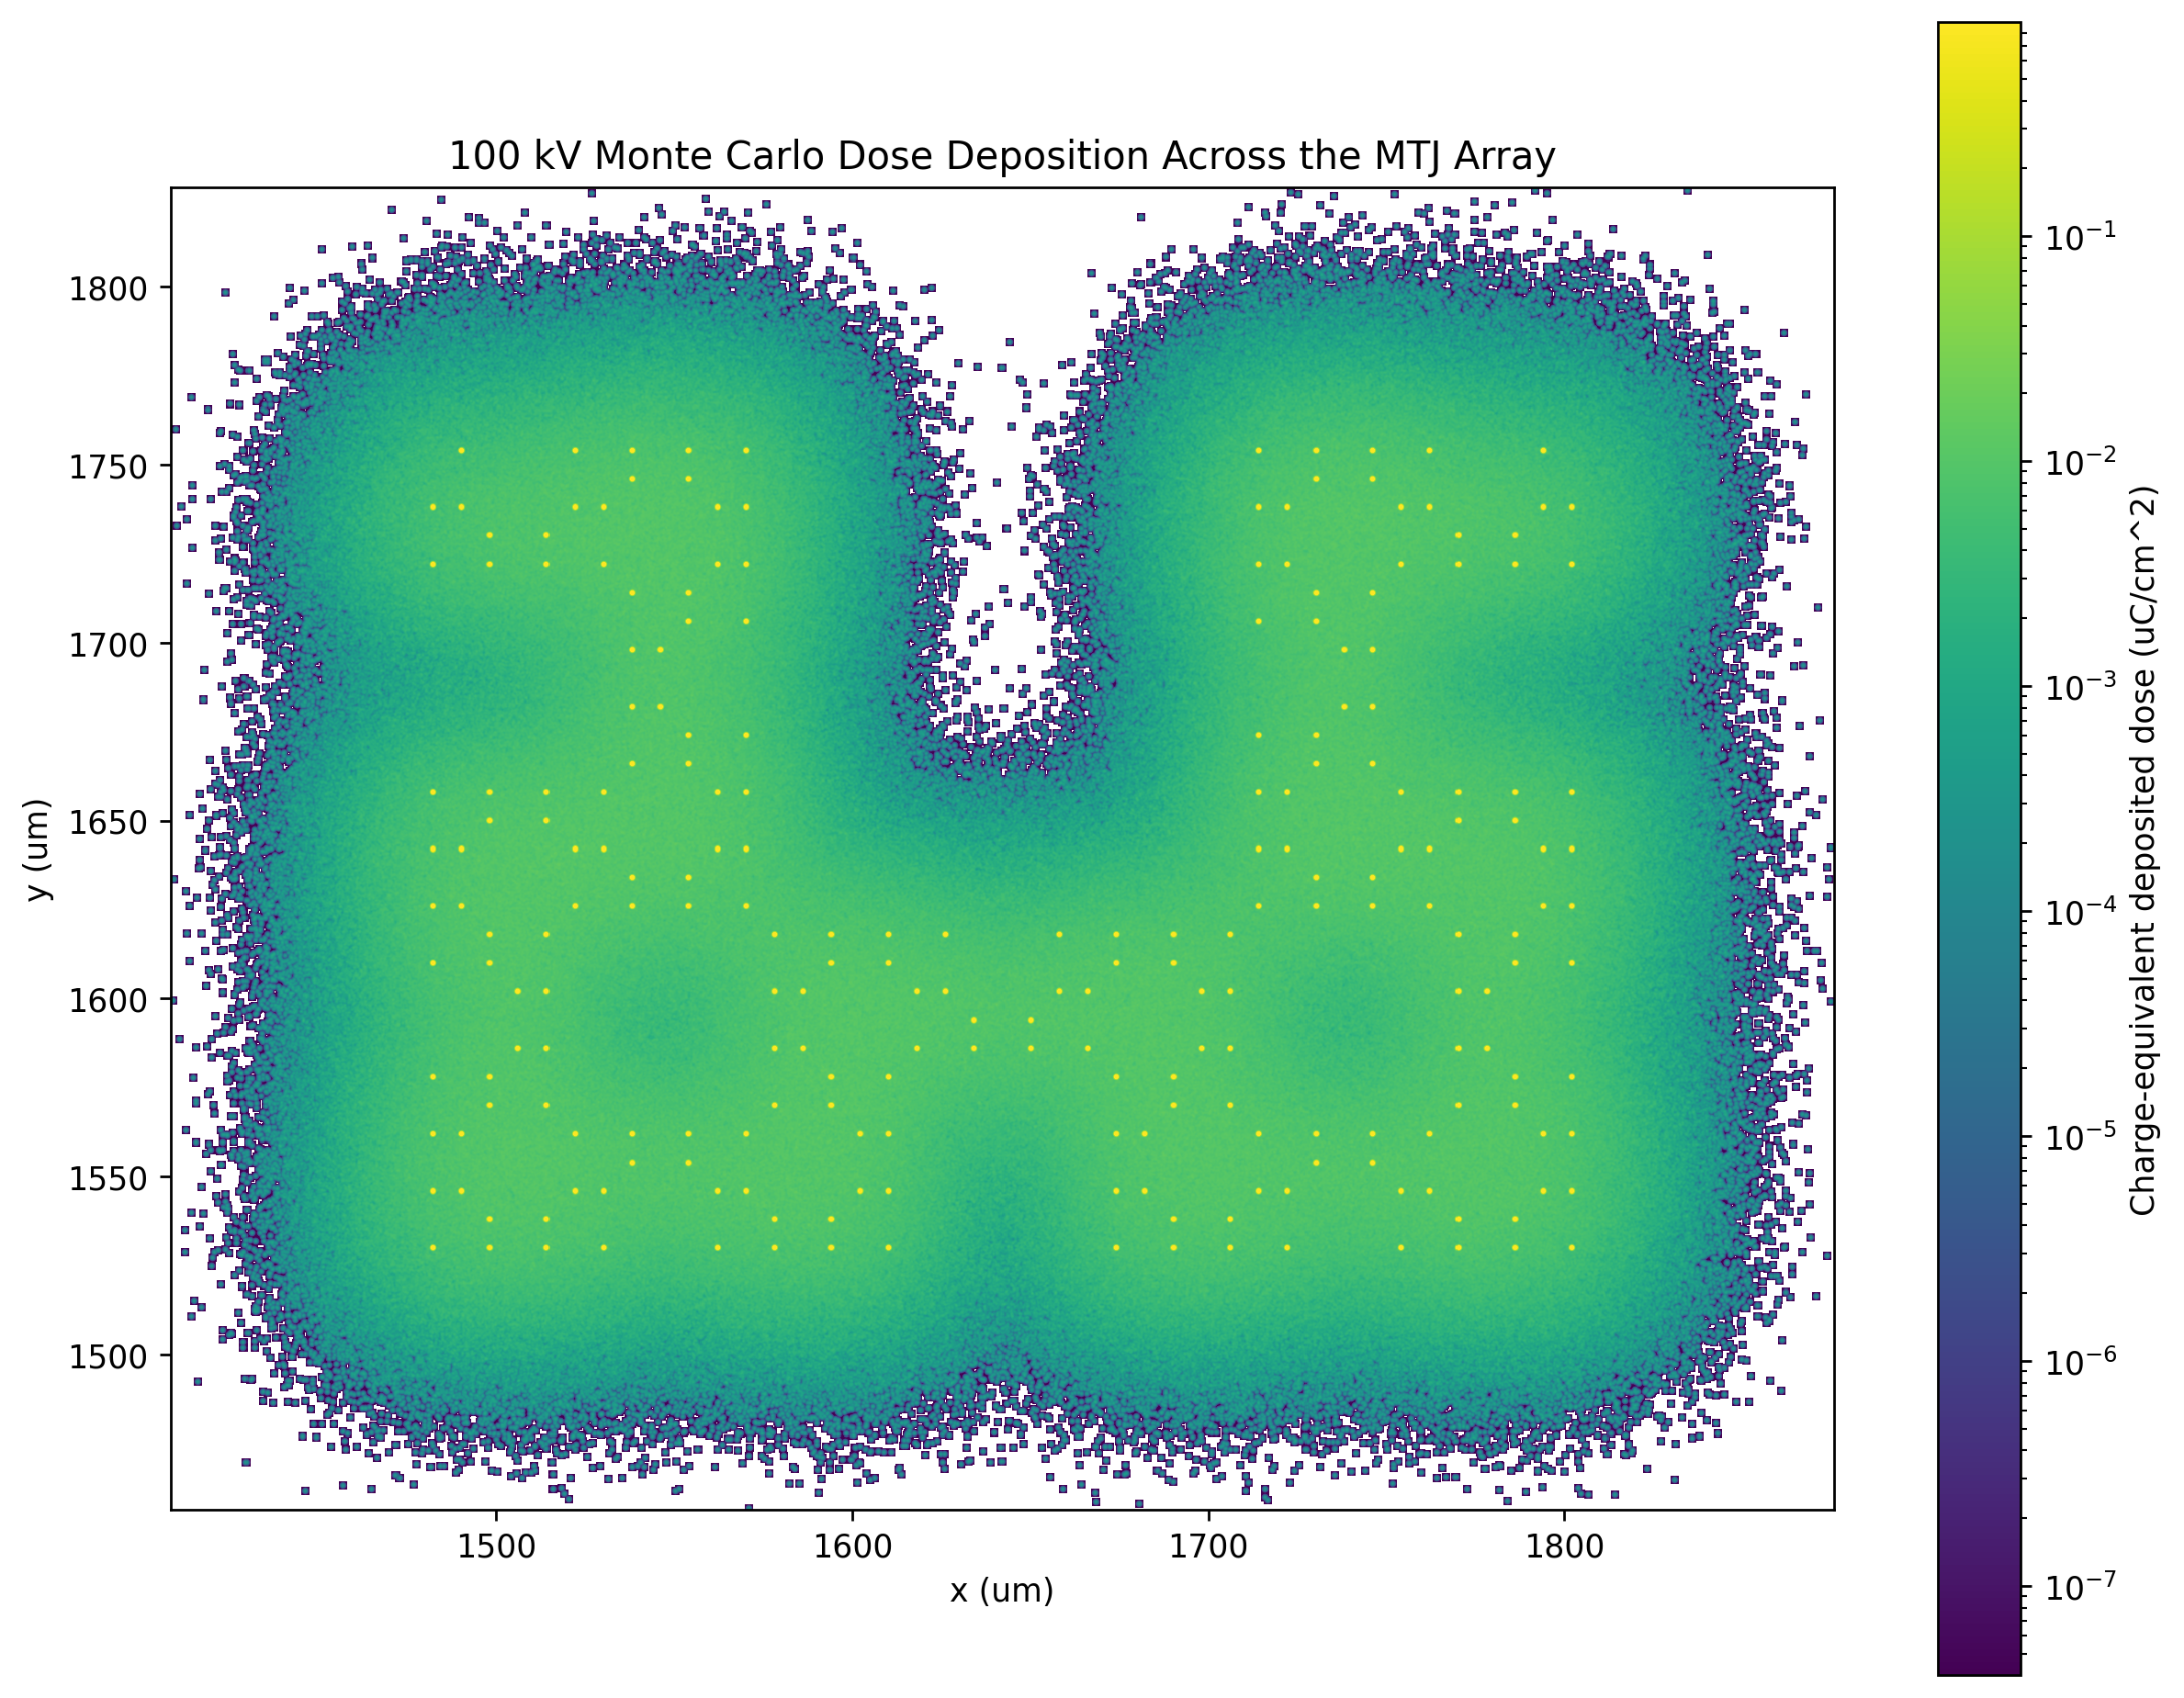

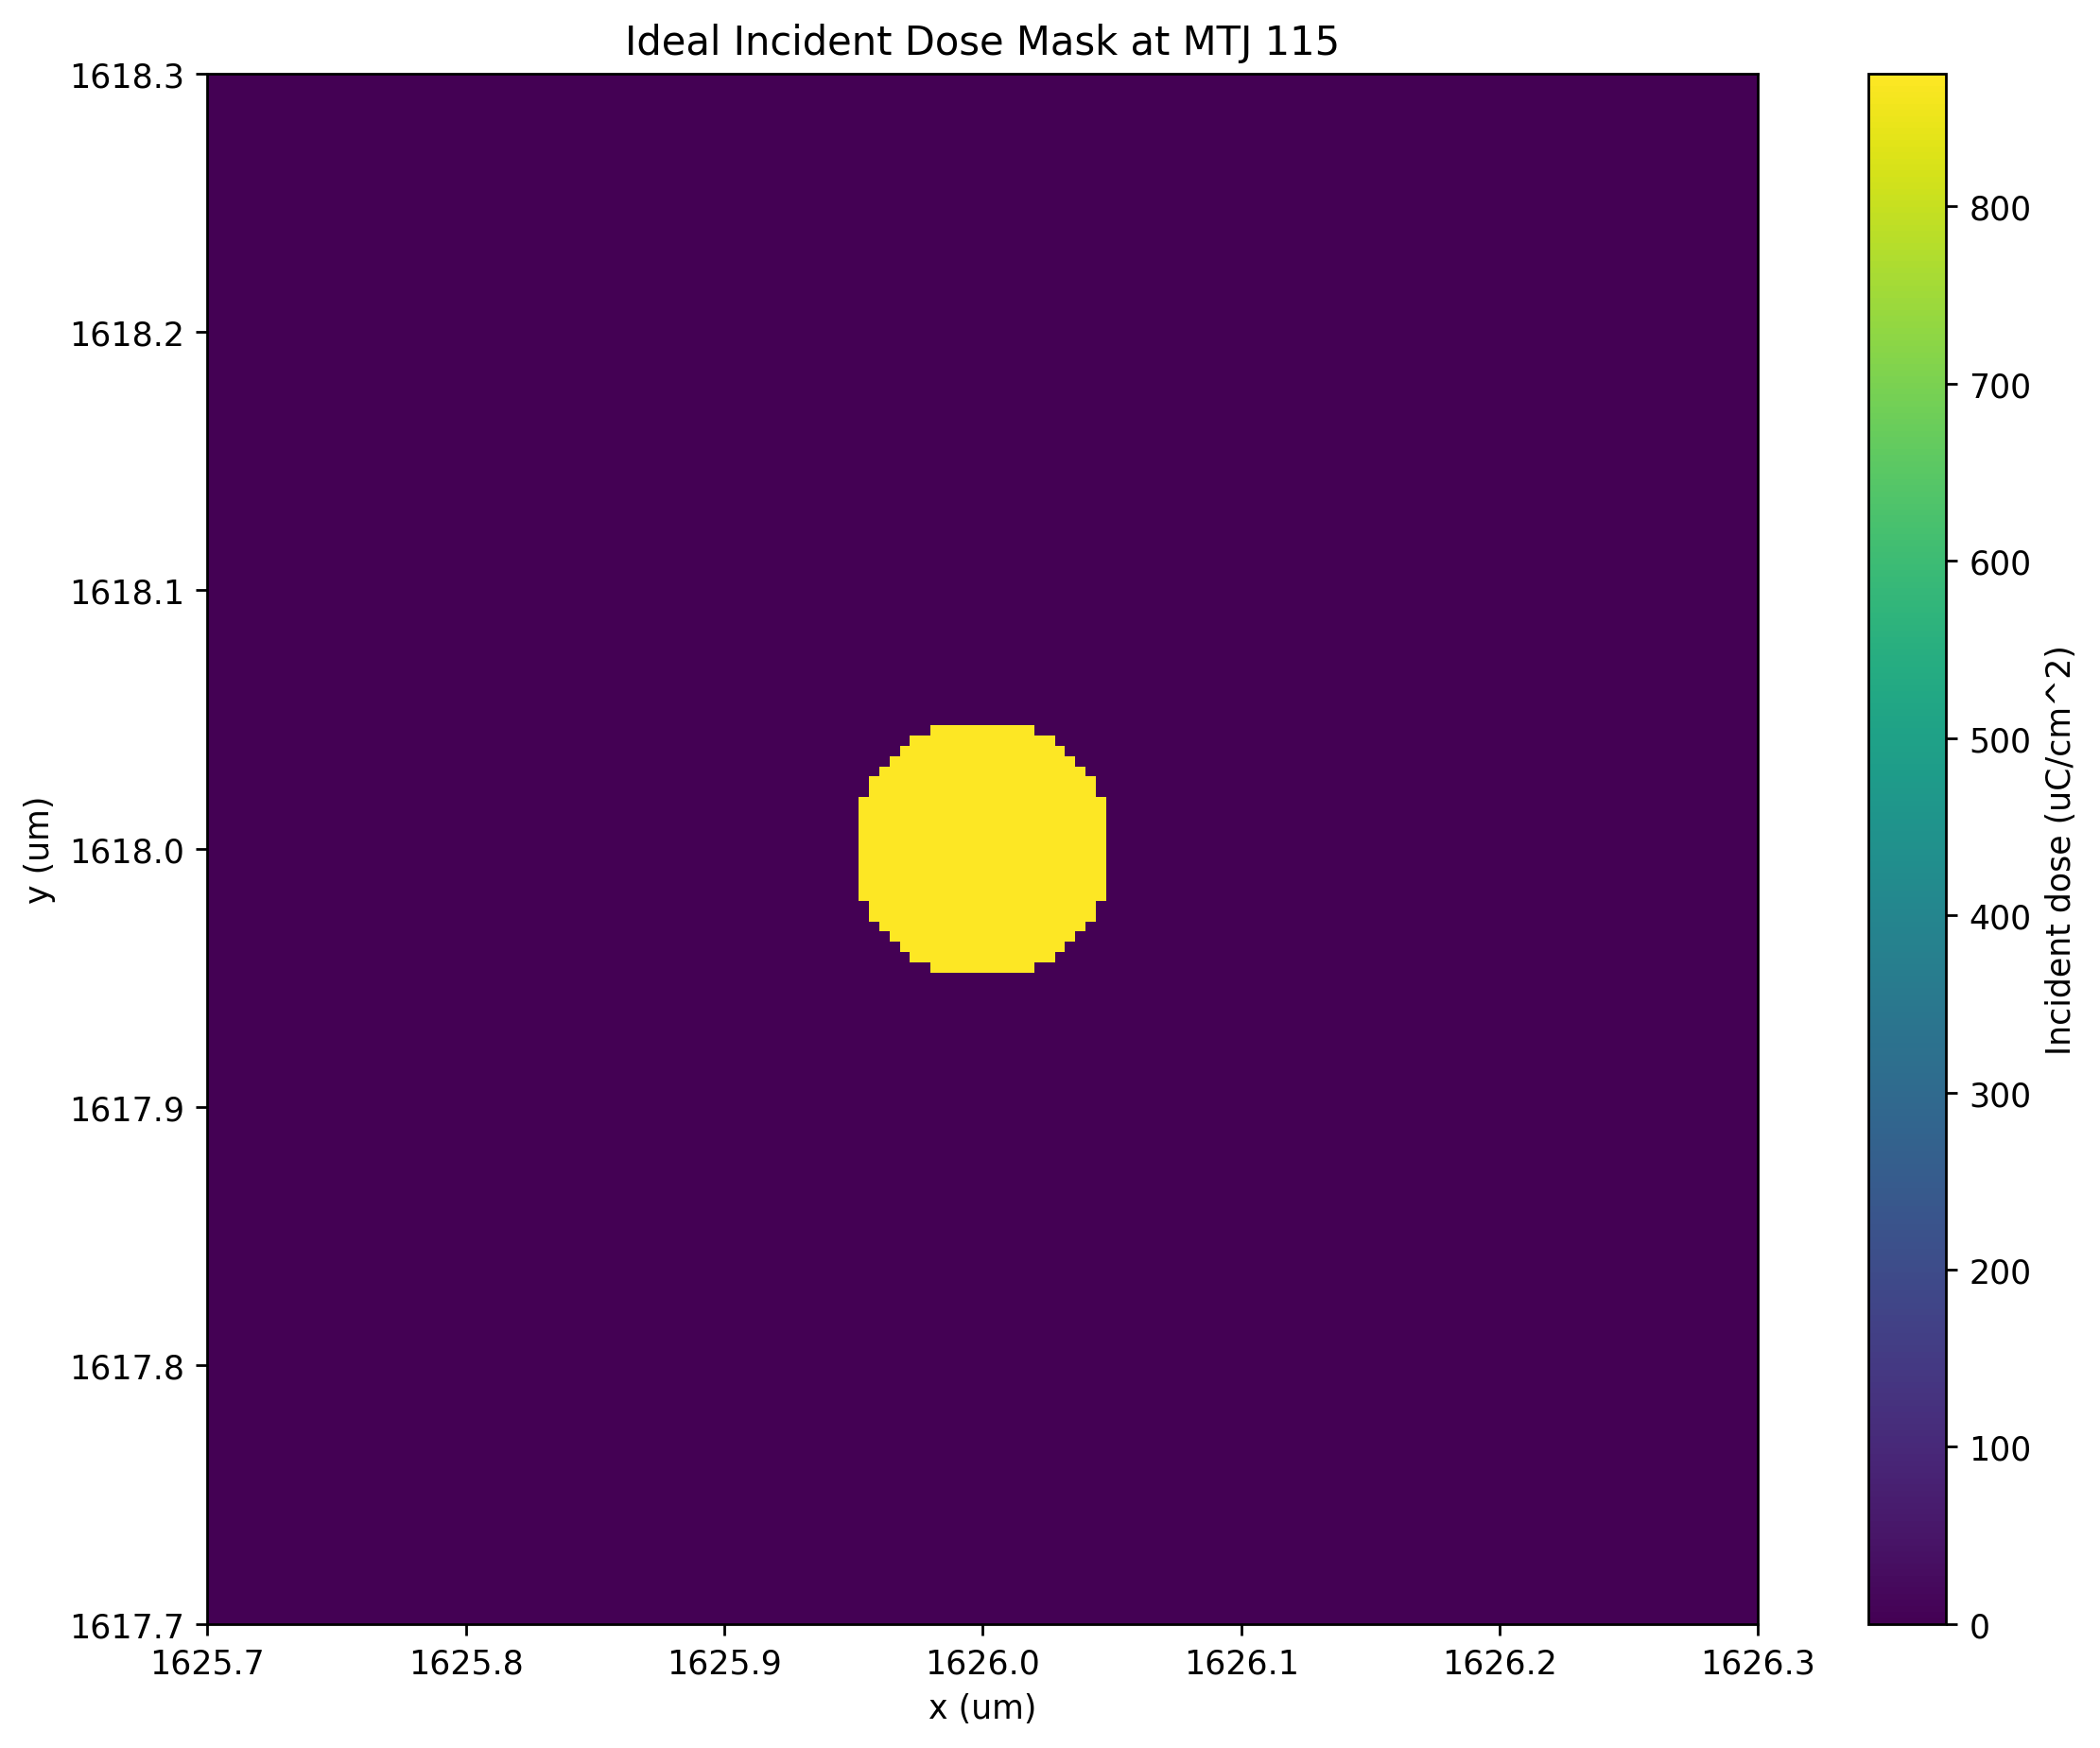

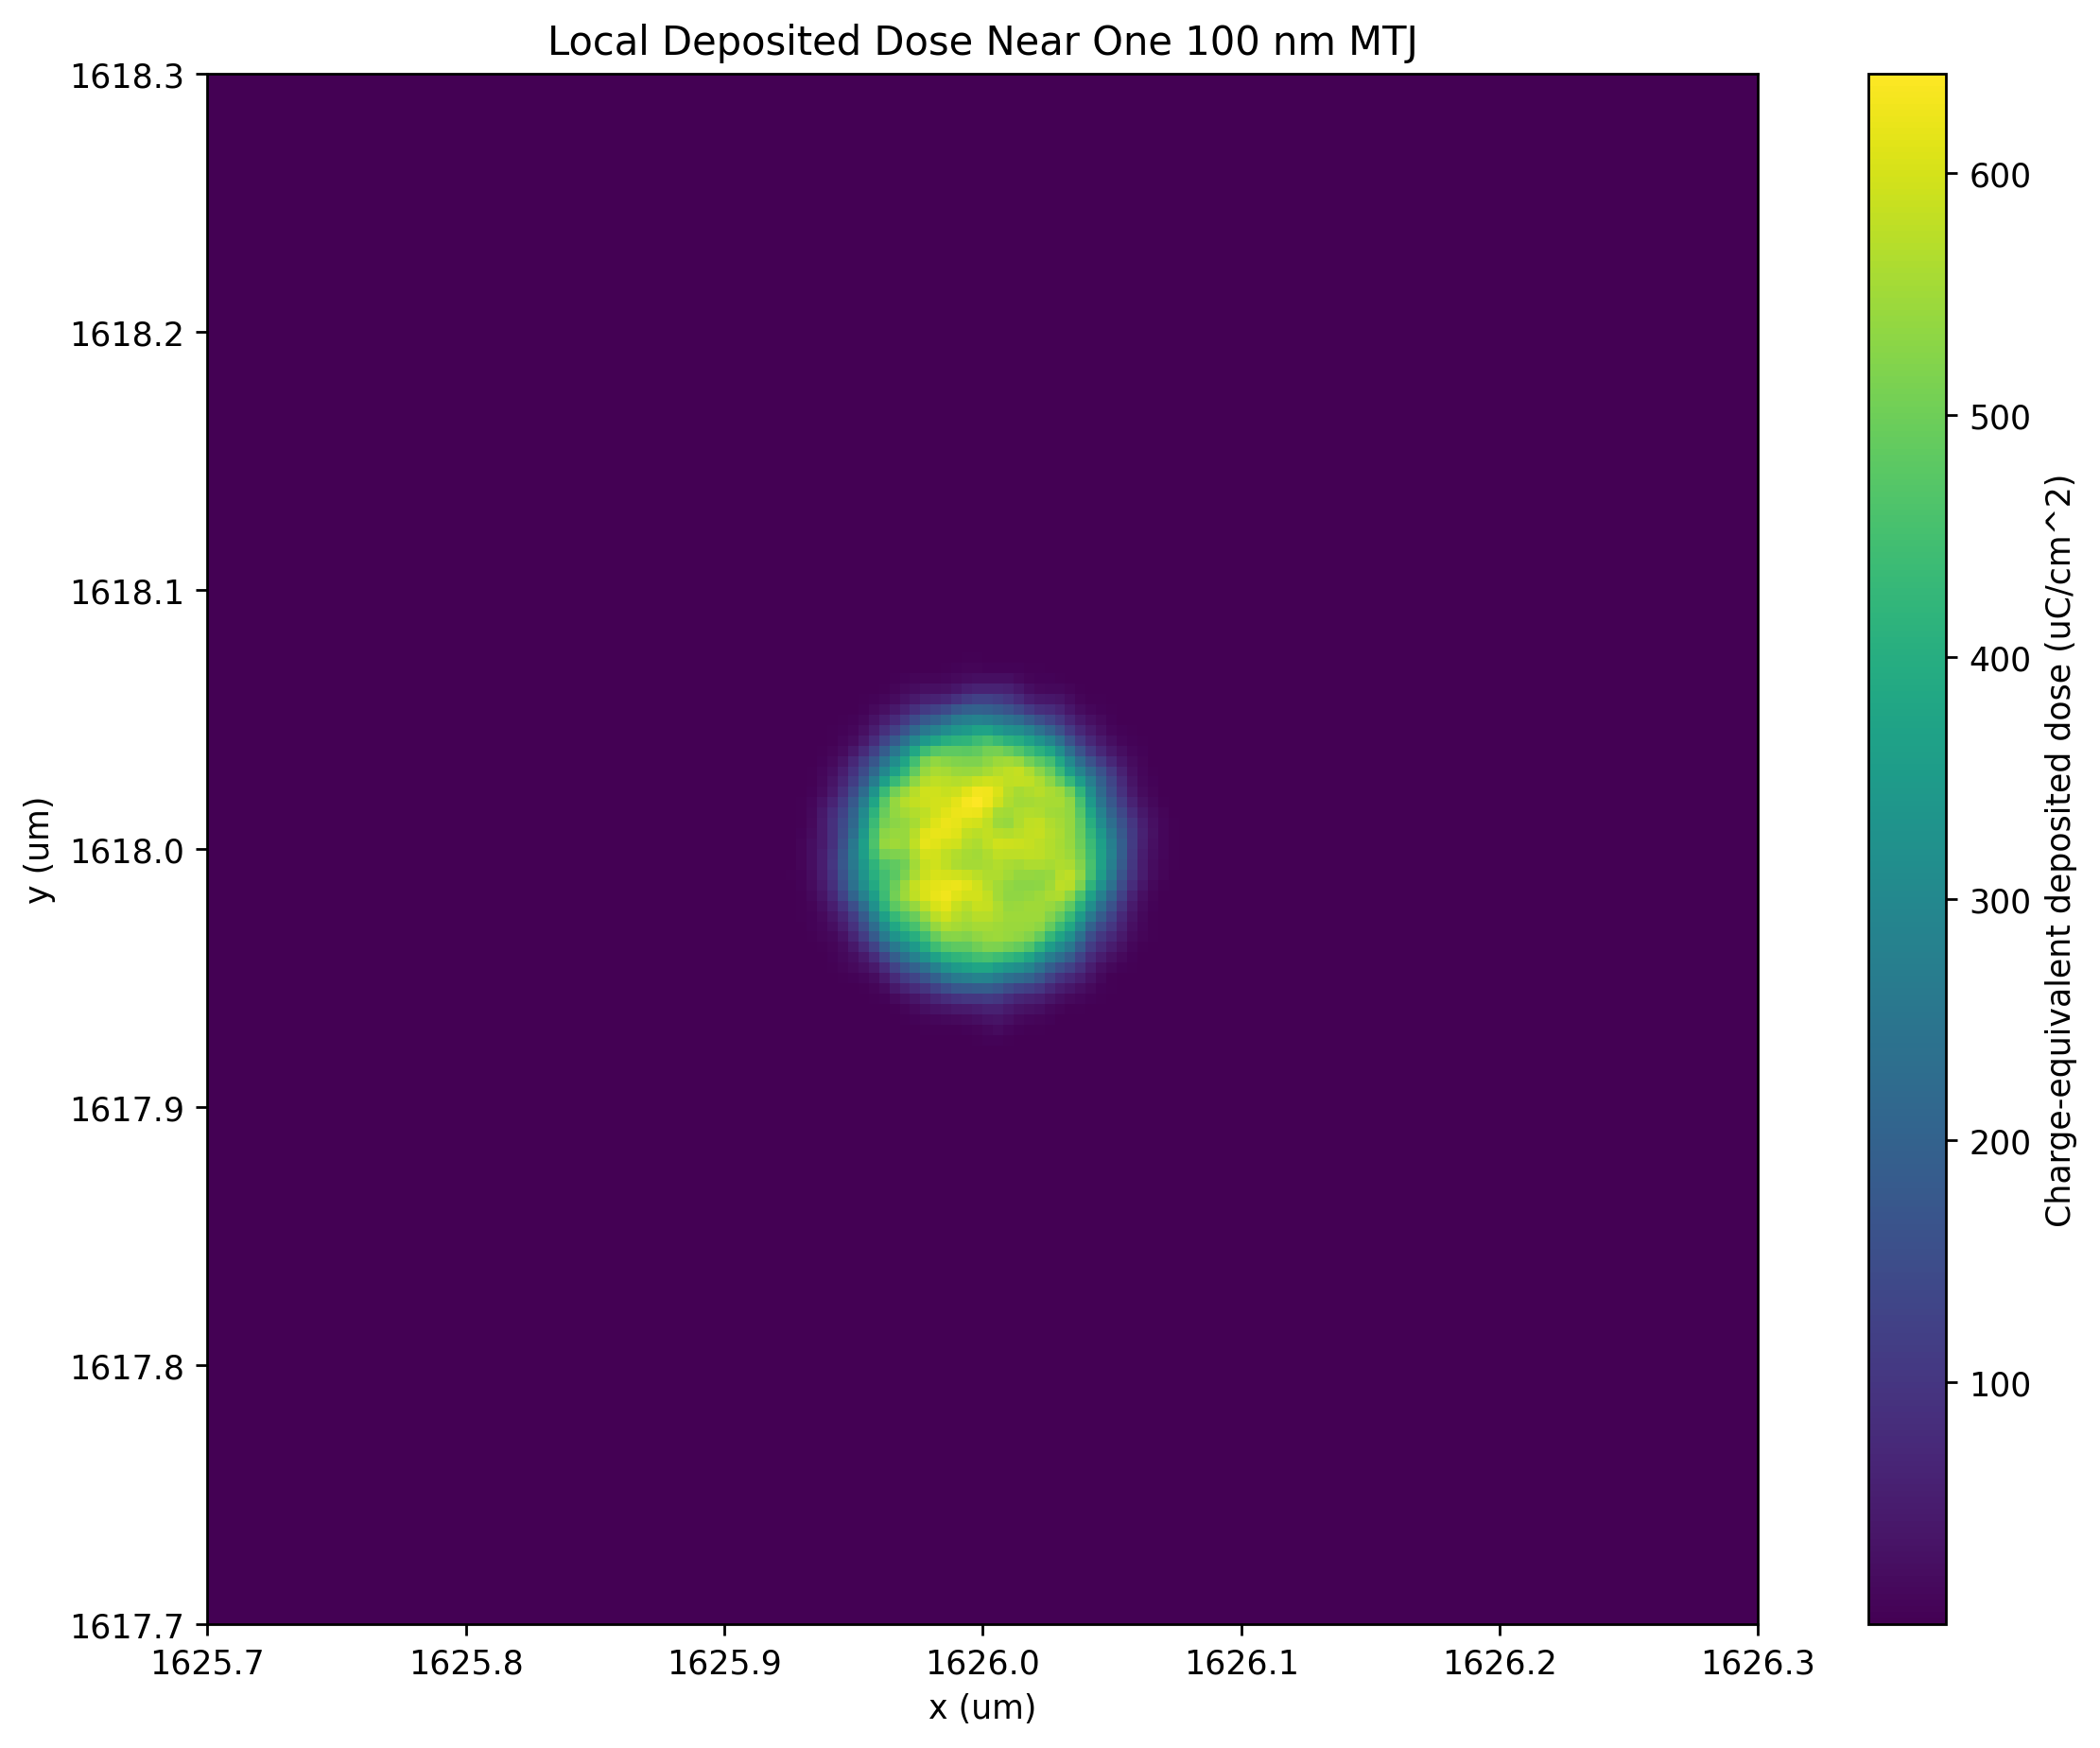

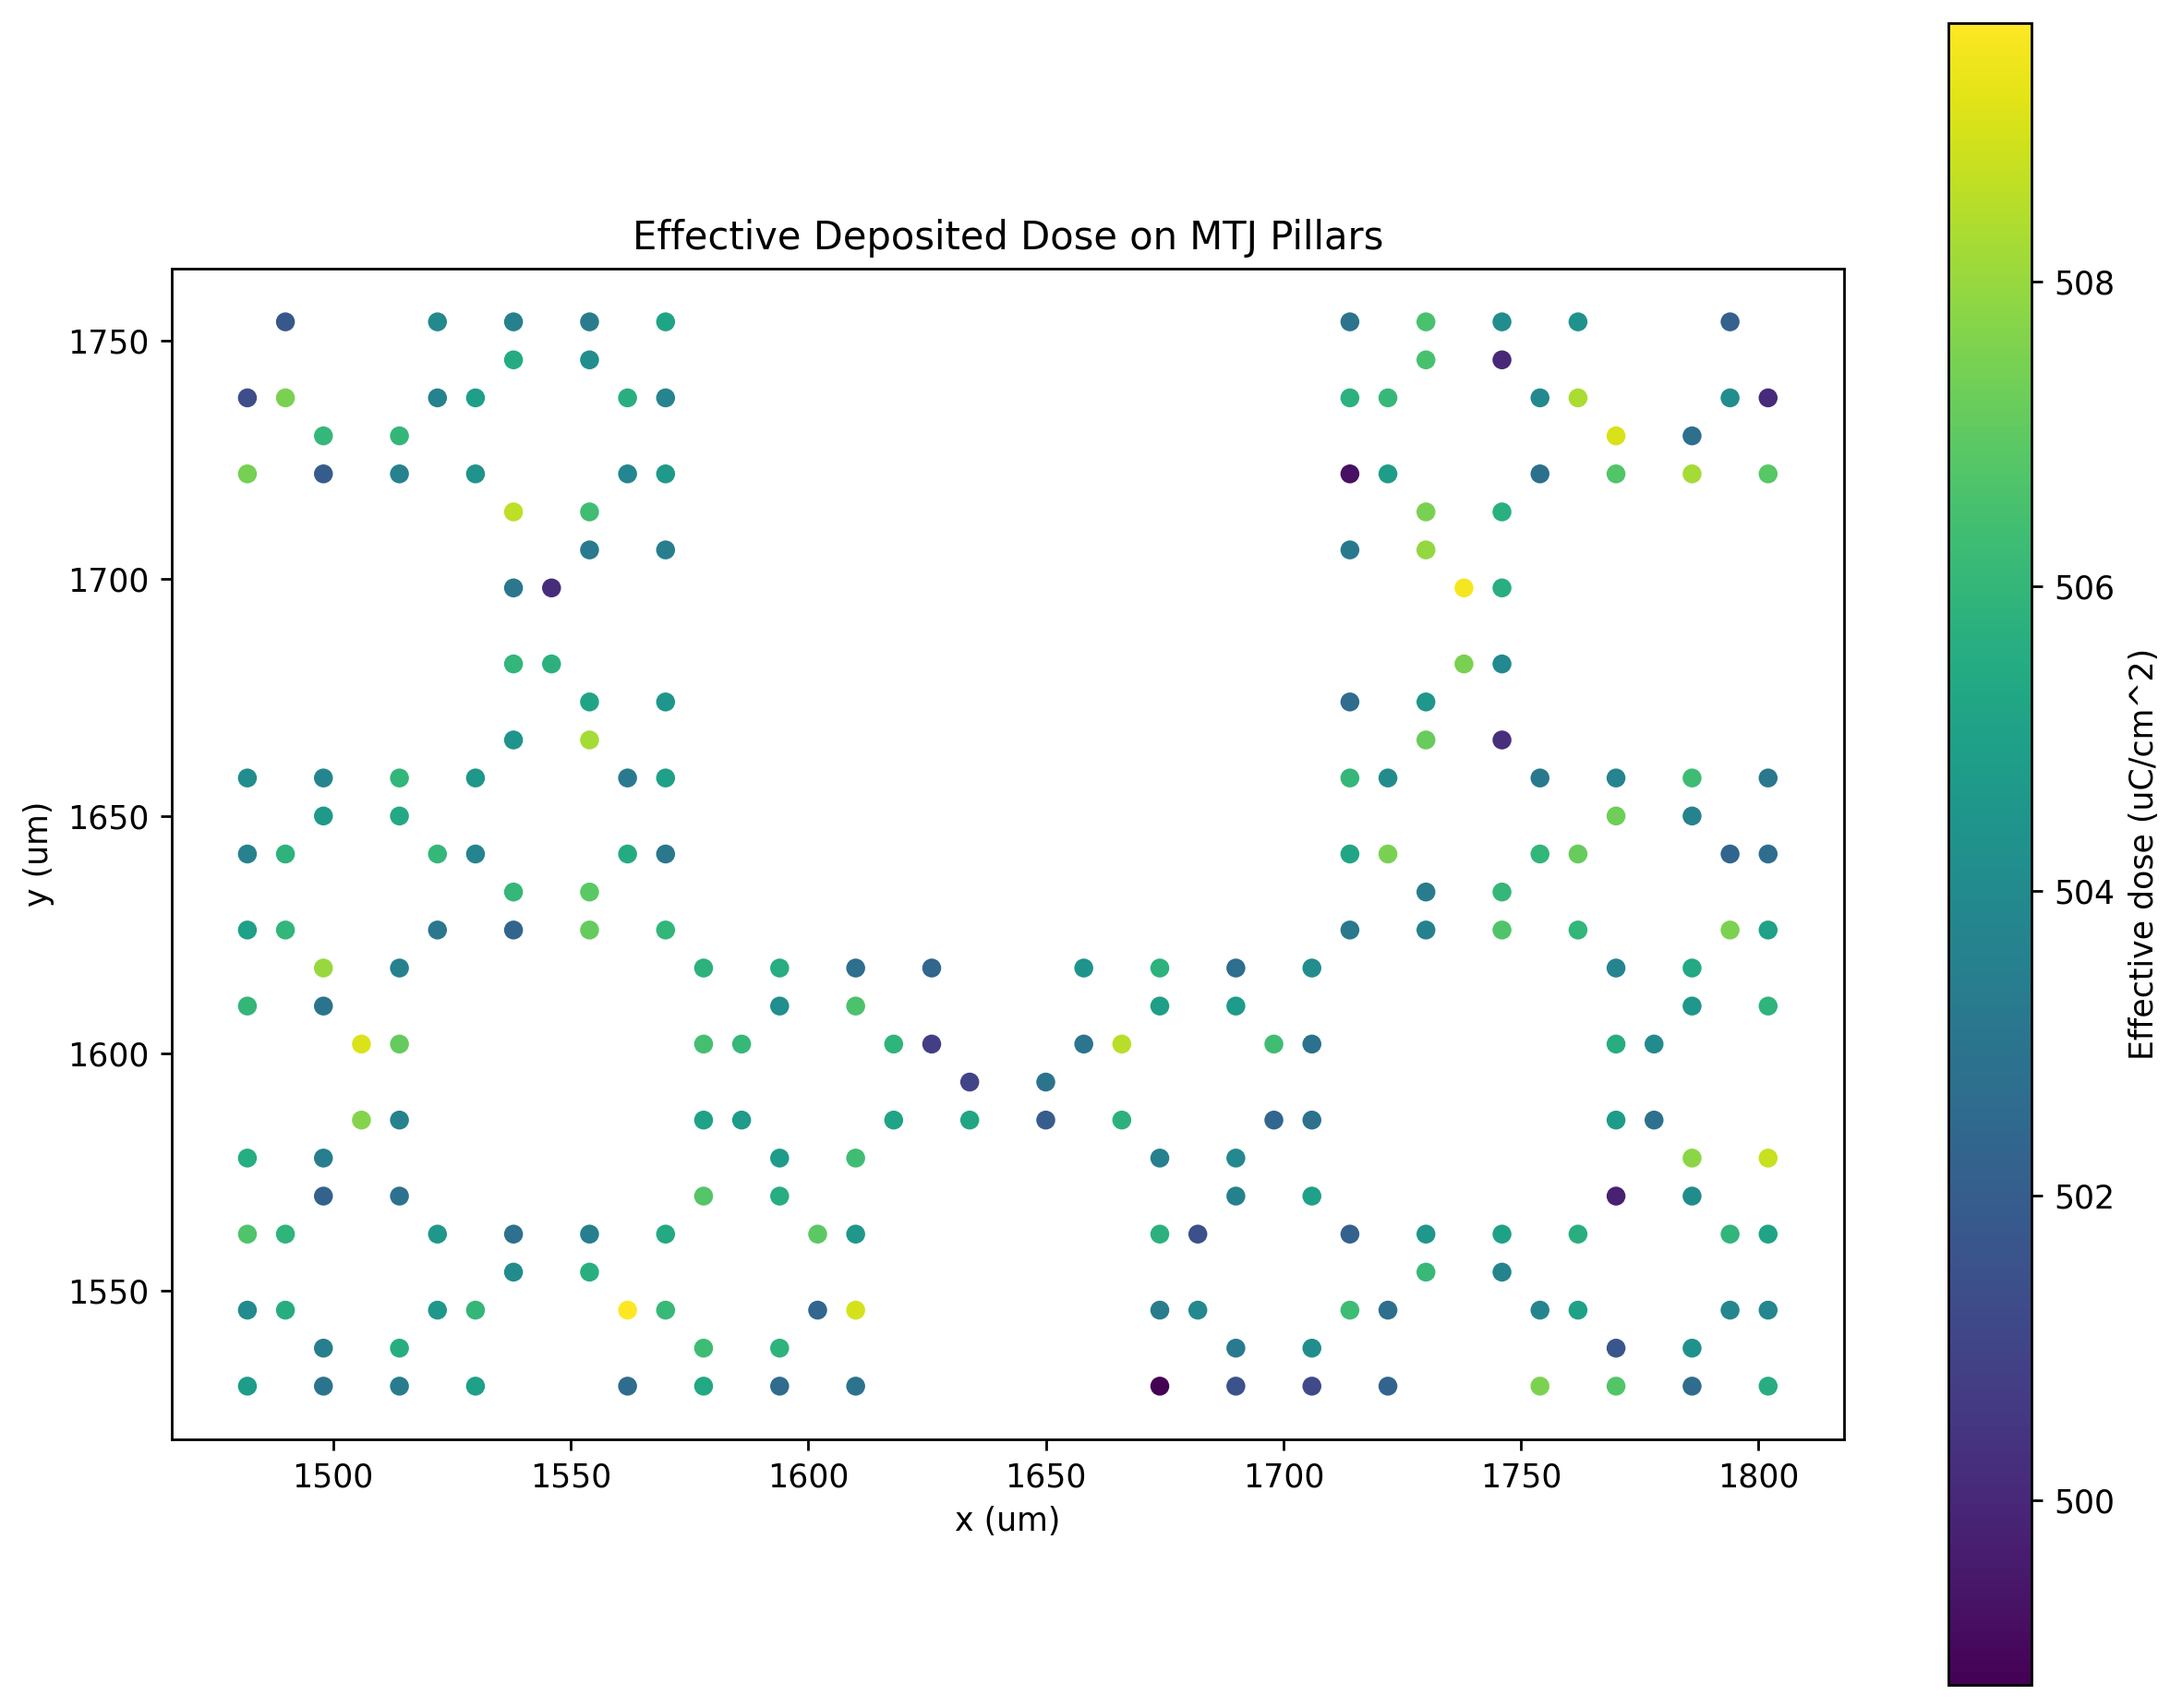

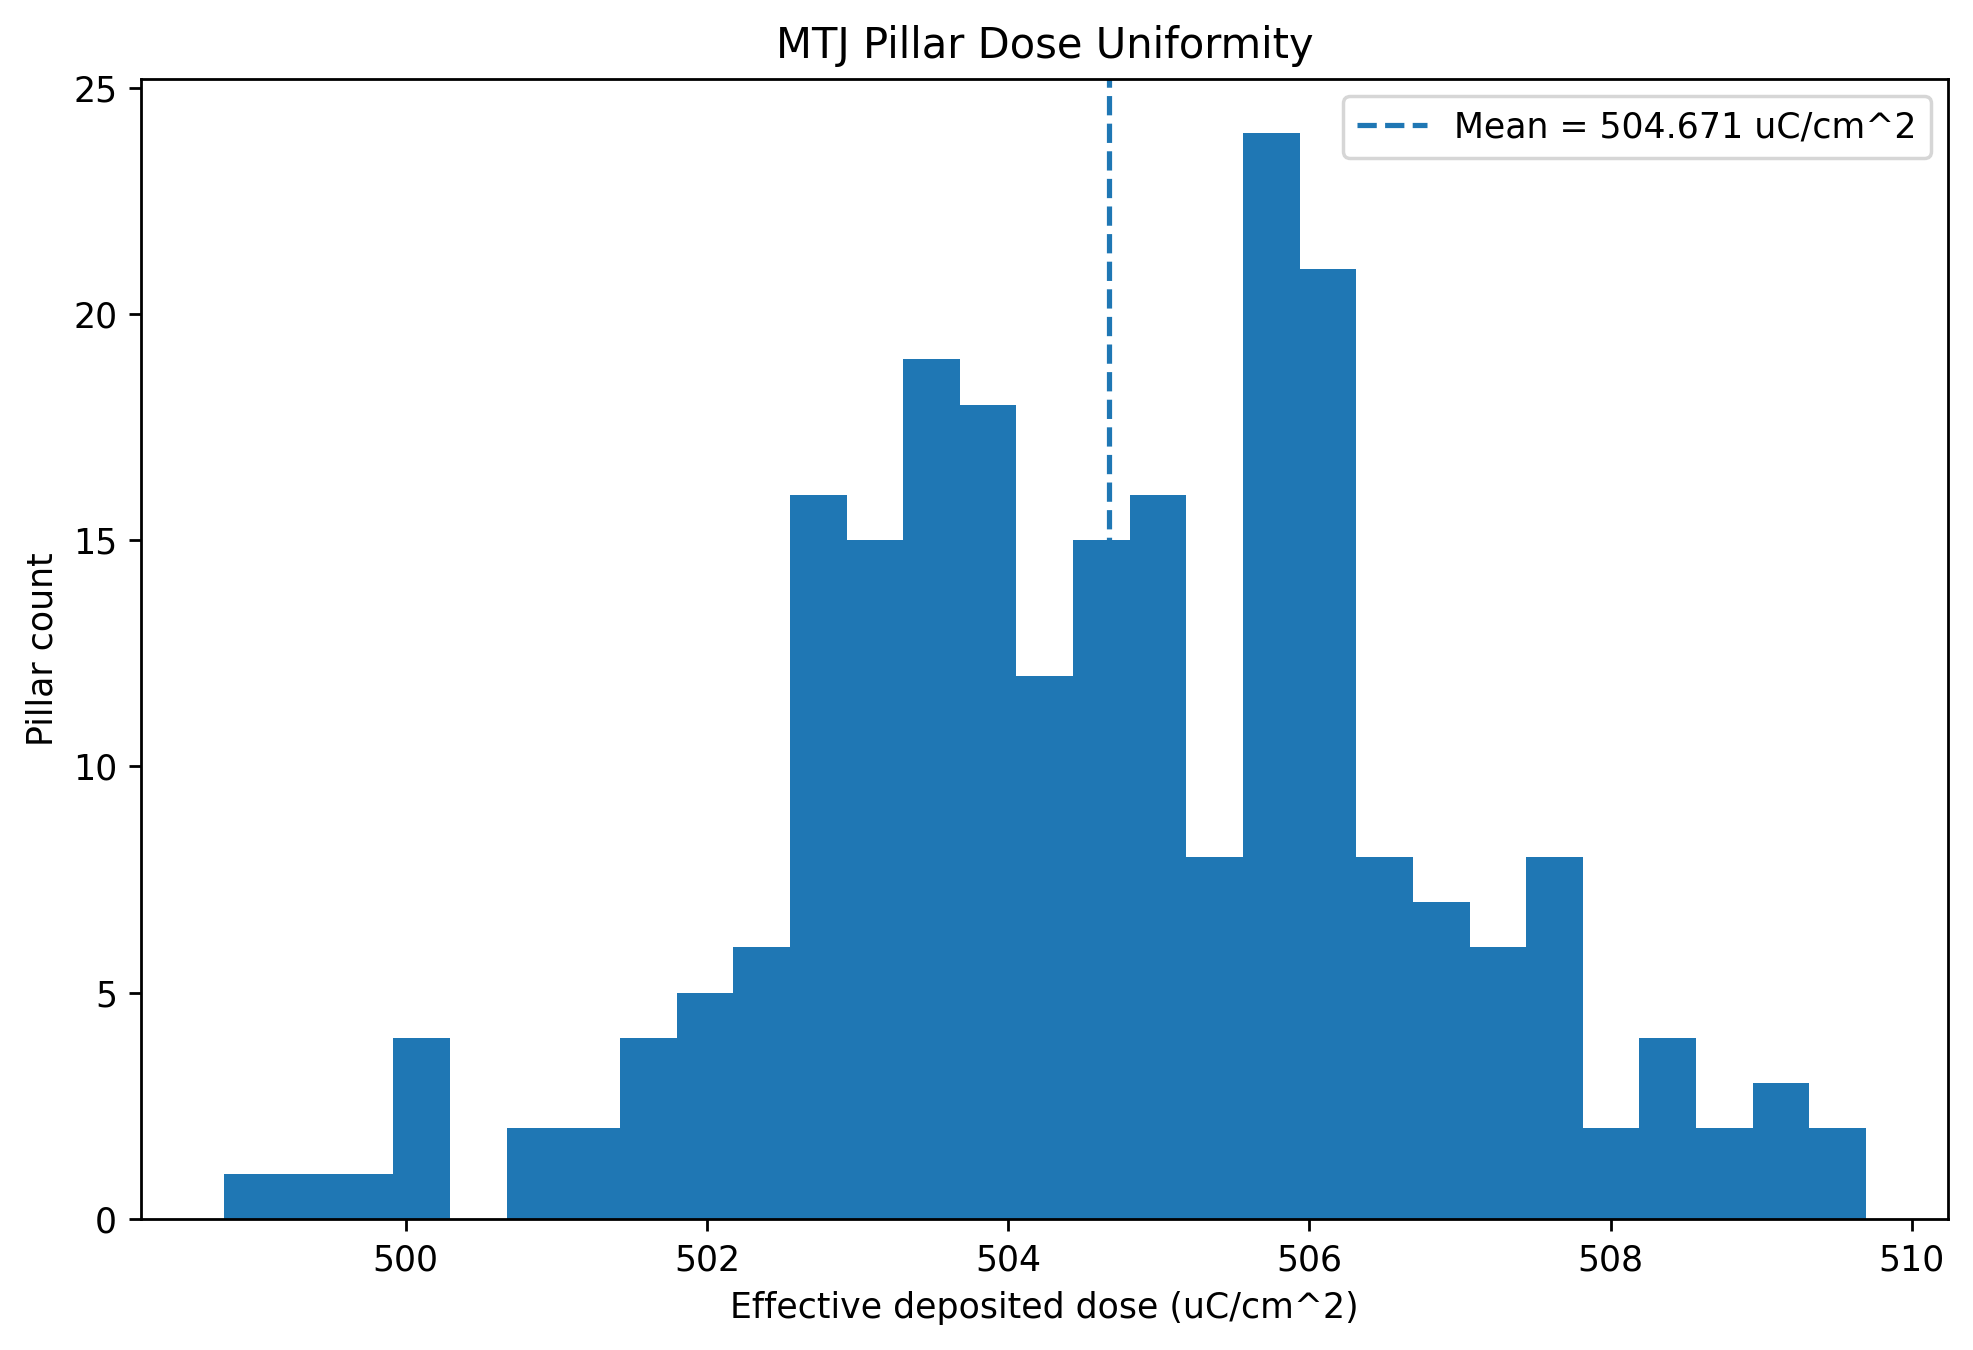

In [8]:
"""GPU Monte Carlo dose-deposition add-on for the Fibonacci MTJ layout.

Run the existing Fibonacci MTJ layout cell first. This add-on reads
``generate_crossbar_geometry()``, ``PILLAR_DIAMETER_NM``, and the XY-array
controls already defined by that cell.

The model interprets 875 as an electron-beam lithography area dose in
microcoulombs per square centimeter. Incident coordinates are restricted to
the circular MTJ pillar masks. A normalized two-component point-spread
surrogate samples short-range forward scattering and long-range substrate
backscatter on a CUDA GPU with CuPy.

This is a calibrated-surrogate workflow, not a material-resolved Mott/Bethe
electron-trajectory solver. Replace the PSF controls with measured, CASINO,
PENELOPE, Geant4, or process-correction data for the actual resist, MTJ stack,
oxide, and substrate.
"""


from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import cupy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cupyx.scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm

###############################################################################
# Control knobs
###############################################################################

ACCELERATION_VOLTAGE_KV = 100.0
AREA_DOSE_UC_CM2 = 875.0
BEAM_CURRENT_PA = 100.0

# None inherits the value from the Fibonacci MTJ layout cell.
PILLAR_DIAMETER_OVERRIDE_NM: float | None = None
MANUAL_PILLAR_CENTERS_UM: np.ndarray | None = None

# GPU Monte Carlo resolution.
PACKETS_PER_PILLAR = 50_000
EVENT_CHUNK_SIZE = 1_000_000
RANDOM_SEED = 20260713

# Two-component 100 kV EBL point-spread surrogate. Calibrate these values
# against your resist thickness, substrate, and measured or simulated PSF.
FORWARD_1E_RADIUS_NM = 12.0
BACKSCATTER_1E_RADIUS_UM = 26.0
BACKSCATTER_TO_FORWARD_RATIO = 0.50

# Array-scale and local-detail grids.
GLOBAL_PADDING_SIGMA = 4.0
GLOBAL_MIN_PIXEL_NM = 100.0
GLOBAL_MAX_AXIS_PIXELS = 1800
GLOBAL_SMOOTHING_SIGMA_PIXELS = 1.0

LOCAL_HALF_WIDTH_NM = 300.0
LOCAL_PIXEL_NM = 4.0
LOCAL_SMOOTHING_SIGMA_NM = 4.0
DETAIL_PILLAR_INDEX: int | None = None

FIGURE_DPI = 250
mpl.rcParams["figure.dpi"] = FIGURE_DPI


@dataclass(frozen=True)
class Grid:
    """Uniform square-pixel grid in micrometers."""

    xmin_um: float
    ymin_um: float
    pixel_um: float
    nx: int
    ny: int

    @property
    def xmax_um(self) -> float:
        """Return the upper x edge."""
        return self.xmin_um + self.nx * self.pixel_um

    @property
    def ymax_um(self) -> float:
        """Return the upper y edge."""
        return self.ymin_um + self.ny * self.pixel_um

    @property
    def extent(self) -> tuple[float, float, float, float]:
        """Return the Matplotlib extent."""
        return self.xmin_um, self.xmax_um, self.ymin_um, self.ymax_um

    @property
    def pixel_area_cm2(self) -> float:
        """Return one pixel area in square centimeters."""
        return (self.pixel_um * 1.0e-4) ** 2


def validate_controls() -> None:
    """Validate the principal numerical controls."""
    positive_values = {
        "ACCELERATION_VOLTAGE_KV": ACCELERATION_VOLTAGE_KV,
        "AREA_DOSE_UC_CM2": AREA_DOSE_UC_CM2,
        "BEAM_CURRENT_PA": BEAM_CURRENT_PA,
        "PACKETS_PER_PILLAR": PACKETS_PER_PILLAR,
        "EVENT_CHUNK_SIZE": EVENT_CHUNK_SIZE,
        "FORWARD_1E_RADIUS_NM": FORWARD_1E_RADIUS_NM,
        "BACKSCATTER_1E_RADIUS_UM": BACKSCATTER_1E_RADIUS_UM,
        "GLOBAL_MIN_PIXEL_NM": GLOBAL_MIN_PIXEL_NM,
        "GLOBAL_MAX_AXIS_PIXELS": GLOBAL_MAX_AXIS_PIXELS,
        "LOCAL_HALF_WIDTH_NM": LOCAL_HALF_WIDTH_NM,
        "LOCAL_PIXEL_NM": LOCAL_PIXEL_NM,
    }
    invalid = [name for name, value in positive_values.items() if value <= 0]
    if invalid:
        raise ValueError(f"These controls must be positive: {invalid}")
    if BACKSCATTER_TO_FORWARD_RATIO < 0.0:
        raise ValueError("BACKSCATTER_TO_FORWARD_RATIO must be nonnegative.")
    if PACKETS_PER_PILLAR < 1_000:
        raise ValueError("Use at least 1,000 packets per pillar.")


def get_gpu_name() -> str:
    """Return the active CUDA device name."""
    if cp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError("CuPy cannot see a CUDA GPU.")
    name = cp.cuda.runtime.getDeviceProperties(0)["name"]
    return name.decode() if isinstance(name, bytes) else str(name)


def load_pillar_centers() -> tuple[np.ndarray, float]:
    """Load the MTJ centers from the preceding layout cell."""
    namespace = globals()

    if MANUAL_PILLAR_CENTERS_UM is not None:
        centers_um = np.asarray(MANUAL_PILLAR_CENTERS_UM, dtype=float)
    else:
        generator = namespace.get("generate_crossbar_geometry")
        if generator is None:
            raise RuntimeError(
                "Run the Fibonacci MTJ layout cell first, or define "
                "MANUAL_PILLAR_CENTERS_UM."
            )
        geometry = generator()
        unit_centers_um = np.asarray(geometry.pillar_centers, dtype=float)

        array_size_x = int(namespace.get("ARRAY_SIZE_X", 1))
        array_size_y = int(namespace.get("ARRAY_SIZE_Y", 1))
        pitch_x_um = float(geometry.bounds.width) + float(
            namespace.get("ARRAY_CELL_EDGE_GAP_X_UM", 0.0)
        )
        pitch_y_um = float(geometry.bounds.height) + float(
            namespace.get("ARRAY_CELL_EDGE_GAP_Y_UM", 0.0)
        )

        centers = []
        for row_index in range(array_size_y):
            for column_index in range(array_size_x):
                centers.append(
                    unit_centers_um
                    + np.array(
                        [
                            column_index * pitch_x_um,
                            row_index * pitch_y_um,
                        ]
                    )
                )
        centers_um = np.vstack(centers)

    centers_um = np.round(np.asarray(centers_um, dtype=float), decimals=9)
    if centers_um.ndim != 2 or centers_um.shape[1] != 2:
        raise ValueError("Pillar centers must have shape (N, 2).")
    if np.unique(centers_um, axis=0).shape[0] != centers_um.shape[0]:
        raise ValueError("Duplicate pillar centers were detected.")

    diameter_nm = (
        float(globals().get("PILLAR_DIAMETER_NM", 100.0))
        if PILLAR_DIAMETER_OVERRIDE_NM is None
        else float(PILLAR_DIAMETER_OVERRIDE_NM)
    )
    return centers_um, diameter_nm


def make_global_grid(
    centers_um: np.ndarray,
    backscatter_sigma_um: float,
) -> Grid:
    """Create an array-scale grid with Gaussian-tail padding."""
    padding_um = GLOBAL_PADDING_SIGMA * backscatter_sigma_um
    xmin_um = float(np.min(centers_um[:, 0]) - padding_um)
    xmax_um = float(np.max(centers_um[:, 0]) + padding_um)
    ymin_um = float(np.min(centers_um[:, 1]) - padding_um)
    ymax_um = float(np.max(centers_um[:, 1]) + padding_um)

    width_um = xmax_um - xmin_um
    height_um = ymax_um - ymin_um
    pixel_um = max(
        GLOBAL_MIN_PIXEL_NM * 1.0e-3,
        width_um / GLOBAL_MAX_AXIS_PIXELS,
        height_um / GLOBAL_MAX_AXIS_PIXELS,
    )
    return Grid(
        xmin_um=xmin_um,
        ymin_um=ymin_um,
        pixel_um=pixel_um,
        nx=int(np.ceil(width_um / pixel_um)),
        ny=int(np.ceil(height_um / pixel_um)),
    )


def make_local_grid(center_um: np.ndarray) -> Grid:
    """Create a high-resolution grid around one representative pillar."""
    half_width_um = LOCAL_HALF_WIDTH_NM * 1.0e-3
    pixel_um = LOCAL_PIXEL_NM * 1.0e-3
    axis_pixels = int(np.ceil(2.0 * half_width_um / pixel_um))
    return Grid(
        xmin_um=float(center_um[0] - half_width_um),
        ymin_um=float(center_um[1] - half_width_um),
        pixel_um=pixel_um,
        nx=axis_pixels,
        ny=axis_pixels,
    )


def select_detail_pillar(centers_um: np.ndarray) -> int:
    """Select the requested pillar or the pillar nearest the centroid."""
    if DETAIL_PILLAR_INDEX is not None:
        if not 0 <= DETAIL_PILLAR_INDEX < centers_um.shape[0]:
            raise ValueError("DETAIL_PILLAR_INDEX is outside the pillar list.")
        return int(DETAIL_PILLAR_INDEX)

    centroid_um = np.mean(centers_um, axis=0)
    return int(np.argmin(np.sum((centers_um - centroid_um) ** 2, axis=1)))


def build_lookup(
    centers_um: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build a sparse row-column lookup for active pillars."""
    x_axis_um, x_indices = np.unique(
        centers_um[:, 0],
        return_inverse=True,
    )
    y_axis_um, y_indices = np.unique(
        centers_um[:, 1],
        return_inverse=True,
    )
    lookup = np.full((y_axis_um.size, x_axis_um.size), -1, dtype=np.int32)
    for pillar_id, (x_index, y_index) in enumerate(
        zip(x_indices, y_indices, strict=True)
    ):
        lookup[y_index, x_index] = pillar_id
    return x_axis_um, y_axis_um, lookup


def nearest_indices(
    values: cp.ndarray,
    sorted_axis: cp.ndarray,
) -> cp.ndarray:
    """Return the nearest coordinate index on a sorted axis."""
    right = cp.clip(
        cp.searchsorted(sorted_axis, values, side="left"),
        0,
        sorted_axis.size - 1,
    )
    left = cp.clip(right - 1, 0, sorted_axis.size - 1)
    choose_left = (
        cp.abs(values - sorted_axis[left])
        <= cp.abs(values - sorted_axis[right])
    )
    return cp.where(choose_left, left, right)


def assign_pillar_hits(
    x_um: cp.ndarray,
    y_um: cp.ndarray,
    x_axis_um: cp.ndarray,
    y_axis_um: cp.ndarray,
    lookup: cp.ndarray,
    radius_um: float,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Assign deposition points that lie inside active MTJ disks."""
    x_index = nearest_indices(x_um, x_axis_um)
    y_index = nearest_indices(y_um, y_axis_um)
    target_id = lookup[y_index, x_index]
    distance_squared_um2 = (
        (x_um - x_axis_um[x_index]) ** 2
        + (y_um - y_axis_um[y_index]) ** 2
    )
    inside = (target_id >= 0) & (distance_squared_um2 <= radius_um**2)
    return target_id, inside


def accumulate_index_counts(
    destination: cp.ndarray,
    indices: cp.ndarray,
) -> None:
    """Accumulate nonnegative integer indices without empty-array failures.

    CuPy's ``bincount`` can raise a CUB reduction error when its input has
    zero elements. Empty event selections are expected for local windows and
    sparse pillar masks, so they are treated as a valid no-op.

    Args:
        destination: One-dimensional array receiving the accumulated counts.
        indices: One-dimensional array of nonnegative destination indices.
    """
    if destination.ndim != 1:
        raise ValueError("destination must be one-dimensional.")
    if indices.ndim != 1:
        raise ValueError("indices must be one-dimensional.")
    if indices.size == 0:
        return

    counts = cp.bincount(
        indices.astype(cp.int64, copy=False),
        minlength=int(destination.size),
    )
    destination += counts.astype(destination.dtype, copy=False)


def histogram_points(
    histogram: cp.ndarray,
    x_um: cp.ndarray,
    y_um: cp.ndarray,
    grid: Grid,
) -> None:
    """Accumulate deposition points into a flattened GPU histogram."""
    if x_um.ndim != 1 or y_um.ndim != 1:
        raise ValueError("x_um and y_um must be one-dimensional.")
    if x_um.size != y_um.size:
        raise ValueError("x_um and y_um must contain the same number of points.")
    if x_um.size == 0:
        return

    x_index = cp.floor((x_um - grid.xmin_um) / grid.pixel_um).astype(
        cp.int64
    )
    y_index = cp.floor((y_um - grid.ymin_um) / grid.pixel_um).astype(
        cp.int64
    )
    inside = (
        (x_index >= 0)
        & (x_index < grid.nx)
        & (y_index >= 0)
        & (y_index < grid.ny)
    )
    flat_index = y_index[inside] * grid.nx + x_index[inside]
    accumulate_index_counts(histogram, flat_index)


def analytic_backscatter_at_pillars(
    centers_um: np.ndarray,
    charge_per_pillar_uc: float,
    backscatter_weight: float,
    sigma_um: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Evaluate the smooth long-range Gaussian dose at every pillar."""
    difference_um = centers_um[:, None, :] - centers_um[None, :, :]
    radius_squared_um2 = np.sum(difference_um**2, axis=2)
    density_um2 = np.exp(
        -radius_squared_um2 / (2.0 * sigma_um**2)
    ) / (2.0 * np.pi * sigma_um**2)
    total = (
        charge_per_pillar_uc
        * backscatter_weight
        * np.sum(density_um2, axis=1)
        * 1.0e8
    )
    self_term = (
        charge_per_pillar_uc
        * backscatter_weight
        * np.diag(density_um2)
        * 1.0e8
    )
    return total, self_term


def analytic_backscatter_map(
    centers_um: np.ndarray,
    grid: Grid,
    charge_per_pillar_uc: float,
    backscatter_weight: float,
    sigma_um: float,
) -> np.ndarray:
    """Evaluate the smooth long-range dose on the local detail grid."""
    x_um = grid.xmin_um + (np.arange(grid.nx) + 0.5) * grid.pixel_um
    y_um = grid.ymin_um + (np.arange(grid.ny) + 0.5) * grid.pixel_um
    x_mesh_um, y_mesh_um = np.meshgrid(x_um, y_um)
    density_um2 = np.zeros((grid.ny, grid.nx), dtype=float)

    normalization = 1.0 / (2.0 * np.pi * sigma_um**2)
    for center_x_um, center_y_um in centers_um:
        radius_squared_um2 = (
            (x_mesh_um - center_x_um) ** 2
            + (y_mesh_um - center_y_um) ** 2
        )
        density_um2 += normalization * np.exp(
            -radius_squared_um2 / (2.0 * sigma_um**2)
        )

    return (
        charge_per_pillar_uc
        * backscatter_weight
        * density_um2
        * 1.0e8
    )


def incident_mask(
    center_um: np.ndarray,
    radius_um: float,
    grid: Grid,
) -> np.ndarray:
    """Return the intended 875 uC/cm2 circular exposure mask."""
    x_um = grid.xmin_um + (np.arange(grid.nx) + 0.5) * grid.pixel_um
    y_um = grid.ymin_um + (np.arange(grid.ny) + 0.5) * grid.pixel_um
    x_mesh_um, y_mesh_um = np.meshgrid(x_um, y_um)
    inside = (
        (x_mesh_um - center_um[0]) ** 2
        + (y_mesh_um - center_um[1]) ** 2
        <= radius_um**2
    )
    return np.where(inside, AREA_DOSE_UC_CM2, 0.0)


def run_simulation() -> dict[str, Any]:
    """Run the CuPy Monte Carlo dose-deposition model."""
    validate_controls()
    centers_um, diameter_nm = load_pillar_centers()
    pillar_count = centers_um.shape[0]
    radius_um = 0.5 * diameter_nm * 1.0e-3

    eta = BACKSCATTER_TO_FORWARD_RATIO
    forward_weight = 1.0 / (1.0 + eta)
    backscatter_weight = eta / (1.0 + eta)
    forward_sigma_um = FORWARD_1E_RADIUS_NM * 1.0e-3 / np.sqrt(2.0)
    backscatter_sigma_um = BACKSCATTER_1E_RADIUS_UM / np.sqrt(2.0)

    global_grid = make_global_grid(centers_um, backscatter_sigma_um)
    detail_index = select_detail_pillar(centers_um)
    local_grid = make_local_grid(centers_um[detail_index])

    x_axis_um, y_axis_um, lookup = build_lookup(centers_um)
    centers_gpu = cp.asarray(centers_um, dtype=cp.float32)
    x_axis_gpu = cp.asarray(x_axis_um, dtype=cp.float32)
    y_axis_gpu = cp.asarray(y_axis_um, dtype=cp.float32)
    lookup_gpu = cp.asarray(lookup, dtype=cp.int32)

    global_counts = cp.zeros(
        global_grid.nx * global_grid.ny,
        dtype=cp.float32,
    )
    local_forward_counts = cp.zeros(
        local_grid.nx * local_grid.ny,
        dtype=cp.float32,
    )
    forward_total_counts = cp.zeros(pillar_count, dtype=cp.int64)
    forward_self_counts = cp.zeros(pillar_count, dtype=cp.int64)

    total_packets = pillar_count * PACKETS_PER_PILLAR
    random_state = cp.random.RandomState(RANDOM_SEED)
    number_of_chunks = int(np.ceil(total_packets / EVENT_CHUNK_SIZE))
    progress_stride = max(1, number_of_chunks // 10)

    print(f"CUDA device: {get_gpu_name()}")
    print(f"Pillars: {pillar_count:,}")
    print(f"Monte Carlo packets: {total_packets:,}")
    print(
        f"Global grid: {global_grid.nx:,} x {global_grid.ny:,}, "
        f"{global_grid.pixel_um * 1.0e3:.2f} nm/pixel"
    )
    print(
        f"Local grid: {local_grid.nx:,} x {local_grid.ny:,}, "
        f"{local_grid.pixel_um * 1.0e3:.2f} nm/pixel"
    )

    for chunk_number, start in enumerate(
        range(0, total_packets, EVENT_CHUNK_SIZE),
        start=1,
    ):
        stop = min(start + EVENT_CHUNK_SIZE, total_packets)
        count = stop - start

        source_id = (
            cp.arange(start, stop, dtype=cp.int64)
            // PACKETS_PER_PILLAR
        ).astype(cp.int32)
        source_center = centers_gpu[source_id]

        radius_fraction = cp.sqrt(
            random_state.random_sample(count).astype(cp.float32)
        )
        angle = (
            2.0
            * np.pi
            * random_state.random_sample(count).astype(cp.float32)
        )
        incident_x_um = (
            source_center[:, 0]
            + radius_um * radius_fraction * cp.cos(angle)
        )
        incident_y_um = (
            source_center[:, 1]
            + radius_um * radius_fraction * cp.sin(angle)
        )

        is_backscatter = (
            random_state.random_sample(count).astype(cp.float32)
            >= forward_weight
        )
        sigma_um = cp.where(
            is_backscatter,
            np.float32(backscatter_sigma_um),
            np.float32(forward_sigma_um),
        )
        deposit_x_um = incident_x_um + sigma_um * (
            random_state.standard_normal(count).astype(cp.float32)
        )
        deposit_y_um = incident_y_um + sigma_um * (
            random_state.standard_normal(count).astype(cp.float32)
        )

        histogram_points(
            global_counts,
            deposit_x_um,
            deposit_y_um,
            global_grid,
        )

        is_forward = ~is_backscatter
        histogram_points(
            local_forward_counts,
            deposit_x_um[is_forward],
            deposit_y_um[is_forward],
            local_grid,
        )

        target_id, inside_pillar = assign_pillar_hits(
            deposit_x_um,
            deposit_y_um,
            x_axis_gpu,
            y_axis_gpu,
            lookup_gpu,
            radius_um,
        )
        forward_inside = inside_pillar & is_forward
        accumulate_index_counts(
            forward_total_counts,
            target_id[forward_inside],
        )
        self_forward = forward_inside & (target_id == source_id)
        accumulate_index_counts(
            forward_self_counts,
            target_id[self_forward],
        )

        if (
            chunk_number % progress_stride == 0
            or chunk_number == number_of_chunks
        ):
            cp.cuda.Stream.null.synchronize()
            print(f"Completed {stop / total_packets:6.1%}")

    global_counts = global_counts.reshape(global_grid.ny, global_grid.nx)
    local_forward_counts = local_forward_counts.reshape(
        local_grid.ny,
        local_grid.nx,
    )
    if GLOBAL_SMOOTHING_SIGMA_PIXELS > 0.0:
        global_counts = gaussian_filter(
            global_counts,
            sigma=GLOBAL_SMOOTHING_SIGMA_PIXELS,
            mode="nearest",
        )
    if LOCAL_SMOOTHING_SIGMA_NM > 0.0:
        local_forward_counts = gaussian_filter(
            local_forward_counts,
            sigma=LOCAL_SMOOTHING_SIGMA_NM / LOCAL_PIXEL_NM,
            mode="nearest",
        )

    elementary_charge_c = 1.602176634e-19
    pillar_area_cm2 = np.pi * (radius_um * 1.0e-4) ** 2
    charge_per_pillar_c = AREA_DOSE_UC_CM2 * 1.0e-6 * pillar_area_cm2
    charge_per_pillar_uc = charge_per_pillar_c * 1.0e6
    packet_charge_c = charge_per_pillar_c / PACKETS_PER_PILLAR

    global_dose = cp.asnumpy(
        global_counts
        * packet_charge_c
        / global_grid.pixel_area_cm2
        * 1.0e6
    )
    local_forward_dose = cp.asnumpy(
        local_forward_counts
        * packet_charge_c
        / local_grid.pixel_area_cm2
        * 1.0e6
    )
    pillar_forward_dose = (
        cp.asnumpy(forward_total_counts)
        * packet_charge_c
        / pillar_area_cm2
        * 1.0e6
    )
    pillar_self_forward_dose = (
        cp.asnumpy(forward_self_counts)
        * packet_charge_c
        / pillar_area_cm2
        * 1.0e6
    )

    backscatter_dose, backscatter_self_dose = (
        analytic_backscatter_at_pillars(
            centers_um,
            charge_per_pillar_uc,
            backscatter_weight,
            backscatter_sigma_um,
        )
    )
    local_backscatter_dose = analytic_backscatter_map(
        centers_um,
        local_grid,
        charge_per_pillar_uc,
        backscatter_weight,
        backscatter_sigma_um,
    )

    pillar_total_dose = pillar_forward_dose + backscatter_dose
    pillar_self_dose = (
        pillar_self_forward_dose + backscatter_self_dose
    )
    pillar_crosstalk_dose = pillar_total_dose - pillar_self_dose
    local_total_dose = local_forward_dose + local_backscatter_dose

    physical_electrons = charge_per_pillar_c / elementary_charge_c
    incident_energy_j = (
        charge_per_pillar_c * ACCELERATION_VOLTAGE_KV * 1.0e3
    )
    dwell_time_s = charge_per_pillar_c / (BEAM_CURRENT_PA * 1.0e-12)
    captured_charge_uc = np.sum(pillar_total_dose) * pillar_area_cm2
    total_incident_charge_uc = charge_per_pillar_uc * pillar_count

    return {
        "centers_um": centers_um,
        "diameter_nm": diameter_nm,
        "global_grid": global_grid,
        "local_grid": local_grid,
        "detail_index": detail_index,
        "incident_local": incident_mask(
            centers_um[detail_index],
            radius_um,
            local_grid,
        ),
        "global_dose": global_dose,
        "local_dose": local_total_dose,
        "pillar_total_dose": pillar_total_dose,
        "pillar_self_dose": pillar_self_dose,
        "pillar_crosstalk_dose": pillar_crosstalk_dose,
        "forward_weight": forward_weight,
        "backscatter_weight": backscatter_weight,
        "forward_sigma_um": forward_sigma_um,
        "backscatter_sigma_um": backscatter_sigma_um,
        "charge_per_pillar_c": charge_per_pillar_c,
        "physical_electrons": physical_electrons,
        "electrons_per_packet": physical_electrons / PACKETS_PER_PILLAR,
        "incident_energy_j": incident_energy_j,
        "dwell_time_s": dwell_time_s,
        "shot_noise_percent": 100.0 / np.sqrt(physical_electrons),
        "total_incident_charge_uc": total_incident_charge_uc,
        "captured_fraction": (
            captured_charge_uc / total_incident_charge_uc
        ),
    }


def print_summary(results: dict[str, Any]) -> None:
    """Print the exposure and dose-uniformity summary."""
    dose = results["pillar_total_dose"]
    self_dose = results["pillar_self_dose"]
    crosstalk = results["pillar_crosstalk_dose"]

    print("\nExposure summary")
    print(f"Acceleration voltage: {ACCELERATION_VOLTAGE_KV:.1f} kV")
    print(f"Incident area dose: {AREA_DOSE_UC_CM2:.3f} uC/cm^2")
    print(f"Pillar diameter: {results['diameter_nm']:.3f} nm")
    print(
        f"Physical electrons per pillar: "
        f"{results['physical_electrons']:,.0f}"
    )
    print(
        f"Incident charge per pillar: "
        f"{results['charge_per_pillar_c'] * 1.0e15:.3f} fC"
    )
    print(
        f"Incident beam energy per pillar: "
        f"{results['incident_energy_j'] * 1.0e9:.3f} nJ"
    )
    print(
        f"Dwell time at {BEAM_CURRENT_PA:.1f} pA: "
        f"{results['dwell_time_s'] * 1.0e6:.3f} us"
    )
    print(
        f"Physical electron shot-noise floor: "
        f"{results['shot_noise_percent']:.4f}%"
    )
    print(
        f"Monte Carlo weight: "
        f"{results['electrons_per_packet']:.3f} electrons/packet"
    )
    print(
        f"Forward/backscatter weights: "
        f"{results['forward_weight']:.4f}/"
        f"{results['backscatter_weight']:.4f}"
    )
    print(
        f"Forward/backscatter Cartesian sigma: "
        f"{results['forward_sigma_um'] * 1.0e3:.3f} nm/"
        f"{results['backscatter_sigma_um']:.3f} um"
    )
    print(
        f"Total charge on all pillars: "
        f"{results['total_incident_charge_uc'] * 1.0e6:.3f} pC"
    )
    mean_dose = float(np.mean(dose))
    dose_ddof = 1 if dose.size > 1 else 0
    dose_standard_deviation = float(np.std(dose, ddof=dose_ddof))
    dose_cv_percent = (
        100.0 * dose_standard_deviation / mean_dose
        if mean_dose > 0.0
        else float("nan")
    )
    print(f"Mean retained pillar dose: {mean_dose:.3f} uC/cm^2")
    print(
        f"Pillar dose coefficient of variation: "
        f"{dose_cv_percent:.4f}%"
    )
    print(
        f"Mean self/crosstalk dose: "
        f"{np.mean(self_dose):.3f}/"
        f"{np.mean(crosstalk):.6f} uC/cm^2"
    )
    print(
        f"Modeled dose retained inside any MTJ disk: "
        f"{100.0 * results['captured_fraction']:.3f}%"
    )


def show_heatmap(
    data: np.ndarray,
    grid: Grid,
    title: str,
    label: str,
    use_log_scale: bool = False,
) -> None:
    """Render one standalone heatmap with safe empty-map handling."""
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError("Heatmap data must be two-dimensional.")

    finite_values = data[np.isfinite(data)]
    if finite_values.size == 0:
        raise ValueError(f"Heatmap {title!r} contains no finite values.")

    figure, axes = plt.subplots(figsize=(10.0, 7.5), dpi=FIGURE_DPI)
    positive = finite_values[finite_values > 0.0]
    resolved_log_scale = use_log_scale and positive.size > 0

    if resolved_log_scale:
        lower = max(float(np.percentile(positive, 2.0)), 1.0e-12)
        upper = max(float(np.percentile(positive, 99.8)), lower * 1.01)
        masked_data = np.ma.masked_less_equal(
            np.ma.masked_invalid(data),
            0.0,
        )
        image = axes.imshow(
            masked_data,
            origin="lower",
            extent=grid.extent,
            aspect="equal",
            interpolation="nearest",
            norm=LogNorm(vmin=lower, vmax=upper),
        )
    else:
        image = axes.imshow(
            np.ma.masked_invalid(data),
            origin="lower",
            extent=grid.extent,
            aspect="equal",
            interpolation="nearest",
        )
    axes.set_xlabel("x (um)")
    axes.set_ylabel("y (um)")
    axes.set_title(title)
    colorbar = figure.colorbar(image, ax=axes)
    colorbar.set_label(label)
    figure.tight_layout()
    plt.show()


def show_pillar_dose_map(results: dict[str, Any]) -> None:
    """Render one point per physical MTJ, colored by retained dose."""
    centers_um = results["centers_um"]
    figure, axes = plt.subplots(figsize=(10.0, 7.5), dpi=FIGURE_DPI)
    points = axes.scatter(
        centers_um[:, 0],
        centers_um[:, 1],
        c=results["pillar_total_dose"],
        s=24.0,
    )
    axes.set_aspect("equal", adjustable="box")
    axes.set_xlabel("x (um)")
    axes.set_ylabel("y (um)")
    axes.set_title("Effective Deposited Dose on MTJ Pillars")
    colorbar = figure.colorbar(points, ax=axes)
    colorbar.set_label("Effective dose (uC/cm^2)")
    figure.tight_layout()
    plt.show()


def show_pillar_histogram(results: dict[str, Any]) -> None:
    """Render the pillar-to-pillar dose distribution."""
    dose = results["pillar_total_dose"]
    figure, axes = plt.subplots(figsize=(8.0, 5.5), dpi=FIGURE_DPI)
    axes.hist(dose, bins=min(30, max(8, dose.size // 8)))
    axes.axvline(
        np.mean(dose),
        linestyle="--",
        label=f"Mean = {np.mean(dose):.3f} uC/cm^2",
    )
    axes.set_xlabel("Effective deposited dose (uC/cm^2)")
    axes.set_ylabel("Pillar count")
    axes.set_title("MTJ Pillar Dose Uniformity")
    axes.legend()
    figure.tight_layout()
    plt.show()


def main() -> dict[str, Any]:
    """Run the simulation, print diagnostics, and render all figures."""
    simulation_results = run_simulation()
    print_summary(simulation_results)

    show_heatmap(
        simulation_results["global_dose"],
        simulation_results["global_grid"],
        "100 kV Monte Carlo Dose Deposition Across the MTJ Array",
        "Charge-equivalent deposited dose (uC/cm^2)",
        use_log_scale=True,
    )
    show_heatmap(
        simulation_results["incident_local"],
        simulation_results["local_grid"],
        (
            "Ideal Incident Dose Mask at MTJ "
            f"{simulation_results['detail_index']}"
        ),
        "Incident dose (uC/cm^2)",
    )
    show_heatmap(
        simulation_results["local_dose"],
        simulation_results["local_grid"],
        "Local Deposited Dose Near One 100 nm MTJ",
        "Charge-equivalent deposited dose (uC/cm^2)",
    )
    show_pillar_dose_map(simulation_results)
    show_pillar_histogram(simulation_results)
    return simulation_results


if __name__ == "__main__":
    results = main()